# Project 1 on Machine Learning: regression analysis, resampling methods and gradient descent

**Data Analysis and Machine Learning FYS-STK3155/FYS4155, University of Oslo, fall 2026**

**Deadline: October 5 (midnight), 2026.** Published August 31, 2026.

This notebook is the Jupyter version of the project text (`Project1.pdf`). The
code cells are *starting points*, not solutions: they set up the data and show
the automatic-differentiation check asked for in part e). Everything else is
yours to write.

## Preamble: note on writing reports, using reference material, AI and other tools

We want you to answer the three different projects by handing in reports
written like a standard scientific/technical report. The links at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/Projects>
contain more information. There you can find examples of previous reports, the
projects themselves, how we grade reports etc. How to write reports will also be
discussed during the various lab sessions. Please do ask us if you are in doubt.
In that folder you will find how we evaluate the projects. You will receive a
feedback with a final score for each project.

When using codes and material from other sources, you should refer to these in
the bibliography of your report, indicating wherefrom you for example got the
code, whether this is from the lecture notes, software like **Scikit-Learn**,
**JAX**, **TensorFlow**, **PyTorch** or other sources. These sources should
always be cited correctly. How to cite some of the libraries is often indicated
from their corresponding GitHub sites or websites; see for example how to cite
Scikit-Learn at <https://scikit-learn.org/dev/about.html>.

We encourage you to use Large Language models (LLMs) like
[ChatGPT](https://openai.com/chatgpt/), [Claude](https://claude.ai) or similar
in writing the report and in developing your code. In the report, you should
after the conclusions, write a declaration on how you have used LLMs following
the instructions at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/blob/main/LLM_Usage_Declaration_Guidelines.md>.
Failing to do so, <u>leads to an automatic deduction of five (5) points out of
the final score of 100 for the project</u>. Remember that *you* are responsible
for every line of code and every claim in the report: be prepared to explain and
defend all of it. If you use LLMs, please take a look at the guidelines at
<https://github.com/EducationalMaterialUiO/MachineLearningUiO/tree/main/doc/UsingLLMs>
on how to use these tools efficiently.

If you would like to study other data sets, feel free to propose other sets.
What we have proposed here are mere suggestions from our side. If you opt for
another data set, consider using a set which has been studied in the scientific
literature. This makes it easier for you to compare and analyze your results.
Comparing with existing results from the scientific literature is also an
essential element of the scientific discussion. The University of California at
Irvine with its Machine Learning repository at
<https://archive.ics.uci.edu/ml/index.php> is an excellent site to look up for
examples and inspiration. [Kaggle.com](https://www.kaggle.com/) is an equally
interesting site. Feel free to explore these sites and/or ask us for inputs
relevant to your discipline. When selecting other data sets, make sure these
are sets used for regression problems (not classification).

## Regression analysis, resampling methods and gradient descent

The main aim of this project is to study in more detail various regression
methods, including Ordinary Least Squares (OLS) regression, Ridge regression and
Lasso regression, together with the two resampling techniques (the bootstrap and
cross-validation) that let us assess and select models, and the gradient descent
methods that will be our optimizers for the rest of the course. In addition to
the scientific part, in this course we want also to give you an experience in
writing scientific reports.

We will study how to fit polynomials to a specific one-dimensional function
(feel free to replace the suggested function with more complicated ones). We
will use Runge's function (see
<https://en.wikipedia.org/wiki/Runge%27s_phenomenon> for a discussion),

$$
f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1].
$$

The project is organized so that it follows the weekly exercises and lectures of
the first weeks of the course:

- **Parts a) and b):** OLS and Ridge regression with closed-form solutions
  (weeks 34–36; the exercise sets of weeks 35 and 36 can be reused directly).
- **Parts c) and d):** the bias-variance tradeoff studied with the bootstrap,
  and cross-validation (week 36; Chapter 2, Sections 2.9–2.12 of the lecture
  notes).
- **Parts e) and f):** replacing the closed-form solutions by gradient descent,
  with gradients computed both analytically and by automatic differentiation,
  and with momentum and adaptive learning rates (weeks 37–38; Chapter 4).
- **Parts g) and h):** Lasso regression, our first method without a closed-form
  solution, and stochastic gradient descent (Chapter 4 of the lecture notes).
- **Part i):** the final comparison of OLS, Ridge and Lasso using
  cross-validation.

The analytical parts (in particular the derivation of the bias-variance
decomposition in part c) belong in the theory section of your report.
The material for solving the various exercises is covered by Chapters 2–4 of
the lecture notes and the lecture material for weeks 34–38.

### Setting up the data

A starting point: Runge's function on $[-1,1]$ with additive Gaussian noise,
and a polynomial design matrix. Feel free to change everything.

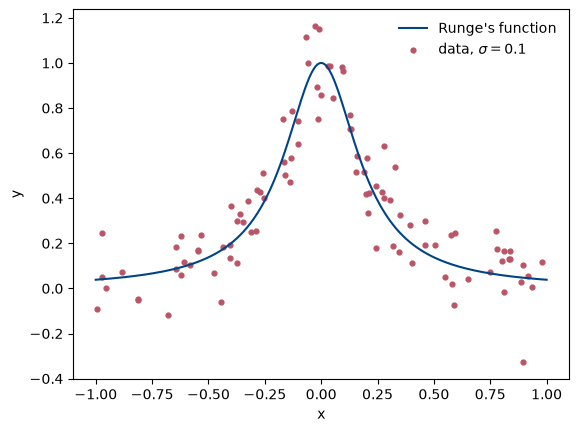

In [633]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

### Part a): Ordinary Least Squares (OLS) for the Runge function

We will generate our own data set for the above function $f(x)$ with
$x\in[-1,1]$, using either a uniform distribution or a fixed step size to set up
the array of $x$ values. You should also explore the addition of normally
distributed noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$ to the function; a
noise level of $\sigma\approx0.1$ is a good starting point, but study how your
conclusions depend on it.

**Write your own code** (using for example the pseudoinverse function `pinv`
from `numpy`, or the SVD directly) and perform a standard **ordinary least
squares regression** analysis using polynomials in $x$ up to order 15 or higher.
Explore the dependence on the number of data points and the polynomial degree.

Evaluate the mean squared error (MSE)

$$
\mathrm{MSE}(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2,
$$

and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
$i$-th sample and $y_i$ is the corresponding true value, then the score $R^2$ is
defined as

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
\qquad
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1}y_i .
$$

Plot the resulting scores (MSE and $R^2$) as functions of the polynomial degree
(here up to polynomial degree 15). Plot also the parameters $\boldsymbol{\theta}$
as you increase the order of the polynomial. Comment your results.

Your code has to include a scaling/centering of the data (for example by
subtracting the mean value), and a split of the data in training and test data.
For the splitting you can either write your own code or use for example the
function `train_test_split` provided by **Scikit-Learn** (make sure you have
installed it). **You should present a critical discussion of why and how you
have scaled/ or not scaled the data** (see Section 3.13 of the lecture notes,
the Tuesday session of week 35 and the pertinent notebook for week 35).

It is normal in essentially all Machine Learning studies to split the data in a
training set and a test set (eventually also an additional validation set).
There is no explicit recipe for how much data should be included as training
data and say test data. An accepted rule of thumb is to use approximately $2/3$
to $4/5$ of the data as training data.

You can easily reuse the solutions to your exercises from week 35 (the
analytical derivatives of the cost function, your own OLS code, and the
train/test analysis). See also the lecture slides from weeks 34 and 35 and
Chapter 3 of the lecture notes. On scaling, we recommend reading the following
section from the Scikit-Learn documentation:
<https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html>.
See also Section 3.13 of the lecture notes.

## Part a): OLS for Runge's function — code

**Sources for this part (course material, cited in the bibliography):**

| Piece | Course source | Status |
|---|---|---|
| `runge(x)`, data set-up | `Project1.ipynb`, starter cell | `runge` copied; data cell adapted into `make_data` |
| `MSE`, `R2` | `week35tuesday.ipynb`, setup cell | copied |
| `np.vander(x, d+1, increasing=True)` design matrix | `week35tuesday.ipynb` (exercise-3 figure, Case 4); week 35 Monday slides | adapted (column of ones removed) |
| standardise on training data, centre $y$, intercept $=\bar y$ | `week35tuesday.ipynb` Case 1 (`fit_scaled_unpenalised_intercept`) and Case 4; week 35 Monday slides, Eq. (3.90) | adapted into `scale_train_test` |
| SVD solver | `week35tuesday.ipynb` Case 2 (`ridge_svd`) | adapted to $\lambda=0$ with a pseudoinverse cutoff (`ols_svd`) |
| loop over degrees with one train/test split | `week35tuesday.ipynb` exercise-3 figure and Case 4, step 1 | adapted (`ols_degree_scan`) |
| MSE-vs-degree figure with noise floor | `week35tuesday.ipynb` exercise-3 figure | adapted |
| expected training MSE $\sigma^2(n-p)/n$ | week 36 Monday slides ($n-p$ in the residual variance) | new code |
| scaling checks (equivariance, condition number) | `week35tuesday.ipynb` Case 1 and Case 2; week 35 Monday slide "Why OLS is equivariant" | new code |

> **LLM note:** All code cells of part a) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course notebooks listed above as the base. Every cell below says what was taken
> from the course and what was changed. We asked for an explanation of each line and checked
> the results against `np.linalg.pinv`, `np.linalg.lstsq` and Scikit-Learn.

#### a.1 Imports and global settings
> **LLM note:** Written with Claude (Level 4). Standard imports only.

In [634]:
# Your code for part a) here
from sklearn.model_selection import train_test_split   # random train/test split, as in week35tuesday.ipynb
from sklearn.linear_model import LinearRegression      # used ONLY as an independent check of our own OLS code

SEED = 2026        # seed used in the course notebooks; fixes both the data and the split -> reproducible results
TEST_SIZE = 0.2    # 80 % training / 20 % test data, inside the 2/3-4/5 rule of thumb of the project text
MAX_DEGREE = 15    # highest polynomial degree asked for in part a)

#### a.2 Runge's function and the error metrics
**Source:** `runge` is copied from the starter cell of `Project1.ipynb`. `MSE` and `R2` are copied
from the setup cell of `week35tuesday.ipynb`. **Modifications:** none (comments added).
> **LLM note:** Comments written with Claude; the functions themselves are course code.

In [635]:
def runge(x):
    # Runge's function f(x) = 1 / (1 + 25 x^2); works element-wise on a whole NumPy array
    return 1.0 / (1.0 + 25.0 * x**2)


def MSE(y_data, y_model):
    # residuals y_i - y~_i, squared one by one, then averaged over the n points
    return np.mean((y_data - y_model) ** 2)


def R2(y_data, y_model):
    # numerator:   residual sum of squares, sum_i (y_i - y~_i)^2  -> what the model misses
    # denominator: total sum of squares,    sum_i (y_i - ybar)^2  -> spread of the data around its mean
    # R2 = 1 is a perfect fit, R2 = 0 is no better than always predicting the mean.
    # The ORDER of the arguments matters: the denominator must be built from the TRUE data y_data.
    return 1.0 - np.sum((y_data - y_model) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)

#### a.3 The data set
**Source:** adapted from the data cell of the `Project1.ipynb` starter ($x$ uniform on $[-1,1]$,
sorted, plus Gaussian noise). **Modification:** wrapped in a function `make_data(n, sigma, seed)`
so that the same code produces every data set of the $n$- and $\sigma$-studies below.
Because the noise is drawn as `sigma * standard_normal`, the same seed gives the same $x$ values
and the same noise *pattern* for every $\sigma$; only its size changes. Comparisons between noise
levels therefore isolate the effect of $\sigma$.
> **LLM note:** Written with Claude (Level 4), based on the starter cell of `Project1.ipynb`.

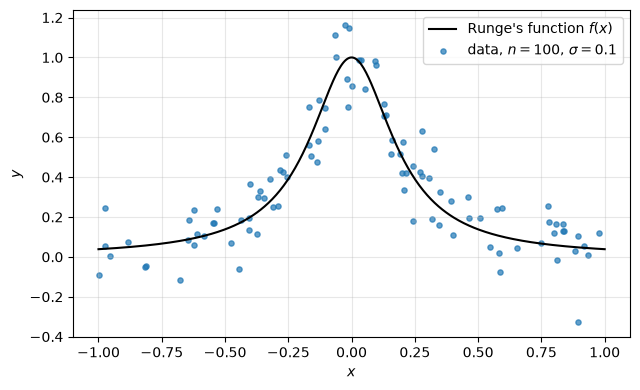

In [636]:
def make_data(n, sigma, seed=SEED):
    """
    n points with x ~ Uniform[-1, 1] and y = f(x) + sigma * eps, eps ~ N(0, 1).

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Turned the data cell of the Project1.ipynb starter into a function of (n, sigma, seed).
    Verification: plotted against the noise-free function below.
    """
    rng = np.random.default_rng(seed)        # new random generator with a fixed seed -> same numbers on every call
    x = np.sort(rng.uniform(-1.0, 1.0, n))   # n uniform inputs on [-1, 1]; sorted only so that line plots look clean
    eps = rng.standard_normal(n)             # n draws from N(0, 1)
    y = runge(x) + sigma * eps               # scaling by sigma gives noise with variance sigma^2
    return x, y


# Base case of part a): n = 100 points and noise level sigma = 0.1
x, y = make_data(n=100, sigma=0.1)

x_fine = np.linspace(-1, 1, 400)                          # dense grid, only used to draw f(x) as a smooth curve
fig, ax = plt.subplots(figsize=(6.5, 4))                  # one figure with one set of axes
ax.plot(x_fine, runge(x_fine), "k-", label=r"Runge's function $f(x)$")   # true function
ax.scatter(x, y, s=14, alpha=0.7, label=r"data, $n=100$, $\sigma=0.1$")   # noisy data points
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### a.4 Design matrix and scaling
**Source:** `np.vander(x, d + 1, increasing=True)` is the design matrix of the exercise-3 figure and
Case 4 in `week35tuesday.ipynb`. The scaling follows Case 1 of `week35tuesday.ipynb`
(`fit_scaled_unpenalised_intercept`: standardise the slope columns, centre $y$, recover the
intercept) and Case 4 ("standardise (fit on training data only!), centre y").

**Modifications:**
1. The column of ones is removed from the design matrix. With centred columns, Eq. (3.90) of the
   week 35 Monday slides, $\hat\theta_0 = \bar y - \sum_j \bar x_j \hat\theta_j$, reduces to
   $\hat\theta_0 = \bar y_{\rm train}$, so the intercept is simply the training mean of $y$.
2. The scaling is a separate function that returns the **test** matrix transformed with the
   **training** statistics, so it can be called inside every loop (here, and later in the
   bootstrap and cross-validation).
> **LLM note:** Written with Claude (Level 4), based on `week35tuesday.ipynb` Cases 1 and 4.

In [637]:
def polynomial_features(x, degree):
    """
    Design matrix with the columns x, x^2, ..., x^degree (no column of ones).

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted np.vander from week35tuesday.ipynb; removed the column of ones.
    """
    # np.vander(..., increasing=True) returns the columns x^0, x^1, ..., x^degree.
    # [:, 1:] drops the first column (x^0 = 1): the intercept is handled by centring instead.
    return np.vander(x, N=degree + 1, increasing=True)[:, 1:]


def scale_train_test(X_train, X_test, y_train):
    """
    Standardise the columns of X and centre y, with TRAINING statistics only.

    Returns X_train_s, X_test_s, y_train_c, y_mean. The model prediction is
    X_s @ theta + y_mean, so y_mean plays the role of the intercept.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Rewrote the scaling of week35tuesday.ipynb (Cases 1 and 4) as a function
          that also transforms the test matrix.
    Verification: predictions identical to OLS with an explicit intercept column
                  and to Scikit-Learn (cell a.11).
    """
    X_mean = X_train.mean(axis=0)   # mean of every column, computed from the training rows only
    X_std = X_train.std(axis=0)     # standard deviation of every column (ddof=0, as StandardScaler), training rows only
    y_mean = y_train.mean()         # mean of the training targets -> this becomes the intercept

    X_train_s = (X_train - X_mean) / X_std   # training columns now have mean 0 and standard deviation 1
    X_test_s = (X_test - X_mean) / X_std     # test columns shifted and divided by the SAME training numbers:
                                             # the test set must stay unseen, exactly like new data would be
    y_train_c = y_train - y_mean             # centred training targets (mean 0)
    return X_train_s, X_test_s, y_train_c, y_mean

#### a.5 Our own OLS solver (SVD / pseudoinverse)
**Source:** `ridge_svd` in `week35tuesday.ipynb`, Case 2:
$\hat{\boldsymbol\theta} = \boldsymbol V\,\mathrm{diag}\!\left(\frac{s_i}{s_i^2+\lambda}\right)\boldsymbol U^T\boldsymbol y$.
At $\lambda = 0$ this is the OLS (pseudoinverse) solution $\boldsymbol V\,\mathrm{diag}(1/s_i)\,\boldsymbol U^T\boldsymbol y$.

**Modification needed:** at $\lambda=0$, a singular value that is zero up to rounding would be
divided by and would blow the solution up. We therefore drop singular values below a relative
cutoff. We use the same cutoff as `np.linalg.lstsq(rcond=None)` (the solver used in
`week35tuesday.ipynb`): machine precision $\times \max(n,p) \times s_{\max}$. Dropping those
directions is exactly what a pseudoinverse does. The test at the end compares our solver with
`np.linalg.pinv` (suggested in the project text) and `np.linalg.lstsq`.
> **LLM note:** Written with Claude (Level 4), based on `ridge_svd` of `week35tuesday.ipynb`.

In [638]:
def ols_svd(X, y):
    """
    OLS parameters theta = X^+ y through the thin SVD X = U diag(s) V^T.

    Working with X itself (not X^T X) avoids squaring the condition number.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted ridge_svd (week35tuesday.ipynb, Case 2) to lambda = 0 and added
          the pseudoinverse cutoff of np.linalg.lstsq.
    Verification: agrees with np.linalg.pinv and np.linalg.lstsq (test below).
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=False)    # thin SVD: U is n x p, s holds p singular values
                                                        # (largest first), Vt is p x p
    cutoff = np.finfo(float).eps * max(X.shape) * s[0] # machine epsilon x largest dimension x largest singular value
    keep = s > cutoff                                   # True for directions that carry information,
                                                        # False for directions that are pure rounding noise
    coeffs = (U[:, keep].T @ y) / s[keep]               # components of y along the kept u_i, divided by s_i
    return Vt[keep].T @ coeffs                          # map back to parameter space: theta = sum_i coeff_i * v_i


# --- Test: our solver against two library routines (degree 15, all 100 points, scaled) ---
X15 = polynomial_features(x, 15)                          # raw degree-15 design matrix
X15_s = (X15 - X15.mean(axis=0)) / X15.std(axis=0)        # standardised columns
y_c = y - y.mean()                                        # centred targets

theta_own = ols_svd(X15_s, y_c)                           # our code
theta_pinv = np.linalg.pinv(X15_s) @ y_c                  # NumPy pseudoinverse (suggested in the project text)
theta_lstsq = np.linalg.lstsq(X15_s, y_c, rcond=None)[0]  # the SVD-based solver of week35tuesday.ipynb

print("max |own - pinv|  =", np.max(np.abs(theta_own - theta_pinv)))
print("max |own - lstsq| =", np.max(np.abs(theta_own - theta_lstsq)))
print("max |theta_j|     =", np.max(np.abs(theta_own)), "(for scale: differences are relative to this)")

max |own - pinv|  = 4.547473508864641e-13
max |own - lstsq| = 3.410605131648481e-13
max |theta_j|     = 595.7694205300749 (for scale: differences are relative to this)


#### a.6 Scan over the polynomial degree
**Source:** the loop in the exercise-3 figure and in Case 4 (step 1) of `week35tuesday.ipynb`:
split **once** with `train_test_split`, then for each degree build the design matrices, fit, and
store the training and test MSE.

**Modifications:**
1. Runge data and `test_size` 0.3 → 0.2 (project set-up).
2. Design matrix without the column of ones, and scaling with training statistics inside the loop.
3. `np.linalg.lstsq` replaced by our own `ols_svd` (the project asks for own code).
4. Predictions add back `y_mean`, the intercept.
5. $R^2$ and the parameter vector $\boldsymbol\theta$ are stored for every degree.
> **LLM note:** Written with Claude (Level 4), based on `week35tuesday.ipynb` (exercise-3 figure, Case 4).

In [639]:
def ols_degree_scan(x, y, max_degree=MAX_DEGREE, test_size=TEST_SIZE, seed=SEED):
    """
    OLS fits of degree 1..max_degree on ONE fixed train/test split.

    Returns a dictionary with arrays 'mse_train', 'mse_test', 'r2_train', 'r2_test'
    (one entry per degree) and a list 'theta' (theta for each degree).

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted the degree loop of week35tuesday.ipynb (exercise-3 figure, Case 4)
          to our own solver, scaling and intercept handling.
    Verification: training MSE decreases monotonically with the degree (nested models).
    """
    # One split for ALL degrees, so every degree is judged on exactly the same test points.
    # train_test_split shuffles before splitting, so the sorted x values are not a problem.
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=seed)

    res = {"mse_train": [], "mse_test": [], "r2_train": [], "r2_test": [], "theta": []}

    for degree in range(1, max_degree + 1):
        X_train = polynomial_features(x_train, degree)   # columns x, ..., x^degree for the training points
        X_test = polynomial_features(x_test, degree)     # the same columns for the test points

        # standardise with training statistics, centre y_train, keep y_mean as the intercept
        X_train_s, X_test_s, y_train_c, y_mean = scale_train_test(X_train, X_test, y_train)

        theta = ols_svd(X_train_s, y_train_c)            # fit on the scaled training data only

        y_fit_train = X_train_s @ theta + y_mean         # model on the training points (add the intercept back)
        y_fit_test = X_test_s @ theta + y_mean           # model on the unseen test points

        res["mse_train"].append(MSE(y_train, y_fit_train))
        res["mse_test"].append(MSE(y_test, y_fit_test))
        res["r2_train"].append(R2(y_train, y_fit_train))
        res["r2_test"].append(R2(y_test, y_fit_test))
        res["theta"].append(theta)                       # theta has 'degree' entries (no intercept)

    for key in ["mse_train", "mse_test", "r2_train", "r2_test"]:
        res[key] = np.array(res[key])                    # lists -> arrays, easier to plot and compare
    return res

#### a.7 Base case: MSE and $R^2$ against the degree ($n=100$, $\sigma=0.1$)
**Source:** figure layout from the exercise-3 figure of `week35tuesday.ipynb` (training and test
MSE on a log scale, noise floor $\sigma^2$ as a dashed line).

**Modifications:** an $R^2$ panel, and a reference curve for the expected training MSE of a model
with **no bias**, $\mathbb E[\mathrm{MSE}_{\rm train}] = \sigma^2 (n_{\rm train}-p)/n_{\rm train}$,
with $p = \text{degree} + 1$ parameters (slopes + intercept). This is the $n-p$ of the residual
variance discussed in the week 36 Monday slides: the fit spends $p$ degrees of freedom on the noise.
Since $f$ is known, the same curve is also drawn with the noise variance actually realised in the
training points, which differs from $\sigma^2$ for a finite sample.
> **LLM note:** Written with Claude (Level 4), based on the exercise-3 figure of `week35tuesday.ipynb`.

Realised noise variance in the training set: 0.0150 (sigma^2 = 0.0100)
Lowest test MSE at degree 8: MSE = 0.0187, R2 = 0.849

degree   MSE_train   MSE_test   R2_train   R2_test
     1     0.09367    0.14061    0.0019   -0.1353
     2     0.04819    0.06994    0.4865    0.4354
     3     0.04794    0.06903    0.4891    0.4427
     4     0.02983    0.03542    0.6822    0.7141
     5     0.02951    0.03663    0.6856    0.7043
     6     0.02256    0.02105    0.7596    0.8301
     7     0.02238    0.02260    0.7615    0.8175
     8     0.01726    0.01871    0.8161    0.8489
     9     0.01639    0.02489    0.8253    0.7990
    10     0.01554    0.01887    0.8344    0.8477
    11     0.01475    0.02257    0.8428    0.8178
    12     0.01320    0.03021    0.8593    0.7561
    13     0.01274    0.04392    0.8642    0.6454
    14     0.01245    0.03178    0.8673    0.7434
    15     0.01245    0.03394    0.8674    0.7259


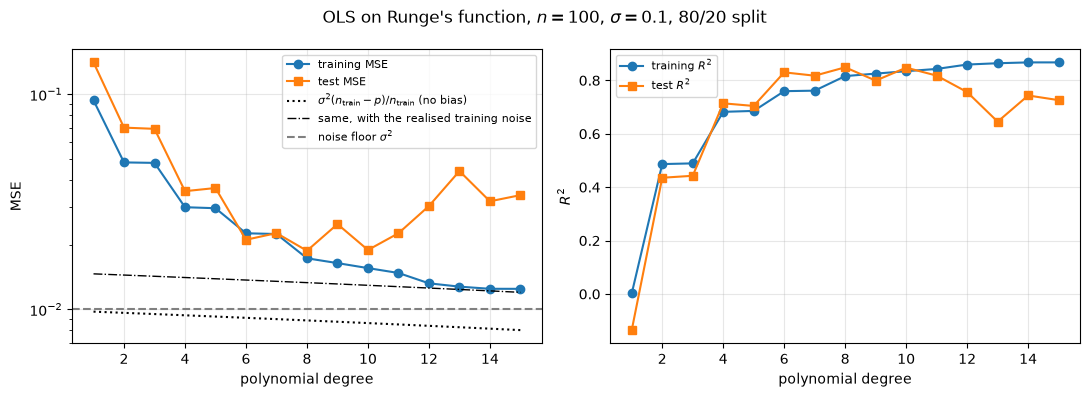

In [640]:
degrees = np.arange(1, MAX_DEGREE + 1)       # 1, 2, ..., 15
sigma = 0.1                                  # noise level of the base case
res = ols_degree_scan(x, y)                  # fit every degree on the base data set

n_test = int(np.ceil(TEST_SIZE * len(x)))    # train_test_split rounds the test size UP -> 20 points
n_train = len(x) - n_test                    # -> 80 training points
p = degrees + 1                              # number of fitted parameters: 'degree' slopes + 1 intercept
expected_train_mse = sigma**2 * (n_train - p) / n_train   # training MSE of an unbiased model

# The noise actually drawn in THIS training set is not exactly sigma^2. Since f is known here,
# we can measure it: same split as inside ols_degree_scan (same seed), then average (y - f)^2.
x_tr, _, y_tr, _ = train_test_split(x, y, test_size=TEST_SIZE, random_state=SEED)
noise_train = MSE(y_tr, runge(x_tr))                       # realised noise variance of the training points
expected_train_mse_real = noise_train * (n_train - p) / n_train
print(f"Realised noise variance in the training set: {noise_train:.4f} (sigma^2 = {sigma**2:.4f})")

best = np.argmin(res["mse_test"])            # index of the degree with the lowest test MSE
print(f"Lowest test MSE at degree {degrees[best]}: MSE = {res['mse_test'][best]:.4f}, "
      f"R2 = {res['r2_test'][best]:.3f}")
print("\ndegree   MSE_train   MSE_test   R2_train   R2_test")
for d in degrees:                            # one line per degree, as a table
    i = d - 1
    print(f"{d:6d}   {res['mse_train'][i]:9.5f}  {res['mse_test'][i]:9.5f}  "
          f"{res['r2_train'][i]:8.4f}  {res['r2_test'][i]:8.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))    # two panels side by side

ax1.plot(degrees, res["mse_train"], "o-", label="training MSE")
ax1.plot(degrees, res["mse_test"], "s-", label="test MSE")
ax1.plot(degrees, expected_train_mse, "k:", label=r"$\sigma^2(n_{\rm train}-p)/n_{\rm train}$ (no bias)")
ax1.plot(degrees, expected_train_mse_real, "k-.", lw=1,
         label=r"same, with the realised training noise")
ax1.axhline(sigma**2, color="gray", ls="--", label=r"noise floor $\sigma^2$")
ax1.set_yscale("log")                        # errors span orders of magnitude -> log scale
ax1.set_xlabel("polynomial degree")
ax1.set_ylabel("MSE")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(degrees, res["r2_train"], "o-", label=r"training $R^2$")
ax2.plot(degrees, res["r2_test"], "s-", label=r"test $R^2$")
ax2.set_xlabel("polynomial degree")
ax2.set_ylabel(r"$R^2$")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle(r"OLS on Runge's function, $n=100$, $\sigma=0.1$, 80/20 split")
plt.tight_layout()
plt.show()

#### a.8 The parameters $\boldsymbol\theta$ as the degree increases
**Source:** no course code; the plot is asked for in the project text.
Because the columns are standardised, all $\theta_j$ are in the same units (change of $y$ per
standard deviation of $x^j$), so their sizes can be compared directly.
Runge's function is **even**, so the true function has no odd-power content; the right panel
separates the size of the even-power and odd-power coefficients.
> **LLM note:** Written with Claude (Level 4). New code.

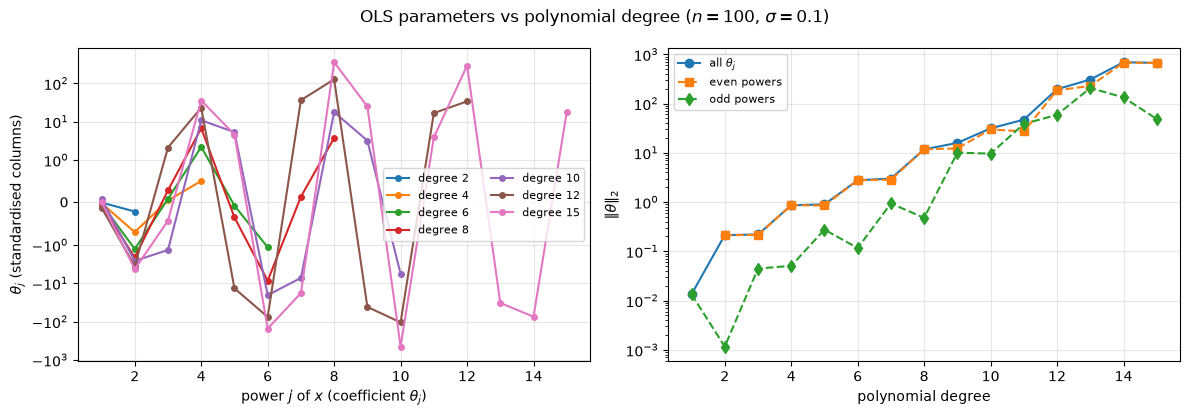

degree  4: ||theta||_2 =      0.86   even part =      0.86   odd part =      0.05
degree  8: ||theta||_2 =     11.75   even part =     11.74   odd part =      0.48
degree 12: ||theta||_2 =    195.41   even part =    186.23   odd part =     59.17
degree 15: ||theta||_2 =    669.12   even part =    667.35   odd part =     48.57


In [641]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: the individual coefficients theta_j for a selection of degrees
for d in [2, 4, 6, 8, 10, 12, 15]:
    theta = res["theta"][d - 1]                           # theta of the degree-d model (d entries)
    ax1.plot(np.arange(1, d + 1), theta, "o-", ms=4, label=f"degree {d}")
ax1.set_yscale("symlog", linthresh=1)    # linear between -1 and 1, logarithmic outside: shows small and huge values
ax1.set_xlabel(r"power $j$ of $x$ (coefficient $\theta_j$)")
ax1.set_ylabel(r"$\theta_j$ (standardised columns)")
ax1.legend(fontsize=8, ncol=2)
ax1.grid(alpha=0.3)

# Right: size of the coefficient vector, split into even and odd powers
norm_all, norm_even, norm_odd = [], [], []
for d in degrees:
    theta = res["theta"][d - 1]
    powers = np.arange(1, d + 1)                          # power j belonging to each theta_j
    norm_all.append(np.linalg.norm(theta))                # ||theta||_2, all coefficients
    even = theta[powers % 2 == 0]                         # only x^2, x^4, ... (empty for degree 1)
    norm_even.append(np.linalg.norm(even) if even.size else np.nan)   # NaN = "no even power yet", not drawn
    norm_odd.append(np.linalg.norm(theta[powers % 2 == 1]))    # only x, x^3, ...
ax2.plot(degrees, norm_all, "o-", label=r"all $\theta_j$")
ax2.plot(degrees, norm_even, "s--", label="even powers")
ax2.plot(degrees, norm_odd, "d--", label="odd powers")
ax2.set_yscale("log")
ax2.set_xlabel("polynomial degree")
ax2.set_ylabel(r"$\|\theta\|_2$")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle(r"OLS parameters vs polynomial degree ($n=100$, $\sigma=0.1$)")
plt.tight_layout()
plt.show()

for d in [4, 8, 12, 15]:
    print(f"degree {d:2d}: ||theta||_2 = {norm_all[d-1]:9.2f}   "
          f"even part = {norm_even[d-1]:9.2f}   odd part = {norm_odd[d-1]:9.2f}")

#### a.9 The fitted polynomials compared with $f(x)$
**Source:** no course code. The fits are drawn on a fine grid **inside** the range of the training
points (no extrapolation), and the error $|\tilde y(x) - f(x)|$ is split into the region near the
ends of the interval ($|x|>0.85$) and the inside.
> **LLM note:** Written with Claude (Level 4). New code.

degree  4: mean (fit - f)^2 = 0.01796   max error near the ends = 0.245   inside = 0.315
degree  8: mean (fit - f)^2 = 0.00572   max error near the ends = 0.145   inside = 0.158
degree 15: mean (fit - f)^2 = 0.00940   max error near the ends = 0.384   inside = 0.230


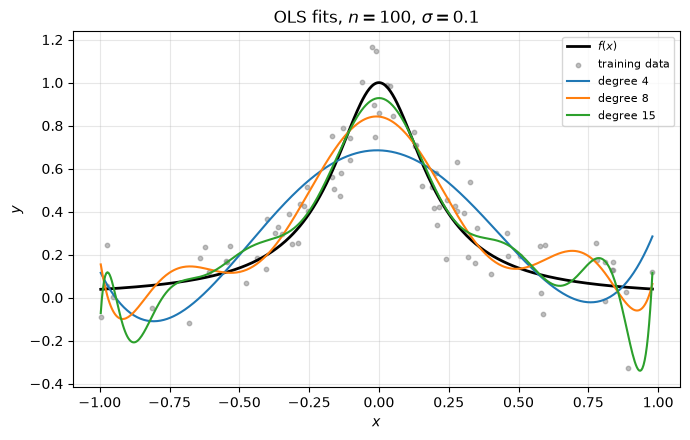

In [642]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=SEED)  # same split as a.6
x_grid = np.linspace(x_train.min(), x_train.max(), 500)   # fine grid, only between the outermost training points
near_edge = np.abs(x_grid) > 0.85                         # True for grid points close to the ends of [-1, 1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_grid, runge(x_grid), "k-", lw=2, label=r"$f(x)$")
ax.scatter(x_train, y_train, s=10, color="gray", alpha=0.5, label="training data")

for d in [4, 8, 15]:
    # scale the grid with the TRAINING statistics, exactly like the test points
    X_tr_s, X_grid_s, y_tr_c, y_m = scale_train_test(polynomial_features(x_train, d),
                                                     polynomial_features(x_grid, d), y_train)
    fit = X_grid_s @ ols_svd(X_tr_s, y_tr_c) + y_m        # fitted polynomial evaluated on the grid
    err = np.abs(fit - runge(x_grid))                     # distance to the TRUE function (no noise)
    print(f"degree {d:2d}: mean (fit - f)^2 = {np.mean(err**2):.5f}   "
          f"max error near the ends = {err[near_edge].max():.3f}   inside = {err[~near_edge].max():.3f}")
    ax.plot(x_grid, fit, label=f"degree {d}")

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"OLS fits, $n=100$, $\sigma=0.1$")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### a.10 Dependence on the number of data points $n$ and on the noise level $\sigma$
**Source:** the idea comes from the "Your turn" of Case 4 in `week35tuesday.ipynb` (vary the noise
level and the number of points); the code is new and reuses `ols_degree_scan`.
Every curve uses a single data set and a single split, so individual bumps are noisy;
parts c) and d) use resampling to average this out.
> **LLM note:** Written with Claude (Level 4). New code.

n =   50: lowest test MSE at degree 11 (0.0135); training MSE at degree 15 = 0.0052
n =  100: lowest test MSE at degree  8 (0.0187); training MSE at degree 15 = 0.0124
n =  500: lowest test MSE at degree 14 (0.0144); training MSE at degree 15 = 0.0091
n = 2000: lowest test MSE at degree 14 (0.0119); training MSE at degree 15 = 0.0101
sigma = 0.00: lowest test MSE at degree 12 (0.00151); best test R2 = 0.981
sigma = 0.05: lowest test MSE at degree 10 (0.00550); best test R2 = 0.945
sigma = 0.10: lowest test MSE at degree  8 (0.01871); best test R2 = 0.849
sigma = 0.30: lowest test MSE at degree  8 (0.13305); best test R2 = 0.505


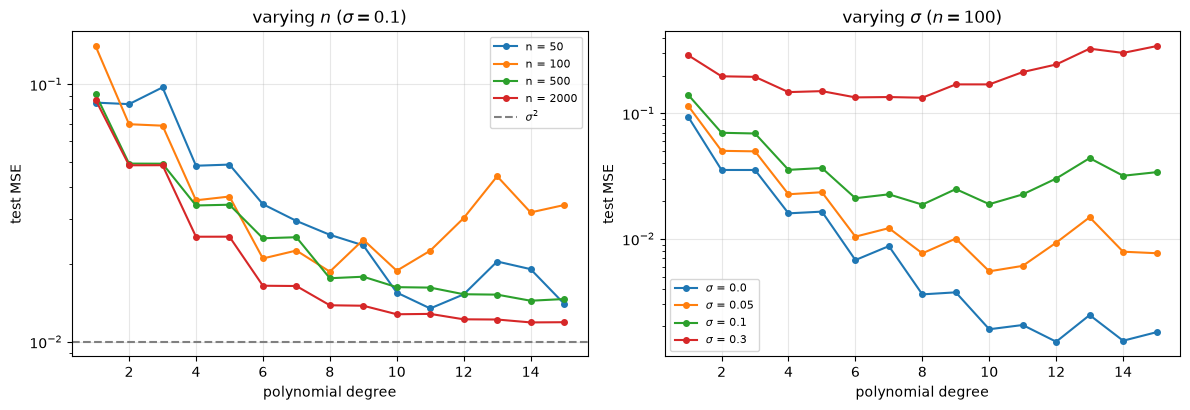

In [643]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: vary n at fixed sigma = 0.1
for n in [50, 100, 500, 2000]:
    x_n, y_n = make_data(n=n, sigma=0.1)          # new data set with n points
    res_n = ols_degree_scan(x_n, y_n)             # same 80/20 split rule and degrees 1..15
    axes[0].plot(degrees, res_n["mse_test"], "o-", ms=4, label=f"n = {n}")
    print(f"n = {n:4d}: lowest test MSE at degree {degrees[np.argmin(res_n['mse_test'])]:2d} "
          f"({res_n['mse_test'].min():.4f}); training MSE at degree 15 = {res_n['mse_train'][-1]:.4f}")
axes[0].axhline(0.1**2, color="gray", ls="--", label=r"$\sigma^2$")
axes[0].set_title(r"varying $n$ ($\sigma = 0.1$)")

# Right: vary sigma at fixed n = 100 (same x values and same noise pattern, only its size changes)
for s in [0.0, 0.05, 0.1, 0.3]:
    x_s, y_s = make_data(n=100, sigma=s)
    res_s = ols_degree_scan(x_s, y_s)
    axes[1].plot(degrees, res_s["mse_test"], "o-", ms=4, label=rf"$\sigma$ = {s}")
    print(f"sigma = {s:4.2f}: lowest test MSE at degree {degrees[np.argmin(res_s['mse_test'])]:2d} "
          f"({res_s['mse_test'].min():.5f}); best test R2 = {res_s['r2_test'].max():.3f}")
axes[1].set_title(r"varying $\sigma$ ($n = 100$)")

for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("polynomial degree")
    ax.set_ylabel("test MSE")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### a.11 Numerical checks for the scaling discussion
**Source:** the ideas come from `week35tuesday.ipynb` Case 1 (OLS with an intercept column and OLS on
centred data give identical predictions; a change of units rescales the coefficients but not the
predictions), the week 35 Monday slide "Why OLS is equivariant", and Case 2 of `week35tuesday.ipynb`
(`np.linalg.cond`). The code is new.

The cell checks four things for the degree-15 model:
1. our scaled fit gives the same predictions as an unscaled fit with a column of ones, and as Scikit-Learn;
2. the condition number of the design matrix, and what happens if $x$ is measured in other units
   ($x \to 10x$, $x \to 100x$): the raw matrix becomes numerically singular, the standardised one does not change at all;
3. what goes wrong without centring when there is no column of ones;
4. that computing the scaling statistics on all data instead of the training data changes nothing
   for OLS (but see the discussion: it matters for Ridge, Lasso and gradient descent).
> **LLM note:** Written with Claude (Level 4). New code, verified by the printed comparisons.

In [644]:
d = 15                                                     # the most complex model of part a)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=SEED)
X_train, X_test = polynomial_features(x_train, d), polynomial_features(x_test, d)

# (1) Same predictions three ways
X_train_s, X_test_s, y_train_c, y_mean = scale_train_test(X_train, X_test, y_train)
pred_scaled = X_test_s @ ols_svd(X_train_s, y_train_c) + y_mean          # our method

X_train_1 = np.column_stack([np.ones(len(x_train)), X_train])          # raw columns + column of ones
X_test_1 = np.column_stack([np.ones(len(x_test)), X_test])
pred_raw = X_test_1 @ ols_svd(X_train_1, y_train)                        # no scaling at all

pred_skl = LinearRegression().fit(X_train, y_train).predict(X_test)     # Scikit-Learn, fit_intercept=True

print("(1) max |scaled - raw with ones| =", np.max(np.abs(pred_scaled - pred_raw)))
print("    max |scaled - sklearn|       =", np.max(np.abs(pred_scaled - pred_skl)))

# (2) Condition numbers, and a change of units x -> c x
print("\n(2)  units    cond(raw, with ones)   directions kept   cond(standardised)   test MSE raw   test MSE std")
for c in [1, 10, 100]:
    Xr_tr = np.column_stack([np.ones(len(x_train)), polynomial_features(c * x_train, d)])
    Xr_te = np.column_stack([np.ones(len(x_test)), polynomial_features(c * x_test, d)])
    s_raw = np.linalg.svd(Xr_tr, compute_uv=False)                      # singular values only
    kept = np.sum(s_raw > np.finfo(float).eps * max(Xr_tr.shape) * s_raw[0])   # same cutoff as ols_svd
    mse_raw = MSE(y_test, Xr_te @ ols_svd(Xr_tr, y_train))

    Xs_tr, Xs_te, yc_tr, ym = scale_train_test(polynomial_features(c * x_train, d),
                                               polynomial_features(c * x_test, d), y_train)
    mse_std = MSE(y_test, Xs_te @ ols_svd(Xs_tr, yc_tr) + ym)
    print(f"     x*{c:<4d}  {np.linalg.cond(Xr_tr):18.2e}   {kept:8d} / {d + 1}   "
          f"{np.linalg.cond(Xs_tr):17.2e}   {mse_raw:12.4f}   {mse_std:11.4f}")

# (3) No column of ones AND no centring: the model is forced through y = 0 at x = 0
theta_nc = ols_svd(X_train, y_train)                     # raw columns x..x^15, raw y, no intercept anywhere
print("\n(3) test MSE without intercept and without centring:", MSE(y_test, X_test @ theta_nc),
      " vs with centring:", MSE(y_test, pred_scaled))

# (4) Scaling statistics from ALL points instead of the training points only
X_all = polynomial_features(x, d)
mu_all, sd_all = X_all.mean(axis=0), X_all.std(axis=0)          # statistics that have "seen" the test points
Xa_tr, Xa_te = (X_train - mu_all) / sd_all, (X_test - mu_all) / sd_all
Xa_tr1 = np.column_stack([np.ones(len(x_train)), Xa_tr])        # keep a free intercept
Xa_te1 = np.column_stack([np.ones(len(x_test)), Xa_te])
pred_leaky = Xa_te1 @ ols_svd(Xa_tr1, y_train)
print("(4) max |train-only statistics - all-data statistics| (OLS) =", np.max(np.abs(pred_scaled - pred_leaky)))

(1) max |scaled - raw with ones| = 3.298417095010109e-12
    max |scaled - sklearn|       = 2.0261015087896794e-12

(2)  units    cond(raw, with ones)   directions kept   cond(standardised)   test MSE raw   test MSE std
     x*1               3.52e+05         16 / 16            2.04e+05         0.0339        0.0339
     x*10              5.88e+14         12 / 16            2.04e+05         0.2159        0.0339
     x*100             1.11e+32          6 / 16            2.04e+05         0.2016        0.0339

(3) test MSE without intercept and without centring: 0.2687198508850224  vs with centring: 0.03394357249714263
(4) max |train-only statistics - all-data statistics| (OLS) = 2.9271585155754565e-12


#### a.12 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions
> (text Level 3 if used as it is). Rewrite in your own words for the report, and check every
> number against your own run. **[own]** marks reasoning that is not taken from the course material.

1. **Solver check (a.5).** Our SVD-based OLS agrees with `np.linalg.pinv` and `np.linalg.lstsq`
   to $4.5\cdot10^{-13}$ and $3.4\cdot10^{-13}$, while the largest coefficient is about 596. The
   relative difference is about $10^{-15}$, i.e. a few times the machine precision
   ($2.2\cdot10^{-16}$): the three methods give the same $\boldsymbol\theta$ up to rounding.
   The small differences come from the different order of the floating-point operations
   [own, general numerical knowledge].

2. **Training vs test error (a.7).** The training MSE decreases with every degree, because adding a
   column can only lower the training error (lecture notes, Section 3.5). The test MSE is lowest at
   degree 8 (0.0187, $R^2 = 0.85$) and rises irregularly after that (0.044 at degree 13). At degree 1
   the test $R^2$ is negative ($-0.14$): a straight line predicts the test points worse than their
   own mean, which is possible off the training set (Section 3.5).

3. **The reference lines (a.7).** The noise floor $\sigma^2 = 0.01$ is the lowest expected test
   error any model can reach. The dotted line $\sigma^2(n_{\rm train}-p)/n_{\rm train}$ is the
   expected training MSE of a model without bias: a fit with $p$ parameters "consumes" $p$ degrees
   of freedom of the noise (Proposition 3.2, Section 3.7; week 36 Monday slides). The noise actually
   realised in these 80 training points is 0.015 rather than 0.01, so we also draw the same curve
   with 0.015 [own addition, an approximation since Proposition 3.2 is a statement about the
   expectation]. The gap between the training MSE and this curve is approximately the part of $f$
   the polynomial cannot represent [own interpretation]. At degree 14–15 the gap has closed
   (0.0124 against 0.012): extra parameters can then only fit noise, and the test error confirms it.

4. **Size of the parameters (a.8).** $\|\boldsymbol\theta\|_2$ grows from 0.86 at degree 4 to 669
   at degree 15, while the test error gets worse after degree 8. At high degree the coefficients take
   large values of alternating sign that nearly cancel. The reason is that the high powers are almost
   identical on $[-1,1]$ (correlation 0.994 between $x^8$ and $x^{10}$, 0.996 between $x^{10}$ and
   $x^{12}$ [own check]): the data do not determine such combinations, which gives "an enormous
   positive coefficient on one feature cancelling an enormous negative one on another"
   (lecture notes, Section 3.7, around Eq. (3.42); see also Section 1.12 and Fig. 1.2 on the
   conditioning of polynomial design matrices).

5. **Even and odd powers (a.8) [own].** Runge's function is even, so a good fit needs only even
   powers. Up to degree 8 the odd coefficients are indeed negligible (norm 0.48 against 11.7), and
   adding an odd power barely changes the MSE (the steps at 2→3, 4→5, 6→7). The even part grows as a
   staircase: it jumps each time a new even power is added, since every new even power is nearly
   collinear with the previous one and needs a larger cancelling pair. The odd part zig-zags: it rises
   when an odd power is added and falls when the next even power arrives, because the training $x$
   values are not exactly symmetric around 0 (mean 0.029) and the odd powers partly stand in for a
   missing even power. Beyond degree 12 both parts move without a clear pattern. The odd part reaches
   178 at degree 15 even for noise-free data ($\sigma = 0$), so its growth is not caused by the noise
   but by coefficients that are no longer determined by the data (Section 3.7).

6. **The fitted curves (a.9).** Degree 4 is too stiff: it reaches only about 0.68 at the peak where
   $f(0) = 1$, bends upwards at the right edge, and has its largest error inside the interval (0.32):
   underfitting, large bias. Degree 8 is closest to $f$ (mean squared distance 0.0057, against 0.018
   for degree 4 and 0.0094 for degree 15). Degree 15 gets closest at the peak (about 0.93) but wiggles
   between the data points and swings strongly near the edges, down to $-0.34$ near $x \approx 0.93$,
   where it follows a single noisy training point at about $(0.9, -0.33)$: overfitting, large variance.
   Its largest errors are near the ends of the interval (0.38 for $|x| > 0.85$ against 0.23 inside).
   Two effects combine there [own]: high-degree polynomials oscillate near the end points, which is
   Runge's phenomenon (not covered in the lecture notes; see the reference in the project text), and a
   point at the edge has data on one side only, while the high powers are largest near $\pm 1$.
   This is the bias-variance tradeoff in one figure (lecture notes, Sections 2.9–2.10;
   Hastie et al., Fig. 2.11), studied properly in part c).

7. **Number of points (a.10) [own].** With more data the best degree moves up (8 at $n = 100$, 14 at
   $n = 500$ and $n = 2000$) and the degree-15 training MSE approaches $\sigma^2$ (0.0052 at $n = 50$,
   0.0101 at $n = 2000$): with more points, a flexible model spends its parameters on the function
   instead of the noise. The $n = 50$ result (degree 11) rests on only 10 test points and is not reliable.

8. **Noise level (a.10) [own].** More noise moves the best degree down (12 at $\sigma = 0$, 10 at 0.05,
   8 at 0.1 and 0.3) and lowers the best test $R^2$ (0.98 → 0.51). At $\sigma = 0$ the remaining test
   MSE (0.0015) is pure approximation error: no polynomial of degree ≤ 15 follows the sharp peak exactly.

9. **Why and how we scaled (a.11).** We standardise the columns and centre $y$, with the training
   statistics only, and add $\bar y_{\rm train}$ back as the intercept (Eq. (3.90), Section 3.13;
   `week35tuesday` Cases 1 and 4). The checks show:
   - *For OLS, scaling does not change the predictions.* Our fit agrees with an unscaled fit with a
     column of ones ($2\cdot10^{-12}$) and with Scikit-Learn ($1\cdot10^{-12}$): OLS is equivariant
     under rescaling of the columns (Section 3.13; week 35 Monday slides).
   - *Numerical safety.* On $[-1,1]$ standardising only improves the condition number a little
     ($3.5\cdot10^5 \to 2.0\cdot10^5$), because all powers are already at most 1. If $x$ were measured
     in units ten times smaller ($x \to 10x$) [own test, inspired by the millimetre example of Section
     3.13], the raw matrix has condition number $5.9\cdot10^{14}$, the SVD has to drop 4 of 16
     directions (threshold of Section 1.19), and the test MSE becomes 0.216 instead of 0.034. The
     standardised matrix is identical in any units, since the factor $c^k$ divides out.
   - *The intercept.* Without a column of ones and without centring, every power of $x$ is zero at
     $x = 0$, so the fit is forced through $y = 0$ there, while $f(0) = 1$: test MSE 0.269 against
     0.034. Centring replaces the column of ones, and in parts b) and g) it keeps the intercept out of
     the penalty (Section 3.13).
   - *Training statistics only.* Computing the means and standard deviations on all 100 points changes
     nothing for OLS ($3\cdot10^{-12}$), but we keep them from the training data because the test set
     must stay unseen, and because Ridge, Lasso and gradient descent are not scale-invariant, so there
     leaked statistics would change the model (Section 3.13; `week36tuesday` Case 2).

10. **Caveat.** All numbers come from one data set and one 80/20 split with 20 test points, so single
    bumps in the test curves (for example at degree 13) should not be over-interpreted. Parts c) and d)
    average over resamples.

### Part b): Adding Ridge regression for the Runge function

Write your own code for the Ridge method, as done in the previous part. The
lecture notes from weeks 35 and 36 contain more information, as well as your
exercises from weeks 35 and 36. Feel free to reuse this material.

Perform the same analysis as you did in the previous part but now for different
values of the penalty parameter $\lambda$. Compare and analyze your results with
those obtained in part a) with the OLS method. Study the dependence on
$\lambda$, and connect what you see to the shrinkage of the singular-value modes
discussed in the lectures (Section 3.8 of the lecture notes).

## Part b): Ridge regression for Runge's function — code

**Sources for this part (course material, cited in the bibliography):**

| Piece | Course source | Status |
|---|---|---|
| `ridge_svd`, Ridge through the SVD | `week35tuesday.ipynb` Case 2; lecture notes Eq. (3.46); week 35 Monday slides ("Deriving Eq. (3.46)") | copied (comments added) |
| checks against the normal equations and `Ridge(alpha=lambda)` | `week35tuesday.ipynb` Case 2 | adapted |
| degree scan with a penalty | our `ols_degree_scan` (a.6), itself from `week35tuesday.ipynb` Case 4 | adapted |
| degree fixed at 15, $\lambda$ as the complexity dial, df($\lambda$) | `week35tuesday.ipynb` Case 4, step 2; lecture notes Section 3.8 | adapted |
| training MSE non-decreasing in $\lambda$ | lecture notes Eq. (3.91); week 35 exercise sheet, exercise 4 | check is new code |
| coefficient paths | `week35tuesday.ipynb` Case 3 | new code, same idea |
| $\|\hat\theta_{\rm Ridge}\|$ decreasing in $\lambda$ | lecture notes Proposition 3.5, Eq. (3.53) | check is new code |
| shrinkage factors $\sigma_i^2/(\sigma_i^2+\lambda)$, df($\lambda$) | lecture notes Eqs. (3.46)–(3.48), Fig. 3.1, Section 3.8; week 35 Monday slides 13–15 | new code |
| dependence on $n$ and $\sigma$ | `week35tuesday.ipynb` Case 4, "Your turn" | new code |

**Convention for $\lambda$ (important for part e).** We use Eq. (3.44) of the lecture notes,
$\hat{\boldsymbol\theta}_{\rm Ridge} = (\boldsymbol X^T\boldsymbol X + \lambda\boldsymbol I)^{-1}\boldsymbol X^T\boldsymbol y$,
i.e. the cost $\|\boldsymbol y-\boldsymbol X\boldsymbol\theta\|_2^2 + \lambda\|\boldsymbol\theta\|_2^2$ **without** the
factor $1/n$. This is the convention of Section 3.8, of `ridge_svd` in `week35tuesday.ipynb`, and of
Scikit-Learn's `Ridge(alpha=lambda)`. Part e) uses the cost $\frac1n\|\cdot\|_2^2 + \lambda\|\boldsymbol\theta\|_2^2$,
so a $\lambda$ from this part corresponds to $\lambda/n_{\rm train}$ there.

> **LLM note:** All code cells of part b) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course material listed above as the base. We asked for an explanation of each
> line and checked the results against the normal equations and Scikit-Learn.

## Part b): Ridge regression for Runge's function — code

**Sources for this part (course material, cited in the bibliography):**

| Piece | Course source | Status |
|---|---|---|
| `ridge_svd`, Ridge through the SVD | `week35tuesday.ipynb` Case 2; lecture notes Eq. (3.46); week 35 Monday slides ("Deriving Eq. (3.46)") | copied (comments added) |
| checks against the normal equations and `Ridge(alpha=lambda)` | `week35tuesday.ipynb` Case 2 | adapted |
| degree scan with a penalty | our `ols_degree_scan` (a.6), itself from `week35tuesday.ipynb` Case 4 | adapted |
| degree fixed at 15, $\lambda$ as the complexity dial, df($\lambda$) | `week35tuesday.ipynb` Case 4, step 2; lecture notes Section 3.8 | adapted |
| training MSE non-decreasing in $\lambda$ | lecture notes Eq. (3.91); week 35 exercise sheet, exercise 4 | check is new code |
| coefficient paths | `week35tuesday.ipynb` Case 3 | new code, same idea |
| $\|\hat\theta_{\rm Ridge}\|$ decreasing in $\lambda$ | lecture notes Proposition 3.5, Eq. (3.53) | check is new code |
| shrinkage factors $\sigma_i^2/(\sigma_i^2+\lambda)$, df($\lambda$) | lecture notes Eqs. (3.46)–(3.48), Fig. 3.1, Section 3.8; week 35 Monday slides 13–15 | new code |
| dependence on $n$ and $\sigma$ | `week35tuesday.ipynb` Case 4, "Your turn" | new code |

**Convention for $\lambda$ (important for part e).** We use Eq. (3.44) of the lecture notes,
$\hat{\boldsymbol\theta}_{\rm Ridge} = (\boldsymbol X^T\boldsymbol X + \lambda\boldsymbol I)^{-1}\boldsymbol X^T\boldsymbol y$,
i.e. the cost $\|\boldsymbol y-\boldsymbol X\boldsymbol\theta\|_2^2 + \lambda\|\boldsymbol\theta\|_2^2$ **without** the
factor $1/n$. This is the convention of Section 3.8, of `ridge_svd` in `week35tuesday.ipynb`, and of
Scikit-Learn's `Ridge(alpha=lambda)`. Part e) uses the cost $\frac1n\|\cdot\|_2^2 + \lambda\|\boldsymbol\theta\|_2^2$,
so a $\lambda$ from this part corresponds to $\lambda/n_{\rm train}$ there.

> **LLM note:** All code cells of part b) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course material listed above as the base. We asked for an explanation of each
> line and checked the results against the normal equations and Scikit-Learn.

In [645]:
from sklearn.linear_model import Ridge      # used ONLY as an independent check of our own Ridge code


def ridge_svd(X, y, lam):
    """
    Ridge parameters theta = (X^T X + lam I)^{-1} X^T y through the thin SVD, Eq. (3.46).
    Cost: ||y - X theta||^2 + lam ||theta||^2 (no 1/n), same as sklearn Ridge(alpha=lam).

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Comments only; the function is ridge_svd from week35tuesday.ipynb, Case 2.
    Verification: lam = 0 reproduces ols_svd; agrees with the normal equations and sklearn (below).
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=False)   # thin SVD X = U diag(s) V^T, as in ols_svd
    factor = s / (s**2 + lam)                           # Eq. (3.46): OLS has 1/s_i, Ridge has s_i/(s_i^2 + lam)
    return Vt.T @ (factor * (U.T @ y))                  # theta = sum_i factor_i * (u_i^T y) * v_i


# --- Checks on the degree-15 model, same split as in part a) ---
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=SEED)
X_train_s, X_test_s, y_train_c, y_mean = scale_train_test(
    polynomial_features(x_train, 15), polynomial_features(x_test, 15), y_train)
p15 = X_train_s.shape[1]                                # 15 columns (x, ..., x^15)

# (1) lambda = 0 must give back OLS
diff0 = np.max(np.abs(ridge_svd(X_train_s, y_train_c, 0.0) - ols_svd(X_train_s, y_train_c)))
print(f"lambda = 0 vs ols_svd: max difference {diff0:.1e}")

# (2) against the normal equations (3.44) and Scikit-Learn, relative to the size of theta
print("\n lambda     rel. diff. normal eq.   rel. diff. sklearn")
for lam in [1e-4, 1e-2, 1.0, 100.0]:
    th_svd = ridge_svd(X_train_s, y_train_c, lam)
    # Eq. (3.44) solved directly: (X^T X + lam I) theta = X^T y
    th_normal = np.linalg.solve(X_train_s.T @ X_train_s + lam * np.eye(p15), X_train_s.T @ y_train_c)
    # sklearn minimises ||y - X theta||^2 + alpha ||theta||^2; fit_intercept=False because y is centred
    th_skl = Ridge(alpha=lam, fit_intercept=False).fit(X_train_s, y_train_c).coef_
    scale = np.max(np.abs(th_svd))                      # size of the coefficients, to make the difference relative
    print(f"{lam:8.0e}   {np.max(np.abs(th_svd - th_normal)) / scale:18.1e}   "
          f"{np.max(np.abs(th_svd - th_skl)) / scale:18.1e}")

lambda = 0 vs ols_svd: max difference 1.1e-13

 lambda     rel. diff. normal eq.   rel. diff. sklearn
   1e-04              9.0e-11              1.2e-10
   1e-02              2.4e-12              2.8e-12
   1e+00              3.1e-14              2.3e-14
   1e+02              1.8e-15              1.8e-15


#### b.2 Scan over the polynomial degree at fixed $\lambda$
**Source:** identical in structure to `ols_degree_scan` (a.6, itself adapted from `week35tuesday.ipynb`,
Case 4). **Modification:** `ols_svd` is replaced by `ridge_svd` with a fixed penalty `lam`. The split and
the scaling are exactly those of part a), so OLS and Ridge are compared on the same points.
The intercept $\bar y_{\rm train}$ is added back after the fit and is therefore **not penalised**
(lecture notes Section 3.13; `week35tuesday.ipynb` Case 1).
> **LLM note:** Written with Claude (Level 4), adapted from our `ols_degree_scan`.

In [646]:
def ridge_degree_scan(x, y, lam, max_degree=MAX_DEGREE, test_size=TEST_SIZE, seed=SEED):
    """
    Ridge fits of degree 1..max_degree at a fixed penalty lam, on ONE fixed train/test split.
    Same output as ols_degree_scan; lam = 0 reproduces it.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Copy of ols_degree_scan (a.6) with ridge_svd instead of ols_svd.
    Verification: lam = 0 gives the OLS results of part a) (checked in b.3).
    """
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=seed)          # same split as part a)

    res = {"mse_train": [], "mse_test": [], "r2_train": [], "r2_test": [], "theta": []}
    for degree in range(1, max_degree + 1):
        X_train = polynomial_features(x_train, degree)         # columns x, ..., x^degree
        X_test = polynomial_features(x_test, degree)
        # standardise with training statistics; y_mean is the (unpenalised) intercept
        X_train_s, X_test_s, y_train_c, y_mean = scale_train_test(X_train, X_test, y_train)

        theta = ridge_svd(X_train_s, y_train_c, lam)           # penalised fit on the training data

        y_fit_train = X_train_s @ theta + y_mean               # add the intercept back
        y_fit_test = X_test_s @ theta + y_mean
        res["mse_train"].append(MSE(y_train, y_fit_train))
        res["mse_test"].append(MSE(y_test, y_fit_test))
        res["r2_train"].append(R2(y_train, y_fit_train))
        res["r2_test"].append(R2(y_test, y_fit_test))
        res["theta"].append(theta)

    for key in ["mse_train", "mse_test", "r2_train", "r2_test"]:
        res[key] = np.array(res[key])                          # lists -> arrays
    return res

#### b.3 The analysis of part a), now for several values of $\lambda$
**Source:** same figures as a.7 (layout from the exercise-3 figure of `week35tuesday.ipynb`).
**Modification:** one curve per $\lambda$; $\lambda = 0$ is OLS and must reproduce part a).
> **LLM note:** Written with Claude (Level 4). New code.

lambda = 0 vs part a): max |test MSE difference| = 2.1711799025325718e-14

 lambda    best degree   test MSE   test R2   training MSE at degree 15
   0e+00          8       0.0187     0.849       0.0124
   1e-06          8       0.0187     0.849       0.0129
   1e-04          8       0.0185     0.850       0.0149
   1e-02         10       0.0200     0.838       0.0181
   1e+00         15       0.0384     0.690       0.0307
   1e+02          5       0.0925     0.254       0.0614


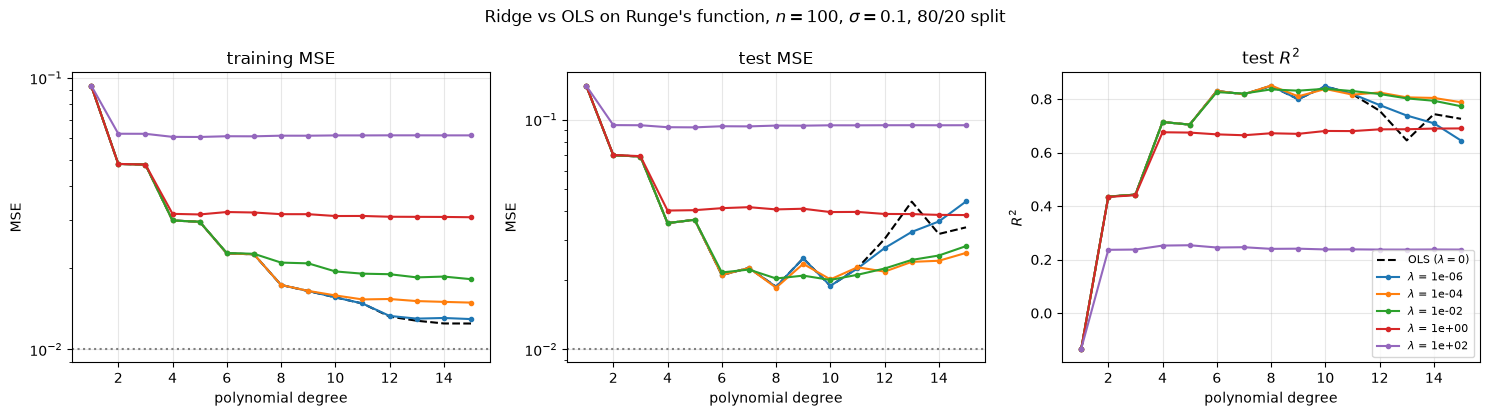

In [647]:
lambdas_show = [0.0, 1e-6, 1e-4, 1e-2, 1.0, 100.0]     # lambda = 0 is plain OLS
res_ridge = {lam: ridge_degree_scan(x, y, lam) for lam in lambdas_show}   # one degree scan per lambda

# check: lambda = 0 must reproduce the OLS results of part a) (variable res from a.7)
print("lambda = 0 vs part a): max |test MSE difference| =",
      np.max(np.abs(res_ridge[0.0]["mse_test"] - res["mse_test"])))

print("\n lambda    best degree   test MSE   test R2   training MSE at degree 15")
for lam in lambdas_show:
    r = res_ridge[lam]
    b = np.argmin(r["mse_test"])                           # best degree on the test set
    print(f"{lam:8.0e}   {degrees[b]:8d}     {r['mse_test'][b]:8.4f}   {r['r2_test'][b]:7.3f}"
          f"   {r['mse_train'][-1]:10.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for lam in lambdas_show:
    r = res_ridge[lam]
    label = r"OLS ($\lambda=0$)" if lam == 0 else rf"$\lambda$ = {lam:.0e}"
    style = "k--" if lam == 0 else "o-"                    # OLS as a dashed black reference line
    axes[0].plot(degrees, r["mse_train"], style, ms=3, label=label)
    axes[1].plot(degrees, r["mse_test"], style, ms=3, label=label)
    axes[2].plot(degrees, r["r2_test"], style, ms=3, label=label)

axes[0].set_title("training MSE")
axes[1].set_title("test MSE")
axes[2].set_title(r"test $R^2$")
for ax in axes[:2]:
    ax.axhline(0.1**2, color="gray", ls=":", label=r"$\sigma^2$")
    ax.set_yscale("log")
    ax.set_ylabel("MSE")
axes[2].set_ylabel(r"$R^2$")
for ax in axes:
    ax.set_xlabel("polynomial degree")
    ax.grid(alpha=0.3)
axes[2].legend(fontsize=8, loc="lower right")   # legend in the R2 panel, where it hides nothing
fig.suptitle(r"Ridge vs OLS on Runge's function, $n=100$, $\sigma=0.1$, 80/20 split")
plt.tight_layout()
plt.show()

#### b.4 Both dials at once: test MSE on a (degree, $\lambda$) grid
**Source:** the idea that degree and $\lambda$ are "two dials for the same complexity knob" is from
`week35tuesday.ipynb`, Case 4. The grid and the figure are new code.
**Caution:** the best point is chosen **on the test set**, so its test MSE is an optimistic estimate.
Proper model selection without touching the test set is done with cross-validation in parts d) and i).
> **LLM note:** Written with Claude (Level 4). New code.

best Ridge on the grid: lambda = 1.0e-03, degree = 8, test MSE = 0.0178
best OLS (part a):      degree = 8, test MSE = 0.0187


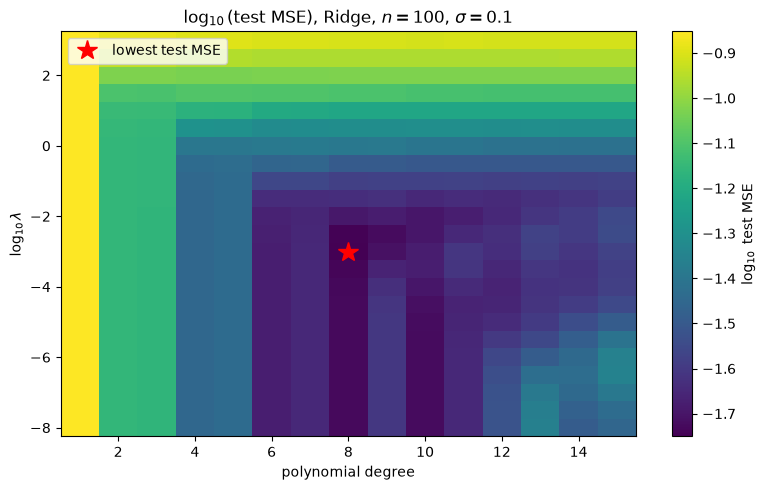

In [648]:
lambdas_grid = np.logspace(-8, 3, 23)                  # 1e-8 ... 1e3, two points per decade
mse_grid = np.array([ridge_degree_scan(x, y, lam)["mse_test"] for lam in lambdas_grid])
# mse_grid[i, j] = test MSE for lambda number i and degree j + 1

i_best, j_best = np.unravel_index(np.argmin(mse_grid), mse_grid.shape)   # row and column of the minimum
print(f"best Ridge on the grid: lambda = {lambdas_grid[i_best]:.1e}, degree = {degrees[j_best]}, "
      f"test MSE = {mse_grid[i_best, j_best]:.4f}")
print(f"best OLS (part a):      degree = {degrees[np.argmin(res['mse_test'])]}, "
      f"test MSE = {res['mse_test'].min():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(np.log10(mse_grid), origin="lower", aspect="auto", cmap="viridis",
               extent=[degrees[0] - 0.5, degrees[-1] + 0.5,          # x axis: degree
                       np.log10(lambdas_grid[0]) - 0.25, np.log10(lambdas_grid[-1]) + 0.25])  # y axis: log10(lambda)
ax.plot(degrees[j_best], np.log10(lambdas_grid[i_best]), "r*", ms=15, label="lowest test MSE")
ax.set_xlabel("polynomial degree")
ax.set_ylabel(r"$\log_{10}\lambda$")
ax.set_title(r"$\log_{10}$(test MSE), Ridge, $n=100$, $\sigma=0.1$")
fig.colorbar(im, ax=ax, label=r"$\log_{10}$ test MSE")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

#### b.5 Degree fixed at 15: $\lambda$ as the only dial
**Source:** adapted from `week35tuesday.ipynb`, Case 4, step 2 (fix degree 15, standardise with training
statistics, scan $\lambda$ with `ridge_svd`, record training and test MSE and the effective number of
parameters $\mathrm{df}(\lambda)=\sum_i \sigma_i^2/(\sigma_i^2+\lambda)$, lecture notes Section 3.8).
**Modifications:** Runge data and our own functions; a check that the training MSE never decreases
with $\lambda$ (lecture notes Eq. (3.91): the training error is minimised by OLS; week 35 exercise sheet,
exercise 4); df($\lambda$) at the best $\lambda$ is compared with the best OLS degree, as asked in the
"Your turn" of Case 4.
> **LLM note:** Written with Claude (Level 4), adapted from `week35tuesday.ipynb` Case 4.

training MSE non-decreasing in lambda: True
degree 15: best lambda = 5.0e-02, test MSE = 0.0256 (OLS degree 15: 0.0339; best OLS over degrees: 0.0187)
effective number of parameters at the best lambda: df = 7.6 (best OLS degree = 8, i.e. that many slope parameters)


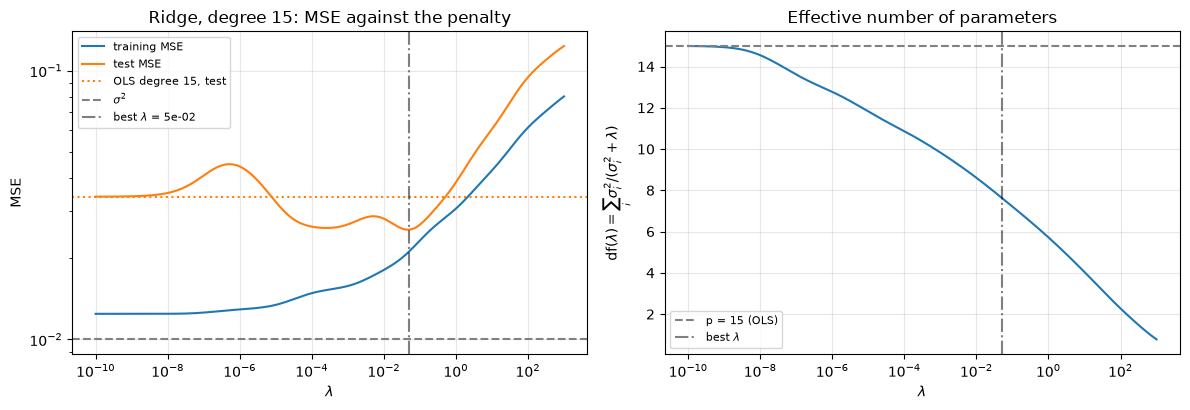

In [649]:
# X_train_s, X_test_s, y_train_c, y_mean, y_train, y_test: degree-15 matrices from cell b.1
lambdas_fine = np.logspace(-10, 3, 131)                # 10 points per decade
s15 = np.linalg.svd(X_train_s, compute_uv=False)       # singular values of the degree-15 training matrix

mse_train_lam, mse_test_lam, df_lam, theta_path = [], [], [], []
for lam in lambdas_fine:
    theta = ridge_svd(X_train_s, y_train_c, lam)
    mse_train_lam.append(MSE(y_train, X_train_s @ theta + y_mean))
    mse_test_lam.append(MSE(y_test, X_test_s @ theta + y_mean))
    df_lam.append(np.sum(s15**2 / (s15**2 + lam)))     # effective number of parameters (Section 3.8)
    theta_path.append(theta)
mse_train_lam, mse_test_lam = np.array(mse_train_lam), np.array(mse_test_lam)
df_lam, theta_path = np.array(df_lam), np.array(theta_path)   # theta_path: one row per lambda

# Eq. (3.91): OLS minimises the training error, so it can only grow with lambda
print("training MSE non-decreasing in lambda:", np.all(np.diff(mse_train_lam) >= -1e-12))

k = np.argmin(mse_test_lam)                            # index of the best lambda on the test set
best_lam = lambdas_fine[k]
print(f"degree 15: best lambda = {best_lam:.1e}, test MSE = {mse_test_lam[k]:.4f} "
      f"(OLS degree 15: {res['mse_test'][-1]:.4f}; best OLS over degrees: {res['mse_test'].min():.4f})")
print(f"effective number of parameters at the best lambda: df = {df_lam[k]:.1f} "
      f"(best OLS degree = {degrees[np.argmin(res['mse_test'])]}, i.e. that many slope parameters)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(lambdas_fine, mse_train_lam, label="training MSE")
ax1.plot(lambdas_fine, mse_test_lam, label="test MSE")
ax1.axhline(res["mse_test"][-1], color="C1", ls=":", label="OLS degree 15, test")
ax1.axhline(0.1**2, color="gray", ls="--", label=r"$\sigma^2$")
ax1.axvline(best_lam, color="k", ls="-.", alpha=0.5, label=rf"best $\lambda$ = {best_lam:.0e}")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel("MSE")
ax1.set_title("Ridge, degree 15: MSE against the penalty")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(lambdas_fine, df_lam)
ax2.axhline(p15, color="gray", ls="--", label=f"p = {p15} (OLS)")
ax2.axvline(best_lam, color="k", ls="-.", alpha=0.5, label=r"best $\lambda$")
ax2.set_xscale("log")
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel(r"df$(\lambda)=\sum_i \sigma_i^2/(\sigma_i^2+\lambda)$")
ax2.set_title("Effective number of parameters")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### b.6 The parameters: size against degree, and coefficient paths against $\lambda$
**Source:** the left panel repeats the $\|\boldsymbol\theta\|_2$ plot of a.8 for several $\lambda$. The right
panel is a coefficient path, the idea of `week35tuesday.ipynb`, Case 3 (there on a toy problem).
The check that $\|\hat{\boldsymbol\theta}_{\rm Ridge}\|_2$ decreases strictly with $\lambda$ is Proposition 3.5,
Eq. (3.53) of the lecture notes. The code is new.
> **LLM note:** Written with Claude (Level 4). New code.

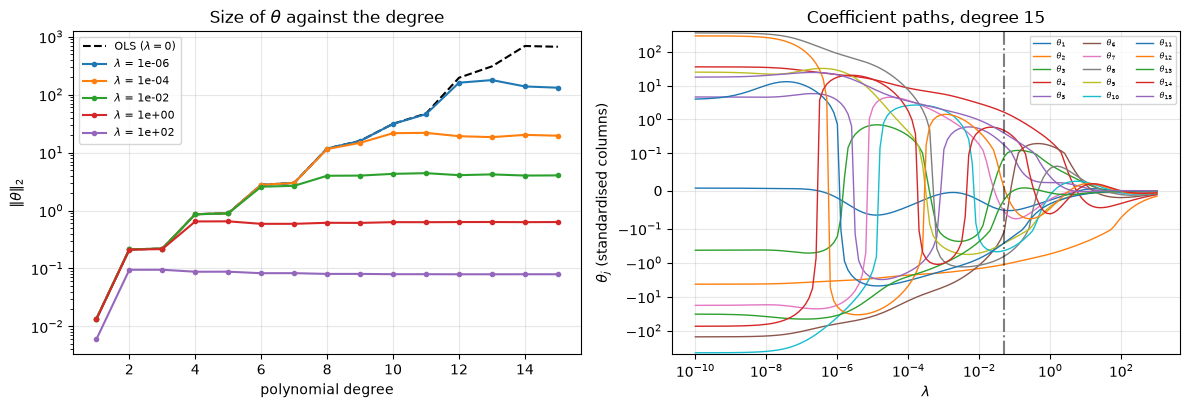

||theta|| strictly decreasing in lambda (Proposition 3.5): True
lambda = 1e-08: ||theta||_2 =   611.09, max |theta_j| =   410.25
lambda = 1e-04: ||theta||_2 =    19.53, max |theta_j| =    13.18
lambda = 1e-02: ||theta||_2 =     4.03, max |theta_j| =     2.96
lambda = 1e+00: ||theta||_2 =     0.63, max |theta_j| =     0.55
lambda = 1e+02: ||theta||_2 =     0.08, max |theta_j| =     0.07


In [650]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: ||theta||_2 against the degree, one curve per lambda (lambda = 0 is the curve of a.8)
for lam in lambdas_show:
    norms = [np.linalg.norm(th) for th in res_ridge[lam]["theta"]]   # length of theta for each degree
    label = r"OLS ($\lambda=0$)" if lam == 0 else rf"$\lambda$ = {lam:.0e}"
    ax1.plot(degrees, norms, "k--" if lam == 0 else "o-", ms=3, label=label)
ax1.set_yscale("log")
ax1.set_xlabel("polynomial degree")
ax1.set_ylabel(r"$\|\theta\|_2$")
ax1.set_title(r"Size of $\theta$ against the degree")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Right: every coefficient of the degree-15 model against lambda (theta_path from b.5)
for j in range(p15):
    ax2.plot(lambdas_fine, theta_path[:, j], lw=1, label=rf"$\theta_{{{j + 1}}}$")
ax2.set_xscale("log")
ax2.set_yscale("symlog", linthresh=0.1)   # linear between -0.1 and 0.1, logarithmic outside
ax2.axvline(best_lam, color="k", ls="-.", alpha=0.5)
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel(r"$\theta_j$ (standardised columns)")
ax2.set_title("Coefficient paths, degree 15")
ax2.legend(ncol=3, fontsize=6)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

norm_path = np.linalg.norm(theta_path, axis=1)          # ||theta(lambda)||_2 for every lambda
print("||theta|| strictly decreasing in lambda (Proposition 3.5):", np.all(np.diff(norm_path) < 0))
for lam in [1e-8, 1e-4, 1e-2, 1.0, 100.0]:
    i = np.argmin(np.abs(lambdas_fine - lam))            # closest lambda on the fine grid
    print(f"lambda = {lambdas_fine[i]:.0e}: ||theta||_2 = {norm_path[i]:8.2f}, "
          f"max |theta_j| = {np.max(np.abs(theta_path[i])):8.2f}")

#### b.7 Shrinkage of the singular-value modes (Section 3.8)
**Source:** lecture notes Section 3.8, Eqs. (3.46)–(3.48) and Fig. 3.1; week 35 Monday slides 13–15.
In the singular basis of $\boldsymbol X = \boldsymbol U\boldsymbol\Sigma\boldsymbol V^T$, OLS gives the coefficient
$(\boldsymbol u_i^T\boldsymbol y)/\sigma_i$ along each direction $\boldsymbol v_i$, and Ridge multiplies it by the
shrinkage factor $\sigma_i^2/(\sigma_i^2+\lambda)\le 1$, Eq. (3.48). Directions with $\sigma_i^2 \gg \lambda$
are kept, those with $\sigma_i^2 \ll \lambda$ are removed, and the switch sits at $\sigma_i^2 = \lambda$.
The noise part of the OLS coefficient along direction $i$ has variance $\sigma^2/\sigma_i^2$ (Eq. (3.42),
Section 3.7), so the removed directions are exactly the most noise-sensitive ones.
The code is new; it also checks Eq. (3.47) numerically.
> **LLM note:** Written with Claude (Level 4). New code.

Eq. (3.47) check, max |U diag(shrink) U^T y - X theta| = 4.218847493575595e-15

mode  sigma_i^2     OLS coeff   shrink factor   Ridge coeff
   0   7.50e+02      -0.028          1.000       -0.028
   1   3.68e+02       0.059          1.000        0.059
   2   4.84e+01       0.024          0.999        0.024
   3   2.60e+01      -0.276          0.998       -0.275
   4   5.47e+00      -0.194          0.991       -0.192
   5   1.56e+00      -0.822          0.969       -0.797
   6   3.34e-01       0.248          0.869        0.215
   7   6.18e-02       3.491          0.552        1.928
   8   1.38e-02      -2.842          0.216       -0.613
   9   2.14e-03     -10.821          0.041       -0.443
  10   2.75e-04       5.024          0.005        0.027
  11   1.86e-05      97.393          0.000        0.036
  12   2.53e-06     -98.563          0.000       -0.005
  13   1.01e-07    -653.503          0.000       -0.001
  14   1.80e-08      35.909          0.000        0.000


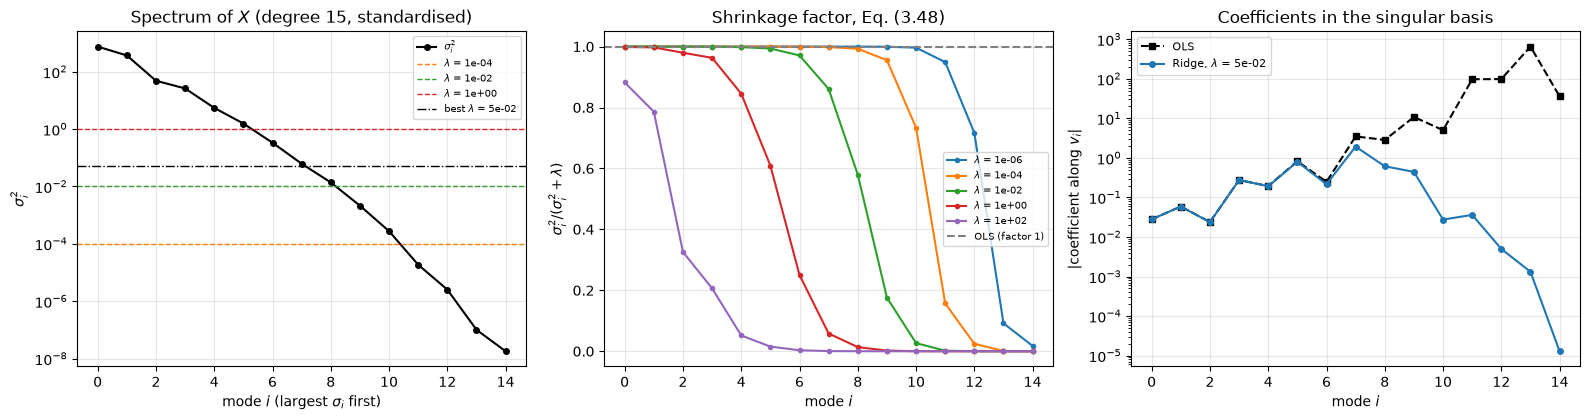

In [651]:
U, s_sv, Vt = np.linalg.svd(X_train_s, full_matrices=False)   # s_sv: singular values (not the noise sigma!)
modes = np.arange(len(s_sv))                                   # mode index i = 0, 1, ..., 14
proj = U.T @ y_train_c                                         # u_i^T y for every mode

# Check of Eq. (3.47): fitted values in the singular basis = X theta_Ridge
shrink_best = s_sv**2 / (s_sv**2 + best_lam)                   # Eq. (3.48) at the best lambda of b.5
y_fit_basis = U @ (shrink_best * proj)
print("Eq. (3.47) check, max |U diag(shrink) U^T y - X theta| =",
      np.max(np.abs(y_fit_basis - X_train_s @ ridge_svd(X_train_s, y_train_c, best_lam))))

coef_ols = proj / s_sv                                         # OLS coefficient along v_i: (u_i^T y) / s_i
coef_ridge = shrink_best * coef_ols                            # Ridge: the same, times the shrinkage factor
print("\nmode  sigma_i^2     OLS coeff   shrink factor   Ridge coeff")
for i in modes:
    print(f"{i:4d}  {s_sv[i]**2:9.2e}  {coef_ols[i]:10.3f}   {shrink_best[i]:12.3f}   {coef_ridge[i]:10.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

# Left: the squared singular values, with lines where sigma_i^2 = lambda
axes[0].semilogy(modes, s_sv**2, "ko-", ms=4, label=r"$\sigma_i^2$")
for lam, col in [(1e-4, "C1"), (1e-2, "C2"), (1.0, "C3")]:          # same colours as in the middle panel
    axes[0].axhline(lam, color=col, ls="--", lw=1, label=rf"$\lambda$ = {lam:.0e}")
axes[0].axhline(best_lam, color="k", ls="-.", lw=1, label=rf"best $\lambda$ = {best_lam:.0e}")
axes[0].set_xlabel(r"mode $i$ (largest $\sigma_i$ first)")
axes[0].set_ylabel(r"$\sigma_i^2$")
axes[0].set_title(r"Spectrum of $X$ (degree 15, standardised)")
axes[0].legend(fontsize=7)

# Middle: the shrinkage factor of Eq. (3.48) per mode
for lam in [1e-6, 1e-4, 1e-2, 1.0, 100.0]:
    axes[1].plot(modes, s_sv**2 / (s_sv**2 + lam), "o-", ms=3, label=rf"$\lambda$ = {lam:.0e}")
axes[1].axhline(1.0, color="gray", ls="--", label="OLS (factor 1)")
axes[1].set_xlabel(r"mode $i$")
axes[1].set_ylabel(r"$\sigma_i^2/(\sigma_i^2+\lambda)$")
axes[1].set_title("Shrinkage factor, Eq. (3.48)")
axes[1].legend(fontsize=7)

# Right: size of the coefficient along each mode, OLS against Ridge at the best lambda
axes[2].semilogy(modes, np.abs(coef_ols), "ks--", ms=4, label="OLS")
axes[2].semilogy(modes, np.abs(coef_ridge), "o-", ms=4, label=rf"Ridge, $\lambda$ = {best_lam:.0e}")
axes[2].set_xlabel(r"mode $i$")
axes[2].set_ylabel(r"$|$coefficient along $v_i|$")
axes[2].set_title("Coefficients in the singular basis")
axes[2].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### b.8 Dependence on the noise level $\sigma$ and the number of points $n$
**Source:** the "Your turn" of `week35tuesday.ipynb`, Case 4 (vary the noise level and the number of
points; how do the optimal degree and the optimal $\lambda$ move?). The code is new.
Degree fixed at 15; one data set and one split per curve, so the exact optimum is noisy.
> **LLM note:** Written with Claude (Level 4). New code.

varying sigma (n = 100):
  sigma = 0.00: best lambda = 6e-08, Ridge test MSE = 0.00031, best OLS (any degree) = 0.00151
  sigma = 0.05: best lambda = 4e-05, Ridge test MSE = 0.00703, best OLS (any degree) = 0.00550
  sigma = 0.10: best lambda = 4e-02, Ridge test MSE = 0.02562, best OLS (any degree) = 0.01871
  sigma = 0.30: best lambda = 2e-01, Ridge test MSE = 0.15384, best OLS (any degree) = 0.13305
varying n (sigma = 0.1):
  n =   50: best lambda = 1e-10, Ridge test MSE = 0.0140, best OLS (any degree) = 0.0135
  n =  100: best lambda = 4e-02, Ridge test MSE = 0.0256, best OLS (any degree) = 0.0187
  n =  500: best lambda = 2e-07, Ridge test MSE = 0.0146, best OLS (any degree) = 0.0144
  n = 2000: best lambda = 2e-06, Ridge test MSE = 0.0119, best OLS (any degree) = 0.0119


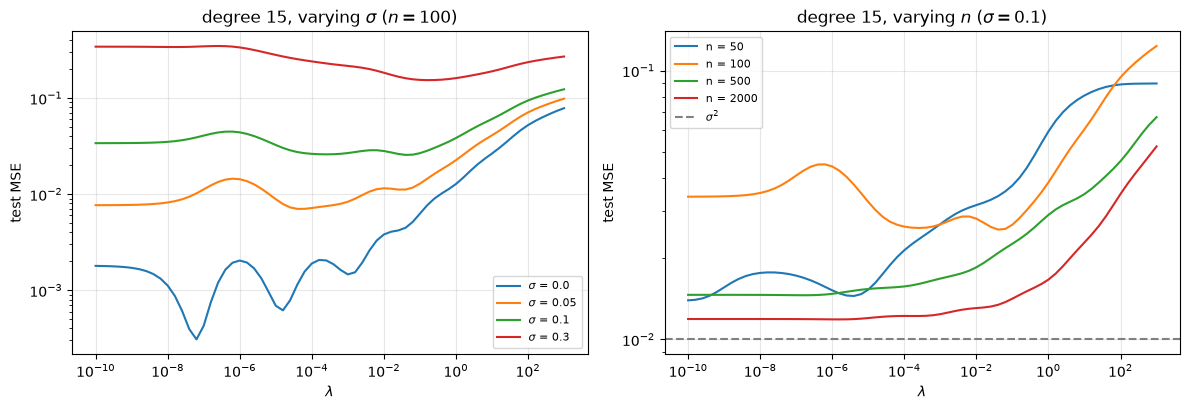

In [652]:
def degree15_lambda_scan(x, y, lambdas):
    """Test MSE of degree-15 Ridge for every lambda (one fixed 80/20 split, training-set scaling)."""
    x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=TEST_SIZE, random_state=SEED)
    Xtr_s, Xte_s, ytr_c, ym = scale_train_test(polynomial_features(x_tr, 15),
                                               polynomial_features(x_te, 15), y_tr)
    return np.array([MSE(y_te, Xte_s @ ridge_svd(Xtr_s, ytr_c, lam) + ym) for lam in lambdas])


lambdas_nd = np.logspace(-10, 3, 66)                   # 5 points per decade
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

print("varying sigma (n = 100):")
for s in [0.0, 0.05, 0.1, 0.3]:
    x_s, y_s = make_data(n=100, sigma=s)
    mse_s = degree15_lambda_scan(x_s, y_s, lambdas_nd)
    best_ols = ols_degree_scan(x_s, y_s)["mse_test"].min()          # best OLS over the degrees
    axes[0].loglog(lambdas_nd, mse_s, label=rf"$\sigma$ = {s}")
    print(f"  sigma = {s:4.2f}: best lambda = {lambdas_nd[np.argmin(mse_s)]:.0e}, "
          f"Ridge test MSE = {mse_s.min():.5f}, best OLS (any degree) = {best_ols:.5f}")
axes[0].set_title(r"degree 15, varying $\sigma$ ($n=100$)")

print("varying n (sigma = 0.1):")
for n in [50, 100, 500, 2000]:
    x_n, y_n = make_data(n=n, sigma=0.1)
    mse_n = degree15_lambda_scan(x_n, y_n, lambdas_nd)
    best_ols = ols_degree_scan(x_n, y_n)["mse_test"].min()
    axes[1].loglog(lambdas_nd, mse_n, label=f"n = {n}")
    print(f"  n = {n:4d}: best lambda = {lambdas_nd[np.argmin(mse_n)]:.0e}, "
          f"Ridge test MSE = {mse_n.min():.4f}, best OLS (any degree) = {best_ols:.4f}")
axes[1].axhline(0.1**2, color="gray", ls="--", label=r"$\sigma^2$")
axes[1].set_title(r"degree 15, varying $n$ ($\sigma=0.1$)")

for ax in axes:
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel("test MSE")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### b.9 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions
> (text Level 3 if used as it is). Rewrite in your own words for the report, and check every
> number against your own run. **[own]** marks reasoning that is not taken from the course material.

**Notation.** In this part $\sigma_i$ denotes the **singular values** of the standardised design matrix
$\boldsymbol X = \boldsymbol U\boldsymbol\Sigma\boldsymbol V^T$, while $\sigma$ (without index) is the **noise level**.
The lecture notes use the same letter for both; in the report we should use a different symbol for the
singular values (for example $s_i$), or state the difference explicitly.

1. **Checks and numerical accuracy (b.1).** $\lambda = 0$ reproduces `ols_svd` ($1\cdot10^{-13}$, relative
   $\sim10^{-16}$), and $\lambda=0$ in b.3 reproduces the test MSE of part a). Our Ridge agrees with the normal
   equations (3.44) and with `Ridge(alpha=lambda)` to a relative $10^{-10}$ at $\lambda=10^{-4}$, improving to
   $2\cdot10^{-15}$ at $\lambda=100$. This also confirms that our $\lambda$ is sklearn's `alpha` (no $1/n$). The
   agreement follows the condition number $(\sigma_{\max}^2+\lambda)/(\sigma_{\min}^2+\lambda)$ of
   $\boldsymbol X^T\boldsymbol X+\lambda\boldsymbol I$ (Section 1.12): about $7\cdot10^6$ at $\lambda=10^{-4}$ and 9 at
   $\lambda=100$ [own numbers]. Forming $\boldsymbol X^T\boldsymbol X$ squares the condition number (Eq. (1.118)),
   while our SVD route works with $\boldsymbol X$ directly. So a positive $\lambda$ makes the matrix invertible and
   better conditioned (Section 3.8, after Eq. (3.44)), but the value of $\lambda$ is chosen by the bias-variance
   trade-off, not for numerical reasons.

2. **Ridge against OLS over the degree (b.3).** (i) Ridge always raises the training error: OLS is by
   definition the fit with the smallest training error (Eq. (3.91)); at degree 15 it goes from 0.0124 (OLS) to
   0.015, 0.018, 0.031 and 0.061 for $\lambda = 10^{-4}, 10^{-2}, 1, 100$. (ii) At high degree, where OLS
   overfits, a moderate penalty lowers the test error (degree 15: 0.026 for $\lambda=10^{-4}$ against 0.034 for
   OLS): a little bias buys a larger reduction in variance (Section 3.8, Eqs. (3.50)–(3.52)). (iii) At low degree
   there is little variance to remove, and small $\lambda$ changes nothing; the best results are practically
   equal (0.0185 at $\lambda=10^{-4}$, degree 8, against 0.0187 for OLS). (iv) Too large a penalty underfits:
   for $\lambda=1$ and 100 the curves are flat in the degree (test MSE 0.04 and 0.094, $R^2 = 0.25$). (v) A very
   small penalty does not always help on a given split ($\lambda = 10^{-6}$ gives 0.044 at degree 15) [own
   observation]. The degree and $\lambda$ are two dials for the same complexity (`week35tuesday` Case 4): with a
   small $\lambda$ the degree decides, with a large $\lambda$ the penalty decides.

3. **Both dials at once (b.4).** The heatmap shows 23 values of $\lambda$ instead of 6. The lowest test MSE is
   at $\lambda = 10^{-3}$, degree 8 (0.0178, against 0.0187 for OLS), but it is chosen on the test set and the gain
   is within the split-to-split noise. Three further features [own reading]: the low-error valley runs
   diagonally (a higher degree needs a larger $\lambda$); the minimum is broad (degrees 6–10 and
   $\lambda \lesssim 10^{-2}$ give similar errors, "model selection rarely has a sharp answer",
   `week36tuesday` Case 1); and the columns come in pairs (2–3, 4–5, 6–7), because odd powers add almost
   nothing to an even function (part a).

4. **Degree 15, with $\lambda$ as the only dial (b.5).** Reading the test curve from left to right: for tiny
   $\lambda$ it equals OLS (0.034); it falls to a minimum at $\lambda = 5\cdot10^{-2}$ (0.0256, 25 % lower); and for
   $\lambda \gtrsim 1$ it rises steeply, to about 0.12 at $\lambda = 1000$, more than three times the unpenalised
   value. Too large a penalty adds more bias than the variance it removes. The training MSE rises steadily over
   the whole range (Eq. (3.91)). The effective number of parameters
   $\mathrm{df}(\lambda)=\sum_i\sigma_i^2/(\sigma_i^2+\lambda)$ (Section 3.8) falls smoothly from 15 to about 1. Each
   term is the fraction of mode $i$ that Ridge keeps, so df is a sum of fractions and need not be an integer
   [own]. At the best $\lambda$, df $= 7.6$, close to the 8 slope parameters of the best OLS degree: both dials settle
   on a model of about the same effective size (comparison asked in `week35tuesday` Case 4; reading ours).

5. **The parameters (b.6).** ‖θ‖₂ decreases strictly with $\lambda$ (Proposition 3.5, Eq. (3.53)): 668, 131,
   20, 2.3 and 0.08 for $\lambda = 10^{-10}, 10^{-6}, 10^{-4}, 5\cdot10^{-2}$ and 100. Against the degree, every
   $\lambda$ puts a ceiling on ‖θ‖₂ (about 20 for $\lambda=10^{-4}$, 4 for $10^{-2}$, 0.6 for 1), while OLS grows to
   about 670: Ridge is equivalent to fitting inside the ball $\|\boldsymbol\theta\|^2 \le t$ (Eq. (3.45)). The
   individual coefficients do **not** shrink one by one [own reading]. At $\lambda\approx0$, $\theta_8 = +356$ and
   $\theta_{10} = -451$ nearly cancel, since $x^8$ and $x^{10}$ are almost identical on $[-1,1]$. Between
   $\lambda \approx 10^{-7}$ and $10^{-4}$ these pairs collapse: $\theta_8$ falls to 7, and $\theta_{10}$ changes sign
   twice ($-451 \to +2.6 \to -0.4$). By contrast $\theta_2$, which carries the main shape of the peak, shrinks
   smoothly ($-4.3 \to -2.3 \to -1.1 \to -0.07$). The coefficients that swing are not unimportant; they are the
   ones the data cannot pin down. Uniform shrinkage by $1/(1+\lambda)$ holds only for an orthonormal design
   (Eq. (3.49)), and Ridge never sets a coefficient exactly to zero (contrast with the Lasso, part g).

6. **Shrinkage of the singular modes (b.7; Section 3.8).** The SVD describes the fit through 15 directions
   (modes) $\boldsymbol v_i$, each a fixed combination of the columns, ordered by $\sigma_i$. $\sigma_i^2$ measures how
   much the data spread along direction $i$. For our matrix it runs from 750 to $1.8\cdot10^{-8}$; the
   $\sigma_i^2$ add up to $n_{\rm train}\,p = 80\cdot15 = 1200$, the total spread of 15 standardised columns [own check].
   The coefficient of mode $i$ has variance $\sigma^2/\sigma_i^2$ (Eq. (3.42)): **a big singular value means a
   small variance**, like a slope fitted to widely spread $x$ values [own analogy].
   - *Why OLS gives the weak modes huge coefficients.* Using $\boldsymbol X\boldsymbol v_i = \sigma_i\boldsymbol u_i$, the training
     error splits into one term per mode, $(\boldsymbol u_i^T\boldsymbol y - \sigma_i c_i)^2$ [own derivation; result is
     Eq. (3.11)]. OLS sets every term to zero with $c_i = (\boldsymbol u_i^T\boldsymbol y)/\sigma_i$: how much of pattern
     $\boldsymbol u_i$ is in the data, divided by how strongly the parameters produce it. For mode 13,
     $0.21/0.00032 \approx 650$, bought for a gain of only 0.0005 in the training MSE. OLS has no cost for large
     coefficients, so it always makes this trade [own numbers].
   - *What Ridge does.* It multiplies each coefficient by $\sigma_i^2/(\sigma_i^2+\lambda)$ (Eq. (3.48)), which is
     equivalent to charging $\lambda c_i^2$ for every mode. At the best $\lambda = 5\cdot10^{-2}$ modes 0–6 are kept
     (factor $\ge 0.87$), mode 7 is halved, mode 8 cut to 0.22, and modes 9–14 are removed; the OLS coefficients
     97, $-99$ and $-654$ on modes 11–13 become 0.04, 0.005 and 0.001. The switch sits where
     $\sigma_i^2 \approx \lambda$ (Fig. 3.1), and the factors add up to df $= 7.6$. Eq. (3.47) is confirmed to
     $6\cdot10^{-15}$.
   - *The trade-off per direction.* The weak modes do carry some real detail of $f$: without noise, degree-15
     Ridge with almost all modes kept beats the best OLS by a factor of 5 (b.8). With noise, keeping a weak mode
     costs variance $\sigma^2/\sigma_i^2$ (for mode 13 a standard deviation of about 300 on a coefficient of 650),
     while dropping it costs only its small share of $f$, the bias of Eq. (3.50). In the singular basis the
     squared bias and variance per mode are those of Eq. (3.54); minimising their sum gives the best penalty for
     a single direction, $\lambda_i^* = \sigma^2/b_i^2$ [own step], which grows with the noise.
   - *Why the df curve is so smooth.* The $\sigma_i^2$ spread over ten orders of magnitude, so $\lambda$ passes
     them one after another, roughly one to two modes per decade [own reading]. For an orthonormal design
     (all $\sigma_i$ equal) df would drop in a single step. The long slope is a direct sign of the
     ill-conditioning of the polynomial design matrix (Section 1.12, Fig. 1.2).

7. **Noise level (b.8).** The best $\lambda$ grows with the noise: $6\cdot10^{-8}$, $4\cdot10^{-5}$, $4\cdot10^{-2}$
   and $2\cdot10^{-1}$ for $\sigma = 0$, 0.05, 0.1, 0.3. More noise makes more modes not worth keeping,
   consistent with $\lambda_i^* = \sigma^2/b_i^2$. With noise ($\sigma\ge0.05$), degree-15 Ridge is still worse than
   OLS at its best degree (0.0256 against 0.0187 at $\sigma = 0.1$): on this problem, choosing the degree is at
   least as effective as the penalty.

8. **Why the curves against $\lambda$ look the way they do (b.8) [own].** Every curve is a film of Ridge
   switching off modes, from the weakest to the strongest. It is *flat on the left* while $\lambda$ is below
   every $\sigma_i^2$ (nothing is switched off: OLS). It has *bumps or a valley in the middle* while the weak
   modes are switched off one by one ($\lambda \approx 10^{-8}$ to $10^{-2}$): each removal changes the fit, and
   lowers or raises the test error depending on whether that mode was hurting or helping at the test points. It
   *rises on the right* once the strong modes, which carry the shape of the peak, are removed. For $\sigma = 0$
   the dips and bumps sit at $\lambda \approx \sigma_i^2$ of modes 14–9 (annotated figure, b.8 extra). Removing
   mode 14 lowers the test error slightly, removing mode 11 raises it clearly. Even without noise there is
   something to overfit: Runge's function is not a polynomial, and the approximation error left at the training
   points acts like a fixed, deterministic noise that the weakest modes fit. Hence a tiny $\lambda$ still helps
   (0.0018 → 0.0003). The log scale exaggerates these changes, which are below 0.002 in absolute terms, and the
   same wiggles are present but less visible in the noisy curves. **The positions of the wiggles depend on the
   data set:** with seeds 2027 and 2028 the $\sigma = 0$ curve has a single dip instead of three.

9. **Number of points, and a warning about single splits (b.8; seed check in b.8 extra).** For $n = 500$ and
   2000 the curves are flat for small $\lambda$: the weak modes are well determined, OLS is already good, and the
   penalty only adds bias. The apparently good result for $n = 50$ is luck. Its 10 test points happen to lie in
   $|x| \le 0.58$, away from the edges where degree-15 fits oscillate (Runge's phenomenon, part a); seed 2026 is
   the only one of 40 seeds with such a test set. Repeated over 40 seeds [own check], the median test MSE at
   degree 15 is 0.022, 0.014, 0.011 and 0.0105 for $n$ = 50, 100, 500, 2000. Small $n$ has occasional catastrophic
   errors (up to about 900 for $n = 50$, 1.5 for $n = 100$), all from test sets reaching $|x| > 0.9$, while for
   $n \ge 500$ every seed gives 0.010–0.015. In this convention $\sigma_i^2$ also grows roughly in proportion to
   $n_{\rm train}$, so the same $\lambda$ is a weaker penalty for larger $n$ [own reasoning]; $\lambda/n_{\rm train}$ (the
   convention of part e) is the better quantity to compare across $n$.

10. **Ridge against OLS, in short [own summary].** Ridge controls the size of $\boldsymbol\theta$ and the variance at
    high degree by switching off the weakest singular modes, and it makes the result much less sensitive to the
    chosen degree. On this data set its best test MSE is only slightly lower than the best OLS (0.0178 against
    0.0187, both chosen on the test set). Its benefit is largest when the model is far too flexible for the data:
    high degree, few points, or no noise to hide the ill-conditioning.

11. **Caveat.** One data set and one 80/20 split per curve; $\lambda$ and the degree are chosen on the test set,
    which is optimistic; single-split curves with 10–20 test points can be misleading (point 9); and $\lambda$
    follows Eq. (3.44) (no $1/n$), so it corresponds to $\lambda/n_{\rm train}$ in part e). Reliable model selection
    is done with resampling and cross-validation in parts c), d) and i).

### Part c): The bias-variance tradeoff and the bootstrap

Our aim here is to study the bias-variance tradeoff by implementing the
**bootstrap** resampling technique. **We will only use the simpler ordinary
least squares here.**

Before you perform an analysis of the bias-variance tradeoff on your test data,
make first a figure similar to Fig. 2.11 of Hastie, Tibshirani and Friedman.
Figure 2.11 of this reference displays only the test and training MSEs. The
test MSE can be used to indicate possible regions of low/high bias and variance.
You will most likely not get an equally smooth curve! You will also need to
increase the polynomial order and play around with the number of data points as
well (see the exercise sets from week 35 and week 36).

With this result we move on to the bias-variance tradeoff analysis. Consider a
data set $\mathcal{L}$ consisting of the data
$\boldsymbol{X}_\mathcal{L}=\{(y_j,\boldsymbol{x}_j),\,j=0,\dots,n-1\}$, and
assume that the true data are generated from a noisy model

$$
\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon},
$$

where $\boldsymbol{\varepsilon}$ is normally distributed with mean zero and
variance $\sigma^2$. In our derivation of the ordinary least squares method we
defined an approximation to the function $f$ in terms of the parameters
$\boldsymbol{\theta}$ and the design matrix $\boldsymbol{X}$ which embody our
model, that is $\tilde{\boldsymbol{y}}=\boldsymbol{X}\boldsymbol{\theta}$. The
parameters $\boldsymbol{\theta}$ are in turn found by optimizing the mean squared
error via the cost function

$$
C(\boldsymbol{X},\boldsymbol{\theta}) = \frac{1}{n}\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2
 = \mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right].
$$

Here the expected value $\mathbb{E}$ is the sample value.

Show that you can rewrite this in terms of a term which contains the variance of
the model itself (the so-called variance term), a term which measures the
deviation from the true data and the mean value of the model (the bias term) and
finally the variance of the noise. That is, show that

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
 = \mathrm{Bias}^2[\tilde{y}] + \mathrm{var}[\tilde{y}] + \sigma^2,
$$

with

$$
\mathrm{Bias}^2[\tilde{y}] = \mathbb{E}\left[\left(\boldsymbol{f}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right],
\qquad
\mathrm{var}[\tilde{y}] = \mathbb{E}\left[\left(\tilde{\boldsymbol{y}}-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2\right]
 = \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2 .
$$

**Important note:** since the function $f(x)$ is unknown, in order to be able to
evaluate the bias we replace $f(\boldsymbol{x})$ in the expression for the bias
with $\boldsymbol{y}$; discuss what this does to the measured bias term (it
absorbs the noise variance $\sigma^2$). Explain what the three terms mean and
discuss their interpretations, and state clearly over which randomness the
expectation values are taken.

The answer to this exercise should be included in the theory part of the
report. This derivation is also part of the weekly exercises of week 36, and it
is Eq. (2.52) of Chapter 2 of the lecture notes.

Perform then a bias-variance analysis of the Runge function by studying the MSE
value as function of the complexity of your model, using the **bootstrap**
resampling method to estimate the expectation values over training sets.
Discuss the bias and variance tradeoff as function of your model complexity (the
degree of the polynomial) and the number of data points. You can follow the
code examples in Sections 2.10 and 2.11 of the lecture notes and the Tuesday
notebook of week 36 (`week36tuesday.ipynb`).

## Part c): The bias-variance tradeoff and the bootstrap — code

**Sources for this part (course material, cited in the bibliography):**

| Piece | Course source | Status |
|---|---|---|
| training and test error against complexity | Hastie et al., Fig. 2.11; lecture notes Section 2.9; exercise-3 figure of `week35tuesday.ipynb` | new code, reuses `ols_degree_scan` |
| derivation of the decomposition | lecture notes Section 2.10, Eqs. (2.49)–(2.52); week 36 Monday slides 20–21; week 36 exercise sheet | written out in c.1 |
| "the measured bias absorbs $\sigma^2$" | lecture notes Section 2.10; week 36 Monday slides 25–26 | discussed in c.1 |
| bootstrap estimates of error, bias$^2$, variance | `week36tuesday.ipynb` Case 1, Step 1; lecture notes Section 2.10 (code after Eq. (2.52)) | adapted |
| resampling indices with `rng.integers(0, n, n)` | lecture notes Section 2.11 (function `bootstrap`) | adapted |
| sweep over the degree and over $n$ | `week36tuesday.ipynb` Case 1, Steps 1–2 (`bias_variance_sweep`) | adapted |

> **LLM note:** All code cells of part c) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course material listed above as the base. The theory text in c.1 was drafted
> with Claude (text Level 3 if used as it is in the report).

#### c.1 Theory: the bias-variance decomposition (for the theory section of the report)
> **LLM note:** Drafted with Claude (text Level 3 if used as it is). The derivation follows the lecture
> notes, Section 2.10, Eqs. (2.49)–(2.52).

**Set-up and randomness.** The data are generated as $y = f(x) + \varepsilon$ with
$\varepsilon \sim \mathcal N(0,\sigma^2)$, Eq. (2.49). A training set $\mathcal L$ is drawn at random and the
model is fitted to it, so the prediction $\tilde y_i = \tilde y(x_i;\mathcal L)$ at a test input $x_i$ is a
**random variable**: redraw $\mathcal L$ and the fitted polynomial moves. The test output
$y_i = f_i + \varepsilon_i$ carries its own noise $\varepsilon_i$, independent of $\mathcal L$.
The expectation $\mathbb E$ below is taken over **two sources of randomness: the training set $\mathcal L$
and the test noise $\varepsilon_i$**, with the test inputs $x_i$ held fixed (lecture notes Section 2.10;
week 36 Monday slide 20). The average $\frac1n\sum_i$ over the test points is a separate, ordinary
sample average. $f_i = f(x_i)$ is not random.

**Derivation.** For one test point, add and subtract the average prediction $\mathbb E[\tilde y_i]$
(Eq. (2.51)):
$$
y_i - \tilde y_i = \underbrace{\big(f_i - \mathbb E[\tilde y_i]\big)}_{a_i\ \text{(fixed)}}
+ \underbrace{\big(\mathbb E[\tilde y_i] - \tilde y_i\big)}_{b_i\ \text{(depends on } \mathcal L)}
+ \underbrace{\varepsilon_i}_{\text{test noise}} .
$$
Squaring gives $a_i^2 + b_i^2 + \varepsilon_i^2 + 2a_ib_i + 2a_i\varepsilon_i + 2b_i\varepsilon_i$. Taking the
expectation, the three cross terms vanish:
- $\mathbb E[a_ib_i] = a_i\,\mathbb E[b_i] = 0$, because $a_i$ is not random and $\mathbb E[b_i] = \mathbb E[\tilde y_i] - \mathbb E[\tilde y_i] = 0$;
- $\mathbb E[a_i\varepsilon_i] = a_i\,\mathbb E[\varepsilon_i] = 0$, because the noise has zero mean;
- $\mathbb E[b_i\varepsilon_i] = \mathbb E[b_i]\,\mathbb E[\varepsilon_i] = 0$, because the test noise is **independent** of the training set.

The squared terms give $a_i^2$, $\mathbb E[b_i^2] = \mathrm{Var}[\tilde y_i]$ and $\mathbb E[\varepsilon_i^2] = \sigma^2$.
Averaging over the $n$ test points gives Eq. (2.52):
$$
\mathbb E\big[(\boldsymbol y - \tilde{\boldsymbol y})^2\big]
= \underbrace{\frac1n\sum_i \big(f_i - \mathbb E[\tilde y_i]\big)^2}_{\mathrm{Bias}^2[\tilde y]}
+ \underbrace{\frac1n\sum_i \mathbb E\big[(\tilde y_i - \mathbb E[\tilde y_i])^2\big]}_{\mathrm{var}[\tilde y]}
+ \sigma^2 .
$$

**Meaning of the three terms** (lecture notes Section 2.10).
- *Bias$^2$*: how far the **average** prediction is from the truth. It comes from the limitations of the
  model family (a low-degree polynomial cannot make Runge's sharp peak), and more data do not remove it.
- *Variance*: how much the prediction moves when the training set is redrawn. A flexible model follows
  the noise of whichever sample it gets, so its predictions change from one training set to the next.
- *$\sigma^2$*: the irreducible error, the variance of the noise itself. No model can predict it, so it is
  a floor under the expected test error.

Increasing the complexity (the degree) lowers the bias and raises the variance; the expected test error,
their sum plus $\sigma^2$, has a minimum in between.

**Replacing $f$ by $y$: the measured bias absorbs $\sigma^2$.** In practice $f$ is unknown, so the bias is
computed with the test data $y_i = f_i + \varepsilon_i$ in place of $f_i$. Expanding,
$$
\frac1n\sum_i \big(y_i - \mathbb E[\tilde y_i]\big)^2
= \mathrm{Bias}^2 + \frac1n\sum_i \varepsilon_i^2 + \frac2n\sum_i \varepsilon_i\big(f_i - \mathbb E[\tilde y_i]\big).
$$
Taking the expectation over the test noise, the last term vanishes and $\frac1n\sum_i\varepsilon_i^2 \to \sigma^2$:
the **measured bias equals $\mathrm{Bias}^2 + \sigma^2$ on average**, so the decomposition becomes
$\text{Error} = (\mathrm{Bias}^2 + \sigma^2) + \mathrm{var}$ with no separate noise term
(lecture notes Section 2.10; week 36 Monday slides 25–26). The measured bias therefore cannot go much
below $\sigma^2$, even for a perfect model.

#### c.2 Training and test error against complexity (analogue of Hastie et al., Fig. 2.11)
**Source:** the shape is described in lecture notes Section 2.9 (the training error falls monotonically, the
test error has a minimum); layout from the exercise-3 figure of `week35tuesday.ipynb`; the figure itself is
Hastie et al., Fig. 2.11. **Modifications:** as asked in the project text, degrees up to 25 and several numbers
of data points ($n$ = 40, 100, 400, 1000), one data set per panel, using `ols_degree_scan` from part a)
(80/20 split, training-set scaling). The dashed vertical line marks the lowest test MSE.
> **LLM note:** Written with Claude (Level 4). New code, reuses `make_data` and `ols_degree_scan`.

   n   lowest test MSE at degree   test MSE there   training MSE at degree 25
   40                6              0.0215           0.0025
  100                8              0.0187           0.0093
  400               15              0.0100           0.0101
 1000               17              0.0102           0.0095


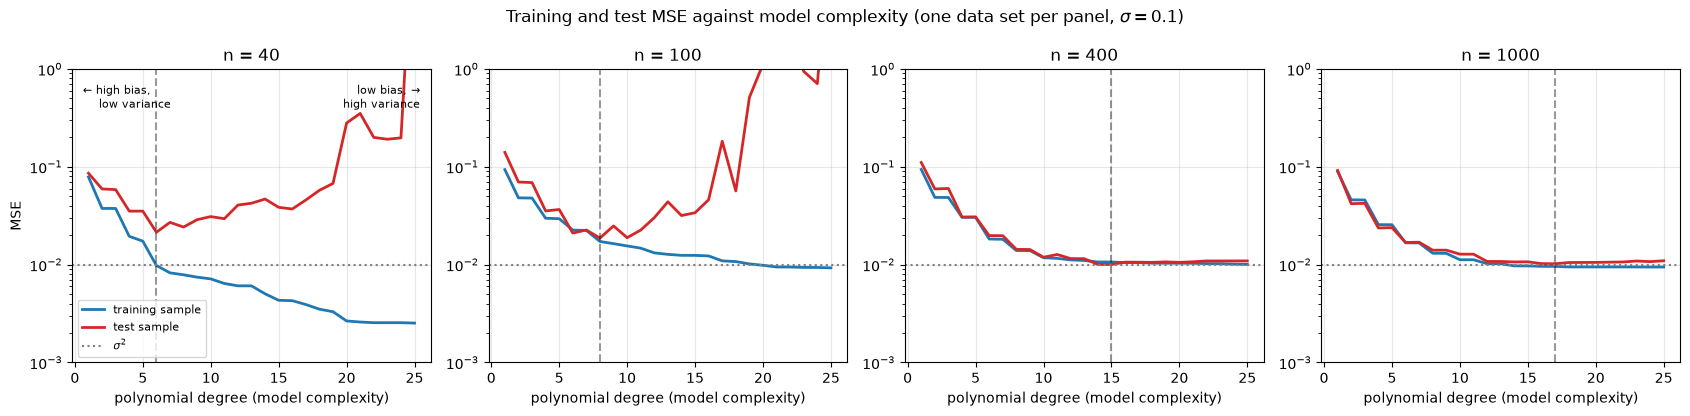

In [653]:
DEG_HIGH = 25                                   # go beyond degree 15, as the project text asks
deg_high = np.arange(1, DEG_HIGH + 1)
n_values_211 = [40, 100, 400, 1000]             # "play around with the number of data points"

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
print("   n   lowest test MSE at degree   test MSE there   training MSE at degree 25")
for ax, n_c in zip(axes, n_values_211):
    x_c, y_c = make_data(n=n_c, sigma=0.1)                   # ONE data set, as in the lecture figure
    res_c = ols_degree_scan(x_c, y_c, max_degree=DEG_HIGH)   # same 80/20 split and scaling as part a)
    ax.plot(deg_high, res_c["mse_train"], "-", color="C0", lw=2, label="training sample")
    ax.plot(deg_high, res_c["mse_test"], "-", color="C3", lw=2, label="test sample")
    ax.axhline(0.1**2, color="gray", ls=":", label=r"$\sigma^2$")
    best = np.argmin(res_c["mse_test"])
    ax.axvline(deg_high[best], color="k", ls="--", alpha=0.4)
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1.0)                     # same range in every panel; very large test errors leave the plot
    ax.set_xlabel("polynomial degree (model complexity)")
    ax.set_title(f"n = {n_c}")
    ax.grid(alpha=0.3)
    print(f"{n_c:5d}   {deg_high[best]:14d}              {res_c['mse_test'][best]:.4f}"
          f"           {res_c['mse_train'][-1]:.4f}")

axes[0].set_ylabel("MSE")
axes[0].legend(fontsize=8, loc="lower left")
# the two regions of Hastie et al., Fig. 2.11, written in the first panel
axes[0].text(0.03, 0.95, "\u2190 high bias,\n    low variance", transform=axes[0].transAxes, fontsize=8, va="top")
axes[0].text(0.97, 0.95, "low bias, \u2192\nhigh variance", transform=axes[0].transAxes, fontsize=8,
             va="top", ha="right")
fig.suptitle(r"Training and test MSE against model complexity (one data set per panel, $\sigma = 0.1$)")
plt.tight_layout()
plt.show()

#### c.3 The bootstrap estimate of error, bias$^2$ and variance
**Source:** the three formulas are those of `week36tuesday.ipynb`, Case 1, Step 1 (and the code after
Eq. (2.52) in Section 2.10 of the lecture notes): the bootstrap replaces the expectation over training sets
by an average over $B$ resamples of the training set, drawn with replacement (Section 2.11). Predictions
are stored in a matrix with one column per bootstrap sample, and expectations over training sets are
averages along axis 1. $B = 100$ as in the course notebook. The resampling indices are drawn with
`rng.integers(0, n, n)`, as in the `bootstrap` function of Section 2.11; the sweep over degrees follows
`bias_variance_sweep` of Case 1, Step 2.

**Modifications:**
1. Our own OLS (`ols_svd`) and scaling instead of the Scikit-Learn pipeline. Each bootstrap model is
   scaled with the statistics of its own bootstrap sample, since that sample is its training set.
2. Our `y_test` is a 1-D array, so it is turned into a column with `y_test[:, None]`; without this the
   subtraction from the (n_test, B) matrix would broadcast wrongly (the same pitfall that `keepdims=True`
   guards against in the course code).
3. The bootstrap indices are drawn once per data set and used for every degree.
> **LLM note:** Written with Claude (Level 4), adapted from `week36tuesday.ipynb` Case 1.

In [654]:
def bootstrap_bias_variance(x_train, y_train, x_test, y_test, degree, boot_idx):
    """
    Bootstrap estimates of test error, bias^2 (measured with y_test) and variance
    for an OLS polynomial of the given degree.

    boot_idx : integer array of shape (B, n_train), row b = indices of bootstrap sample b.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted the bootstrap loop and the error/bias/variance formulas of week36tuesday.ipynb
          (Case 1, Step 1) to our own OLS, scaling and 1-D arrays.
    """
    B = boot_idx.shape[0]                                  # number of bootstrap samples
    X_test_raw = polynomial_features(x_test, degree)       # test design matrix (unscaled)
    y_pred = np.empty((len(x_test), B))                    # column b: predictions of model b on the test points

    for b in range(B):
        idx = boot_idx[b]                                  # which training points are in sample b (with repeats)
        X_b = polynomial_features(x_train[idx], degree)    # design matrix of the bootstrap sample
        # scale with the statistics of THIS bootstrap sample, i.e. of this model's training set
        X_b_s, X_t_s, y_b_c, y_b_mean = scale_train_test(X_b, X_test_raw, y_train[idx])
        y_pred[:, b] = X_t_s @ ols_svd(X_b_s, y_b_c) + y_b_mean

    y_col = y_test[:, None]                                # (n_test,) -> (n_test, 1), so it broadcasts over the B columns
    y_bar = np.mean(y_pred, axis=1, keepdims=True)         # E[y~_i]: average prediction over the bootstrap models

    error = np.mean(np.mean((y_col - y_pred) ** 2, axis=1, keepdims=True))   # (1/n) sum_i (1/B) sum_b (y_i - y~_ib)^2
    bias2 = np.mean((y_col - y_bar) ** 2)                  # bias^2 measured with y_test in place of f (absorbs sigma^2)
    variance = np.mean(np.var(y_pred, axis=1, keepdims=True))                 # (1/n) sum_i var_b(y~_ib)
    return error, bias2, variance


def bias_variance_sweep(n, sigma=0.1, max_degree=MAX_DEGREE, B=100, seed=SEED):
    """
    Bootstrap bias-variance analysis for degrees 1..max_degree on one data set of size n.
    Returns three arrays (error, bias^2, variance), one entry per degree.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted bias_variance_sweep of week36tuesday.ipynb (Case 1, Step 2).
    """
    x_d, y_d = make_data(n=n, sigma=sigma, seed=seed)
    x_train, x_test, y_train, y_test = train_test_split(x_d, y_d, test_size=TEST_SIZE, random_state=seed)
    rng = np.random.default_rng(seed)
    # B rows of n_train random indices drawn WITH replacement (Section 2.11)
    boot_idx = rng.integers(0, len(x_train), size=(B, len(x_train)))

    error, bias2, variance = np.zeros(max_degree), np.zeros(max_degree), np.zeros(max_degree)
    for degree in range(1, max_degree + 1):
        error[degree - 1], bias2[degree - 1], variance[degree - 1] = bootstrap_bias_variance(
            x_train, y_train, x_test, y_test, degree, boot_idx)
    return error, bias2, variance

#### c.4 Bias-variance analysis against the degree ($n=100$, $\sigma=0.1$, $B=100$)
**Source:** figure as in `week36tuesday.ipynb`, Case 1, Step 1 (error, bias$^2$, variance on a log scale).
**Modifications:** our functions and Runge data; $\sigma^2$ drawn as a reference line, since the measured
bias$^2$ contains it (c.1).
> **LLM note:** Written with Claude (Level 4), adapted from `week36tuesday.ipynb` Case 1.

degree    error     bias^2    variance
     1    0.1432    0.1399      0.0033
     2    0.0716    0.0696      0.0020
     4    0.0385    0.0358      0.0028
     6    0.0366    0.0238      0.0128
     8    0.0383    0.0231      0.0151
    10    0.1810    0.0312      0.1498
    12    0.7897    0.0612      0.7285
    14   24.4333    0.9109     23.5224
    15  106.3621    1.9551    104.4070

lowest bootstrap error at degree 6: 0.0366


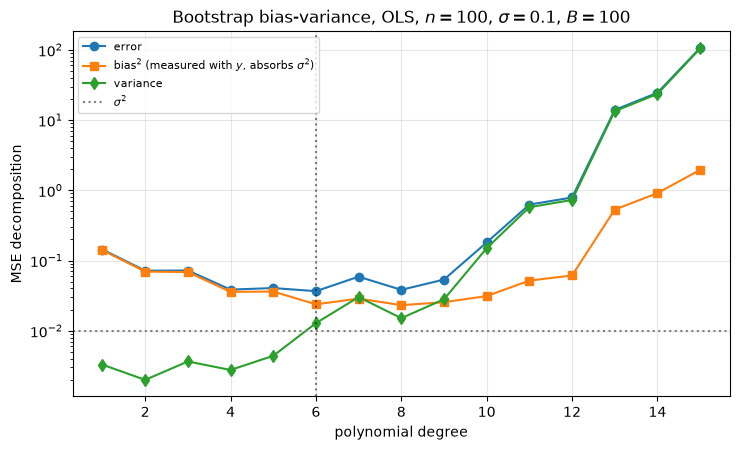

In [655]:
error, bias2, variance = bias_variance_sweep(n=100, sigma=0.1)   # degrees 1..15, 100 bootstrap samples

print("degree    error     bias^2    variance")
for d in [1, 2, 4, 6, 8, 10, 12, 14, 15]:
    i = d - 1
    print(f"{d:6d}  {error[i]:8.4f}  {bias2[i]:8.4f}  {variance[i]:10.4f}")
best_bv = degrees[np.argmin(error)]
print(f"\nlowest bootstrap error at degree {best_bv}: {error.min():.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(degrees, error, "o-", label="error")
ax.plot(degrees, bias2, "s-", label=r"bias$^2$ (measured with $y$, absorbs $\sigma^2$)")
ax.plot(degrees, variance, "d-", label="variance")
ax.axhline(0.1**2, color="gray", ls=":", label=r"$\sigma^2$")
ax.axvline(best_bv, color="k", ls=":", alpha=0.5)
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.set_title(r"Bootstrap bias-variance, OLS, $n=100$, $\sigma=0.1$, $B=100$")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### c.5 Dependence on the number of data points
**Source:** `week36tuesday.ipynb`, Case 1, Step 2 ("vary the data size", there $n$ = 40, 100, 400).
**Modification:** our functions, Runge data, and $n$ = 40, 100, 400, 1000.
> **LLM note:** Written with Claude (Level 4), adapted from `week36tuesday.ipynb` Case 1.

   n   best degree   error there   variance there   variance at degree 15
   40          6         0.0269         0.00451       1.43e+08
  100          6         0.0366         0.01283       104
  400         14         0.0107         0.00065       0.000701
 1000         14         0.0109         0.00026       0.000284


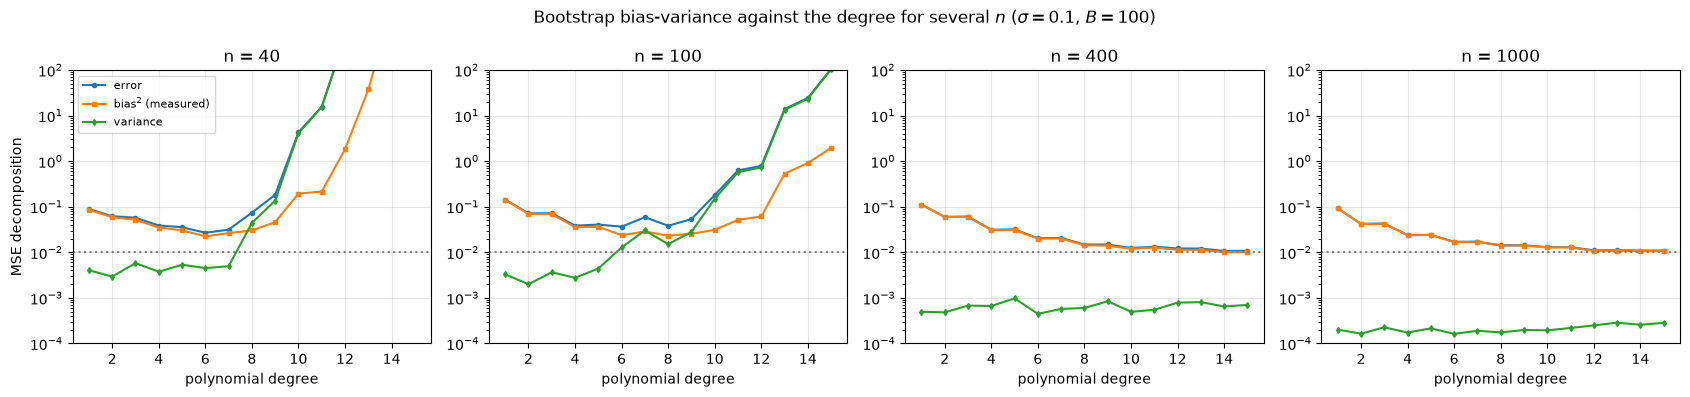

In [656]:
n_values = [40, 100, 400, 1000]
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
print("   n   best degree   error there   variance there   variance at degree 15")
for ax, n_c in zip(axes, n_values):
    err_n, b2_n, var_n = bias_variance_sweep(n=n_c, sigma=0.1)
    ax.plot(degrees, err_n, "o-", ms=3, label="error")
    ax.plot(degrees, b2_n, "s-", ms=3, label=r"bias$^2$ (measured)")
    ax.plot(degrees, var_n, "d-", ms=3, label="variance")
    ax.axhline(0.1**2, color="gray", ls=":")
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 1e2)                  # same range in every panel; for small n the curves leave the plot at high degree
    ax.set_title(f"n = {n_c}")
    ax.set_xlabel("polynomial degree")
    ax.grid(alpha=0.3)
    b = np.argmin(err_n)
    print(f"{n_c:5d}   {degrees[b]:8d}      {err_n[b]:9.4f}      {var_n[b]:10.5f}       {var_n[-1]:.3g}")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(fontsize=8)
fig.suptitle(r"Bootstrap bias-variance against the degree for several $n$ ($\sigma=0.1$, $B=100$)")
plt.tight_layout()
plt.show()

#### c.6 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions (text Level 3 if used
> as it is). Rewrite in your own words for the report, and check every number against your own run.
> **[own]** marks reasoning that is not taken from the course material; **[own check, not in the notebook]**
> marks numbers from additional checks that the notebook does not print.

1. **Training and test error against complexity (c.2).** For every $n$ the training MSE decreases
   monotonically with the degree (lecture notes Section 2.9). With more data, overfitting starts at a higher
   degree and is weaker when it comes: $n = 40$ is best at degree 6 (test MSE 0.022), and beyond that its
   training MSE falls far below $\sigma^2$ (0.0025 at degree 25) while the test MSE rises, i.e. the model fits the
   noise; $n = 100$ is best at degree 8 (0.019) and rises steeply beyond degree 16; for $n = 400$ and 1000 the
   training and test errors stay together near $\sigma^2$ up to degree 25 (best at degree 15 and 17, both 0.010).
   Left of the minimum, training and test errors are close and both high (high bias, low variance); right of it
   they separate (low bias, high variance). The curves are jagged because each rests on one data set.

2. **What the bootstrap does (c.3).** The decomposition of Eq. (2.52) is an average over many training sets, but
   we have only one. The bootstrap creates $B = 100$ new training sets by drawing the 80 training points with
   replacement (Section 2.11), fits a polynomial to each, and lets all 100 models predict the same 20 test points.
   The spread of the 100 predictions estimates the variance; the distance between their average and the test data
   estimates the bias$^2$, which therefore contains $\sigma^2$ (c.1); and the error equals bias$^2$ + variance.
   Each resample contains on average only about 63 % of the distinct points, Eq. (3.97).

3. **Bias and variance against the degree (c.4).** At low degree the variance is small (0.002–0.004): the 100
   models barely differ, because a low-degree polynomial is too stiff to follow the noise. The error is almost all
   bias, which falls from 0.14 (degree 1) to 0.036 (degree 4); the steps (degree 2 ≈ 3, 4 ≈ 5) come from the
   symmetry of Runge's function (part a). Around degree 6 the variance (0.013) has become comparable to the bias
   and the bootstrap error is lowest (0.037); the minimum is broad (degrees 4–8 between 0.037 and 0.039).
   Beyond degree 9 the variance grows rapidly (0.15 at degree 10, 0.73 at 12, 104 at 15) and the error follows
   it. **The rising variance is overfitting**: each high-degree model follows the noise of its own resample
   (Section 2.10).

4. **Why the measured bias$^2$ also rises at high degree [own].** In theory the bias should keep falling with the
   degree, because a higher-degree polynomial can do everything a lower one can (Section 2.10). It rises here
   (to about 2 at degree 15) because of how it is estimated. At high degree a few of the 100 bootstrap models
   explode, and these few predictions drag the *average* prediction away from where most models are, so the
   distance between the average and the data, the measured bias$^2$, grows too. **[own check, not in the
   notebook]** At degree 4 the 100 predictions at the worst test point lie between $-0.04$ and $0.56$, with mean
   0.18 and median 0.17, and none of the 2000 predictions is off by more than 1; at degree 14 they range from
   $-122$ to $+61$, with mean $-3.38$ against median $-0.30$, and 118 of 2000 predictions are off by more than 1.
   The same exploding fits inflate the variance (the spread) far more than the bias (the shift of the average):
   104 against about 2 at degree 15.

5. **Why only high-degree fits explode [own].** Two reasons. (i) *Weak directions.* The noise along singular
   mode $i$ is amplified as $\sigma^2/\sigma_i^2$ (Section 3.7, Eq. (3.42); part b). A low-degree design has no small
   singular values, a high-degree design has several: **[own check, not in the notebook]** in one resample the
   smallest $\sigma_i^2$ is about 3 at degree 4 and about $10^{-8}$ at degree 14. (ii) *Gaps and edges.* Each resample
   contains only about 51 of the 80 distinct points (Eq. (3.97)), so it leaves gaps; a degree-14 polynomial can
   swing wildly in a gap or near the edges (Runge's phenomenon, part a), a degree-4 polynomial cannot. Which models
   explode depends on which points their resample missed.

6. **Why the singular modes get weaker with the degree [own].** A small singular value means that some
   combination of the powers with coefficients of normal size is almost zero at every data point. On $[-1, 1]$ the
   high powers look alike (correlations 0.959 for $x^2, x^4$, 0.992 for $x^6, x^8$, 0.998 for $x^{12}, x^{14}$
   **[own check, not in the notebook]**), and with more columns there are more ways to combine them so that they
   cancel. The Chebyshev polynomial $T_8(x) = 128x^8 - 256x^6 + 160x^4 - 32x^2 + 1$ is an example: coefficients in
   the hundreds, values never beyond $\pm1$ on $[-1, 1]$. The smallest $\sigma_i^2$ of our standardised training matrix
   falls exponentially with the degree: 75, 2.9, 0.12, $4.4\cdot10^{-3}$, $1.8\cdot10^{-4}$, $4.4\cdot10^{-6}$ and
   $1.8\cdot10^{-8}$ at degree 2, 4, 6, 8, 10, 12, 15 **[own check, not in the notebook]**; this is the
   exponential growth of the condition number of polynomial design matrices (lecture notes Section 1.12,
   Fig. 1.2). Standardising does not help, since it changes the sizes of the columns, not their shapes (part a,
   a.11).

7. **Dependence on the number of data points (c.5).** The best degree moves up with $n$ (6, 6, 14, 14 for
   $n$ = 40, 100, 400, 1000), and the lowest error approaches $\sigma^2$ (0.027, 0.037, 0.011, 0.011). The variance
   shrinks with $n$ at every degree: at degree 15 it is $1.4\cdot10^8$ for $n = 40$ and 104 for $n = 100$, but
   $7\cdot10^{-4}$ and $3\cdot10^{-4}$ for $n$ = 400 and 1000, roughly in proportion to $1/n$ for the two large samples
   [own reading]. More data postpone the variance explosion, so a richer model becomes affordable, while the bias
   at low degree is the same for every $n$, since it is a property of the model family (`week36tuesday` Case 1,
   Step 2; Section 2.10). For large $n$ the measured bias$^2$ flattens at about $\sigma^2$: once the true bias is small,
   what remains is the noise it contains (c.1).

8. **Why more data make the weak directions stronger [own].** Each squared singular value is a sum over the data
   points of the squared value of that direction's polynomial, $\sigma_i^2 = \sum_k p_i(x_k)^2$. Every new point adds a
   non-negative term, and more points also leave fewer gaps in which a polynomial can be large without being
   noticed. **[own check, not in the notebook]** At degree 15 the smallest $\sigma_i^2$ grows from $2.6\cdot10^{-10}$
   (32 training points) to $1.8\cdot10^{-8}$ (80), $2.1\cdot10^{-7}$ (320) and $4.3\cdot10^{-7}$ (800), so the noise
   amplification $\sigma^2/\sigma_i^2$ drops from about $4\cdot10^7$ to $2\cdot10^4$. Per training point, the smallest
   $\sigma_i^2$ rises by a factor of about 80 from 32 to 320 points (the gaps close) and is then roughly constant.

9. **Real effect, bootstrap exaggeration, or luck?** The rise of the error at high degree is **real overfitting**:
   cross-validation (part d) and the Fig. 2.11 analogue (c.2) show it too, and more data remove it (c.5). Its
   **size is exaggerated by the bootstrap**, because each resample holds only about 63 % of the distinct points
   (Eq. (3.97); Section 3.14): at degree 15 the bootstrap error is about 100, the cross-validated error 0.025–0.053
   (part d). The **exact values and the small bumps** (for example at degree 7) depend on the particular data set;
   **[own check, not in the notebook]** our training set has a somewhat larger gap between neighbouring $x$ values
   than is typical for 80 random points (0.18 against about 0.12), which the resamples inherit.

10. **The measured bias absorbs $\sigma^2$ (c.1, c.4, c.5).** Because the bias is computed with $y$ instead of $f$, the
    error equals measured bias$^2$ + variance without a separate $\sigma^2$ term (Section 2.10); the measured bias$^2$
    never goes much below $\sigma^2$ (smallest value 0.023 for $n = 100$).

11. **Caveat.** Each curve rests on one data set, one 80/20 split and $B = 100$ bootstrap samples, so single
    bumps should not be over-interpreted.

### Part d): Cross-validation as a resampling technique

The aim here is to use another widely popular resampling technique, the
so-called cross-validation method (Section 2.12 of the lecture notes and the
Tuesday session of week 36). For Ridge and Lasso, see also Section 3.14 of the
lecture notes.

Use the $k$-fold cross-validation functionality of **Scikit-Learn** (`KFold`
together with `cross_val_score`, or `cross_validate`) and evaluate again the
MSE function resulting from the test folds, for the OLS analysis of parts a)
and c) as a function of the polynomial degree, and for Ridge regression as a
function of both the polynomial degree and $\lambda$. Try $k=5$ and $k=10$.
Optionally, you can also write your own $k$-fold cross-validation code and
check that it reproduces the Scikit-Learn results when the two use the same
fold assignment (the Tuesday session of week 36 shows how).

Compare the MSE you get from cross-validation with the one you got
from your **bootstrap** code in part c). Do the two methods point to the same
model complexity? Comment and interpret your results. Make sure that any scaling
or other preprocessing that learns from the data is performed *inside* the
cross-validation loop (fitted on the training folds only), and explain why this
matters.

## Part d): Cross-validation as a resampling technique — code

**Sources for this part (course material, cited in the bibliography):**

| Piece | Course source | Status |
|---|---|---|
| $k$-fold cross-validation: shuffle, split into $k$ folds, each fold held out once, average the scores | lecture notes Section 2.12 | used |
| `make_pipeline(PolynomialFeatures, StandardScaler, Ridge)` with `KFold(shuffle=True)` and `cross_val_score(..., scoring="neg_mean_squared_error")` | `week36tuesday.ipynb` Case 2, Steps 2–3; lecture notes Section 2.12 (code) | adapted |
| cross-validation over the polynomial degree | `week36tuesday.ipynb` Case 2, Step 4 | adapted |
| standardisation inside each fold, and why | lecture notes Section 3.14 ("Standardisation inside the loop"); Section 3.13; `week36tuesday.ipynb` Case 2, Step 2 | explained in d.1 |
| bootstrap against cross-validation (63.2 % distinct points, Eq. (3.97)) | lecture notes Section 3.14 ("The bootstrap as an alternative") | used in the discussion |

We cross-validate on the whole data set of parts a)–c) ($n=100$, $\sigma=0.1$), as in `week36tuesday.ipynb`,
Case 2, Step 4. $\lambda$ has the same meaning as in part b): Scikit-Learn's `Ridge(alpha=lambda)` minimises
$\|\boldsymbol y-\boldsymbol X\boldsymbol\theta\|_2^2+\lambda\|\boldsymbol\theta\|_2^2$, Eq. (3.44).

> **LLM note:** All code cells of part d) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course material listed above as the base. The explanation in d.1 was drafted
> with Claude (text Level 3 if used as it is in the report).

#### d.1 Pipelines, and why the preprocessing must be done inside the cross-validation loop
**Source:** the pipelines and the call to `cross_val_score` follow `week36tuesday.ipynb`, Case 2, Steps 2–4,
and the code in Section 2.12 of the lecture notes. **Modifications:** `PolynomialFeatures(include_bias=False)`
and `fit_intercept=True`, so that, as in parts a)–b), the columns are $x,\dots,x^d$, they are standardised,
and the intercept is fitted separately from the training folds and not penalised (Section 3.13).

**Why the preprocessing must be inside the loop.** A pipeline is refitted as a whole on the $k-1$ training
folds of every split: the `StandardScaler` learns the means and standard deviations from those folds only,
and the held-out fold is transformed with these frozen numbers. The held-out fold then plays the role of
genuinely new data, which is what the cross-validation error is supposed to estimate. If instead the scaler
were fitted once on the full data set, every training fold would "see" the mean and variance of its own
held-out fold: information from the test fold would leak into the fit, and the cross-validation error would
be biased towards being optimistic (lecture notes Section 3.14, "Standardisation inside the loop";
`week36tuesday.ipynb` Case 2, Step 2). For OLS with a free intercept the leak happens to change nothing,
because OLS predictions do not depend on how the columns are shifted and rescaled (Section 3.13; check (4)
in a.11). For Ridge it does matter, because the penalty is not invariant under rescaling, so leaked statistics
change the fitted model (Section 3.13). For scaling alone the leak is small; it becomes large for any
preprocessing that uses the targets, such as selecting features by their correlation with $y$ on the full
data set (Section 3.14). The rule is that nothing computed from the held-out fold may enter the fit.
> **LLM note:** Written with Claude (Level 4), adapted from `week36tuesday.ipynb` Case 2.

In [657]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold, cross_val_score
# LinearRegression and Ridge were imported in a.1 and b.1


def make_ols_pipeline(degree):
    """
    Polynomial features x..x^degree -> standardisation -> OLS with a free intercept.
    The whole pipeline is refitted on the training folds of every split.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted the pipeline of week36tuesday.ipynb (Case 2) to OLS with our conventions.
    """
    return make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),   # columns x, ..., x^degree
                         StandardScaler(),                                         # learns mean/std from the training folds
                         LinearRegression(fit_intercept=True))                     # intercept from the training folds


def make_ridge_pipeline(degree, lam):
    """
    Polynomial features x..x^degree -> standardisation -> Ridge with penalty lam (unpenalised intercept).

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted the pipeline of week36tuesday.ipynb (Case 2, Step 2).
    """
    return make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                         StandardScaler(),
                         Ridge(alpha=lam, fit_intercept=True))                    # alpha = lambda of part b), Eq. (3.44)


def cv_mse(pipe, x, y, k):
    """
    Mean squared error over the k held-out folds, with KFold(shuffle=True) and cross_val_score.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Wrapped the KFold + cross_val_score call of week36tuesday.ipynb (Case 2) in a function.
    """
    kfold = KFold(n_splits=k, shuffle=True, random_state=SEED)   # shuffle, then k folds (Section 2.12)
    scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold,
                             scoring="neg_mean_squared_error")    # one score per held-out fold, as -MSE
    return np.mean(-scores)                                       # average MSE over the k folds

#### d.2 OLS: cross-validated MSE against the degree, $k = 5$ and $k = 10$
**Source:** `week36tuesday.ipynb`, Case 2, Step 4 (cross-validation over the degree) and Step 3 (vary $k$).
**Modifications:** our data set of parts a)–c) and degrees 1–15.
> **LLM note:** Written with Claude (Level 4), adapted from `week36tuesday.ipynb` Case 2.

k =  5: lowest CV MSE at degree 11 (0.0211)
k = 10: lowest CV MSE at degree 11 (0.0202)


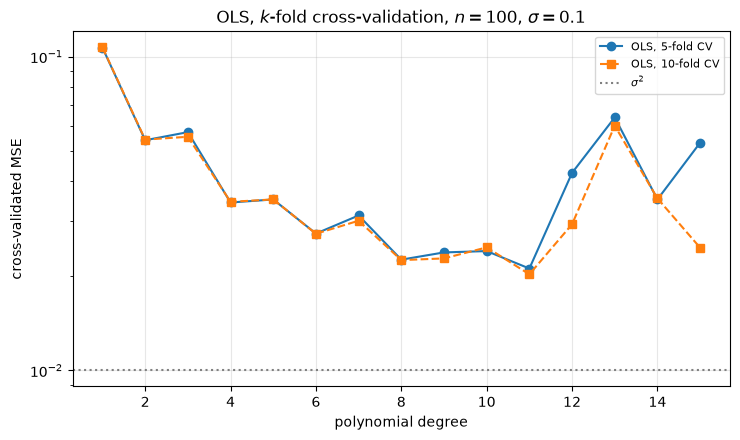

In [658]:
cv_ols = {}                                             # cross-validated MSE for every degree, per k
for k in [5, 10]:
    cv_ols[k] = np.array([cv_mse(make_ols_pipeline(d), x, y, k) for d in degrees])
    b = np.argmin(cv_ols[k])
    print(f"k = {k:2d}: lowest CV MSE at degree {degrees[b]} ({cv_ols[k][b]:.4f})")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for k, style in zip([5, 10], ["o-", "s--"]):
    ax.plot(degrees, cv_ols[k], style, label=f"OLS, {k}-fold CV")
ax.axhline(0.1**2, color="gray", ls=":", label=r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("cross-validated MSE")
ax.set_title(r"OLS, $k$-fold cross-validation, $n=100$, $\sigma=0.1$")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### d.3 Ridge: cross-validated MSE against the degree and $\lambda$, $k = 5$ and $k = 10$
**Source:** `week36tuesday.ipynb`, Case 2, Steps 2–3 (Ridge pipeline, $\lambda$ grid, vary $k$).
**Modifications:** both the degree (1–15) and $\lambda$ are varied, on the same $\lambda$ grid as in b.4
($10^{-8}$ to $10^3$), and the result is shown as a heatmap like b.4.
> **LLM note:** Written with Claude (Level 4), adapted from `week36tuesday.ipynb` Case 2.

k =  5: lowest CV MSE at lambda = 3.2e-05, degree = 12 (0.0209);  best OLS: degree 11 (0.0211)
k = 10: lowest CV MSE at lambda = 1.0e-05, degree = 12 (0.0192);  best OLS: degree 11 (0.0202)


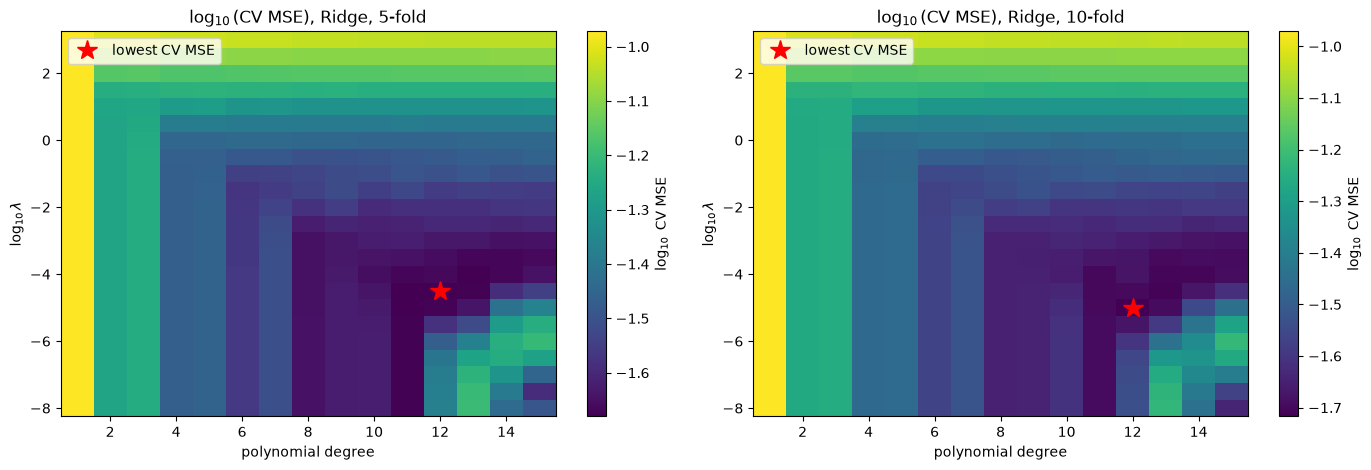

In [659]:
lambdas_cv = np.logspace(-8, 3, 23)                     # same grid as in b.4, two points per decade
cv_ridge = {}                                           # cv_ridge[k][i, j]: lambda number i, degree j + 1
for k in [5, 10]:
    cv_ridge[k] = np.array([[cv_mse(make_ridge_pipeline(d, lam), x, y, k) for d in degrees]
                            for lam in lambdas_cv])
    i, j = np.unravel_index(np.argmin(cv_ridge[k]), cv_ridge[k].shape)   # row and column of the minimum
    print(f"k = {k:2d}: lowest CV MSE at lambda = {lambdas_cv[i]:.1e}, degree = {degrees[j]} "
          f"({cv_ridge[k][i, j]:.4f});  best OLS: degree {degrees[np.argmin(cv_ols[k])]} "
          f"({cv_ols[k].min():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, k in zip(axes, [5, 10]):
    im = ax.imshow(np.log10(cv_ridge[k]), origin="lower", aspect="auto", cmap="viridis",
                   extent=[degrees[0] - 0.5, degrees[-1] + 0.5,
                           np.log10(lambdas_cv[0]) - 0.25, np.log10(lambdas_cv[-1]) + 0.25])
    i, j = np.unravel_index(np.argmin(cv_ridge[k]), cv_ridge[k].shape)
    ax.plot(degrees[j], np.log10(lambdas_cv[i]), "r*", ms=15, label="lowest CV MSE")
    ax.set_xlabel("polynomial degree")
    ax.set_ylabel(r"$\log_{10}\lambda$")
    ax.set_title(rf"$\log_{{10}}$(CV MSE), Ridge, {k}-fold")
    ax.legend(loc="upper left")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}$ CV MSE")
plt.tight_layout()
plt.show()

#### d.4 Cross-validation against the bootstrap of part c)
**Source:** the comparison is asked in the project text; the bootstrap error is the variable `error` from c.4
(OLS, $n=100$, $B=100$). The reason why the two estimates differ is discussed in lecture notes Section 3.14
("The bootstrap as an alternative").
> **LLM note:** Written with Claude (Level 4). New code.

bootstrap (c.4): lowest error at degree 6 (0.0366)
 5-fold CV:      lowest error at degree 11 (0.0211)
10-fold CV:      lowest error at degree 11 (0.0202)


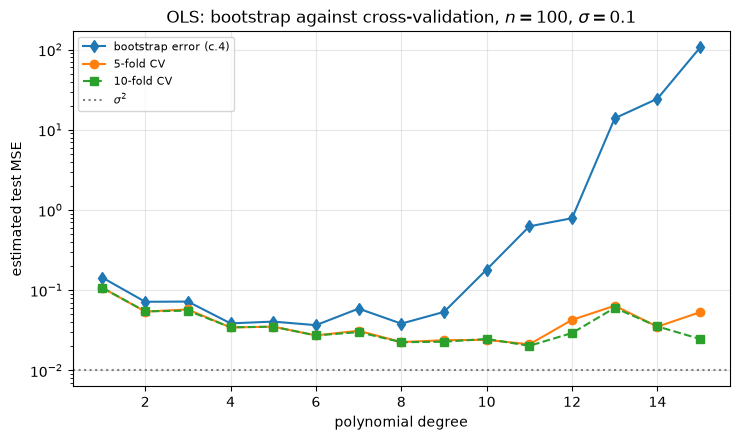

In [660]:
# error: bootstrap estimate of the test error from c.4 (same data set, OLS, degrees 1..15)
print(f"bootstrap (c.4): lowest error at degree {degrees[np.argmin(error)]} ({error.min():.4f})")
for k in [5, 10]:
    print(f"{k:2d}-fold CV:      lowest error at degree {degrees[np.argmin(cv_ols[k])]} ({cv_ols[k].min():.4f})")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(degrees, error, "d-", label="bootstrap error (c.4)")
ax.plot(degrees, cv_ols[5], "o-", label="5-fold CV")
ax.plot(degrees, cv_ols[10], "s--", label="10-fold CV")
ax.axhline(0.1**2, color="gray", ls=":", label=r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("estimated test MSE")
ax.set_title(r"OLS: bootstrap against cross-validation, $n=100$, $\sigma=0.1$")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### d.5 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions (text Level 3 if used
> as it is). Rewrite in your own words for the report, and check every number against your own run.
> **[own]** marks reasoning that is not taken from the course material.

1. **What one cross-validated value is (d.1).** `KFold` shuffles the 100 points and cuts them into $k$ folds
   (20 points each for $k = 5$, 10 for $k = 10$). For each fold in turn the pipeline is trained on the other
   $k-1$ folds and the MSE is computed on the held-out fold; the plotted CV MSE is the average of these $k$ fold
   MSEs (Section 2.12). Every point is used for testing exactly once and for training $k-1$ times. With equal
   fold sizes the average of the fold MSEs equals the MSE of all 100 held-out predictions taken together [own].
   `cross_val_score` reports the *negative* MSE (Scikit-Learn's convention that a higher score is better), so the
   sign is flipped back. The shuffle matters here because `make_data` returns $x$ sorted: without it, each fold
   would be one contiguous piece of $[-1, 1]$ and the model would have to extrapolate into it [own]. The fixed
   `random_state` gives every degree and every $\lambda$ exactly the same folds, so differences between models are
   not caused by different fold assignments.

2. **Preprocessing inside the loop (d.1).** The `StandardScaler` in the pipeline subtracts the mean of each column
   and divides by its standard deviation, the same standardisation as our `scale_train_test` of part a). It
   *learns* the means and standard deviations (`fit`) and then *applies* them (`transform`). Because the whole
   pipeline is refitted on the training folds of every split, the scaler learns its numbers from the training
   folds only, and the held-out fold is transformed with those numbers, never with its own, just as genuinely new
   data would be (Section 3.14; `week36tuesday` Case 2, Step 2). Fitting it on the full data set would let
   information from the test fold leak into the fit and make the CV error optimistic; for OLS the leak changes
   nothing (Section 3.13; a.11), for Ridge and Lasso it does.

3. **OLS, and the choice of $k$ (d.2).** 5-fold and 10-fold CV give practically the same curve up to degree 11,
   and both select degree 11 (CV MSE 0.021 and 0.020). The curve is broad and flat between degree 8 and 11
   (0.021–0.025), so the exact degree is not sharply determined. Beyond degree 11 the curves separate: 0.043
   against 0.029 at degree 12, both about 0.06 at degree 13, and 0.053 against 0.025 at degree 15, a factor of 2.
   With $k = 10$ each model is trained on 90 % of the data instead of 80 % (Section 3.14). Low-degree fits barely
   care about the 10 extra points, high-degree fits are very sensitive to how many points they get, and at high
   degree a single fold with a wild fit at an edge point can dominate the average [own reading]. The choice of $k$
   therefore does not change the selected model, only how bad the high-degree models look, in line with
   $k = 5$–10 as the usual compromise (Section 2.12). The lowest CV MSE lies above $\sigma^2 = 0.01$, as it must.

4. **Ridge (d.3).** In the heatmaps, the degree-1 column is poor for every $\lambda$ (0.106); for $\lambda \gtrsim 1$ the
   penalty dominates and the model underfits at every degree (at least 0.09 for $\lambda = 10^3$); at degree 12–15
   with very small $\lambda$ the model is practically OLS and overfits. The low-error region is a broad, diagonal
   valley: the higher the degree, the larger the $\lambda$ needed to keep the variance down ("two dials",
   `week35tuesday` Case 4). The columns come in pairs (2–3, 4–5, 6–7), because odd powers add almost nothing to
   an even function (part a). The minimum is at degree 12 for both $k$, with $\lambda = 3\cdot10^{-5}$ ($k = 5$,
   0.021) and $\lambda = 10^{-5}$ ($k = 10$, 0.019); 10-fold is slightly darker overall because its models are
   trained on more data. This is only marginally below the best OLS (0.021 and 0.020), less than the standard
   error of the CV estimate, about 0.003 (part i). The value of Ridge here is that it **makes high degrees safe**:
   at degree 15 the best Ridge ($\lambda = 3\cdot10^{-4}$) gives 0.022 and 0.020, against 0.053 and 0.025 for OLS.
   Because the valley is broad, the exact choice of degree and $\lambda$ is not critical. This is the same picture as
   in part b), but now obtained without using a test set.

5. **Cross-validation against the bootstrap (d.4).** At low degree the two methods agree roughly (degree 4:
   bootstrap 0.039, CV 0.034; degree 6: 0.037 against 0.027), with the bootstrap somewhat higher, and both reject
   the low degrees (high bias). At high degree they diverge completely: the bootstrap error explodes (0.18 at
   degree 10, 14 at degree 13, 106 at degree 15), while the CV error stays between 0.02 and 0.06. The two methods
   therefore **do not point to the same complexity**: the bootstrap selects degree 6, cross-validation degree 11.

6. **Why they differ, and which to trust for model selection.** Each bootstrap model is fitted to a resample that
   contains on average only 63.2 % of the distinct training points (Eq. (3.97)), so the bootstrap estimates the
   error of a model trained on a substantially smaller sample and is pessimistic: it behaves like $K$-fold CV with
   $K \approx 2.7$, whereas 5- and 10-fold CV train on 80 % and 90 % of the data (Section 3.14, "The bootstrap as an
   alternative"). The effect is largest at high degree, where the fits are most sensitive to the number of points
   (part c). In addition, the bootstrap error of c.4 rests on one 20-point test set, while cross-validation tests
   every one of the 100 points once (Section 2.12). For choosing the model complexity, cross-validation is
   therefore the more reliable estimate and the standard tool (Section 3.14). The bootstrap answers a different
   question: it splits the error into bias$^2$ and variance, which cross-validation cannot do, and that is what
   showed in part c) *why* high degrees fail.

7. **Caveat.** One data set; the CV error is itself an estimate that depends on the fold assignment (standard
   error about 0.002–0.003 at the best models, part i), so differences of a few per cent, for example Ridge
   against OLS, are not meaningful.

### Part e): Writing your own gradient descent code, with analytical gradients and automatic differentiation

Replace now the analytical expressions for the optimal parameters
$\boldsymbol{\theta}$ of OLS and Ridge regression with your own gradient descent
code. In this part we focus only on the simplest gradient descent approach with
a fixed learning rate $\eta$ (see the lectures and exercises of week 37 and
Sections 4.3–4.5 of the lecture notes),

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \eta\,\nabla_{\boldsymbol{\theta}}C(\boldsymbol{\theta}_k).
$$

Compute the gradient of the cost function in two independent ways:

1. **Analytically**, from the expressions you derived in the week-35 exercises,
   that is $\nabla_{\boldsymbol{\theta}}C = \frac{2}{n}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})$
   for OLS and the corresponding expression with the extra term
   $2\lambda\boldsymbol{\theta}$ for Ridge (check your normalization
   conventions).
2. By **automatic differentiation** (Section 4.14 of the lecture notes), using
   for example **JAX** (`jax.grad`) or **Autograd**. Write the cost function as
   an ordinary Python function of $\boldsymbol{\theta}$ and let the library
   produce its gradient.

Verify that the two gradients agree to machine precision for OLS and Ridge, and
use both in your gradient descent code. Discuss briefly why automatic
differentiation is neither symbolic nor numerical (finite-difference)
differentiation, and what its cost is relative to one evaluation of the cost
function.

Study and compare your results from parts a) and b) with your gradient descent
approach: do you converge to the closed-form solutions, and how many iterations
does it take? Discuss in particular the role of the learning rate, and relate
the largest learning rate for which the iteration converges to the largest
eigenvalue of the Hessian matrix $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$
(plus $2\lambda\boldsymbol{I}$ for Ridge), see Section 4.5 of the lecture notes.

The cell below shows the minimal version of the automatic-differentiation check
with JAX (install with `pip install jax jaxlib`). Note the 64-bit switch: JAX
defaults to 32-bit floats, which would hide the "machine precision" agreement.

In [661]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())

OLS   max |AD - analytic| = 5.551115123125783e-17
Ridge max |AD - analytic| = 5.551115123125783e-17
eta_max for OLS  = 0.8937721839600539


## Part e): Own gradient descent, with analytical gradients and automatic differentiation — code

The cell above is the course's starter cell, unchanged. It checks the automatic-differentiation gradients against
the analytical ones on the raw design matrix of the starter set-up (all 100 points, column of ones, no scaling)
and prints $\eta_{\max}$ for OLS. The cells below do the rest of part e).

**Where each piece comes from** (course material is cited in the bibliography):

| Cell | Piece | Source | Status |
|---|---|---|---|
| starter cell above | JAX cost functions, `jax.grad`, 64-bit switch, gradient check, $\eta_{\max} = 2/\lambda_{\max}$ | `Project1.ipynb` (part e); lecture notes Eqs. (4.12)–(4.14), (4.16)–(4.17) | copied, unchanged |
| e.1 | data for gradient descent (as in parts a–b), analytical gradients as functions, Hessian eigenvalues | our `polynomial_features`, `scale_train_test`; lecture notes Eqs. (4.13)–(4.14), (4.17); `week37tuesday.ipynb` Case 1, Step 2 (`gradient`, `hessian_eigs`) | adapted |
| e.2 | symbolic, numerical and automatic differentiation; cost of reverse mode | lecture notes Section 4.14.1 and Proposition 4.2 | text |
| e.3 | `gradient_descent` (Eq. (4.15), stop at $\|\boldsymbol\theta_k-\hat{\boldsymbol\theta}\| < 10^{-6}$) | `week37tuesday.ipynb` Case 1, Steps 2 and 5 (`gradient_descent`, `iterations_to_accuracy`) | adapted |
| e.3 | closed forms with the factor $n$ | lecture notes Section 4.4.1; `week37tuesday.ipynb` Case 1, Step 1; our `ols_svd`, `ridge_svd` | adapted |
| e.3 | runs with the analytical and the JAX gradient | asked in the project text | new code |
| e.4 | convergence curves for several $\eta$; iterations against $\eta$ | `week37tuesday.ipynb` Case 1, Step 5 (`fig_gd_convergence`, `fig_gamma_scan`); lecture notes Section 4.5 | adapted |
| e.5 | gradient descent for every degree of parts a)–b) | asked in the project text ("compare with parts a) and b)"); lecture notes Section 4.5, Eqs. (4.26)–(4.27) | new code |

**Conventions (the "check your normalization conventions" of the project text).** The starter cell uses the cost
$C(\boldsymbol\theta) = \frac1n\|\boldsymbol y - \boldsymbol X\boldsymbol\theta\|_2^2 + \lambda\|\boldsymbol\theta\|_2^2$ (Eq. (4.16)), with gradient
$\nabla C = \frac2n\boldsymbol X^T(\boldsymbol X\boldsymbol\theta - \boldsymbol y) + 2\lambda\boldsymbol\theta$ and Hessian
$\boldsymbol H = \frac2n\boldsymbol X^T\boldsymbol X + 2\lambda\boldsymbol I$ (Eq. (4.17)); $\lambda=0$ is OLS. Its minimum is
$(\boldsymbol X^T\boldsymbol X + n\lambda\boldsymbol I)^{-1}\boldsymbol X^T\boldsymbol y$ (Section 4.4.1), whereas part b) used Eq. (3.44) without
the $1/n$. **A penalty $\lambda$ of this part therefore equals $n_{\rm train}\lambda$ in part b)**, and the closed-form
reference is `ridge_svd(X, y, n_train * lam)`.

> **LLM note:** All code cells below were written with Claude Opus 5.5 (claude.ai, September 2026) at Level 4,
> using the course material listed above as the base. The text in e.2 was drafted with Claude (text Level 3 if
> used as it is in the report).

#### e.1 Set-up for gradient descent: the data of parts a)–b) and the analytical gradients as functions
**Source:** the gradient and Hessian are Eqs. (4.13)–(4.14) and (4.17), written as functions as in `gradient`
and `hessian_eigs` of `week37tuesday.ipynb`, Case 1, Step 2. **Modifications:** to compare with the closed forms
of parts a) and b), gradient descent uses the same data as there: the 80 training points, standardised columns
$x,\dots,x^5$ and centred $y$, so there is no intercept to fit (Section 3.13; `week37tuesday.ipynb` Case 1). The
starter cell computed `grad_ols_analytic` and `grad_ridge_analytic` as numbers at one point; here they are
redefined as functions of $\boldsymbol\theta$, so they can be used in the gradient descent loop. The JAX gradients
`grad_ols_ad` and `grad_ridge_ad` of the starter cell are functions of `(theta, X, y)` already and are used as
they are. Standardising also changes the Hessian, and with it $\lambda_{\max}$ and $\eta_{\max}$ (Section 4.5), so
both are printed.
> **LLM note:** Written with Claude (Level 4), adapted from `week37tuesday.ipynb` Case 1, Step 2.

In [662]:
H_raw = H                                   # Hessian of the starter cell (raw design matrix), kept for comparison

# the data of parts a)-b): 80 training points, standardised columns x..x^degree, centred y
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=SEED)
X, _, y_c, _ = scale_train_test(polynomial_features(x_train, degree),
                                polynomial_features(x_test, degree), y_train)
n = len(y_c)                                # 80 training points


def grad_ols_analytic(theta, X, y):
    """Eq. (4.13), as a function of theta (replaces the starter's number of the same name)."""
    return 2.0 / len(y) * X.T @ (X @ theta - y)


def grad_ridge_analytic(theta, X, y, lmbda):
    """Eq. (4.17), as a function of theta (replaces the starter's number of the same name)."""
    return grad_ols_analytic(theta, X, y) + 2.0 * lmbda * theta


eig_raw = np.linalg.eigvalsh(H_raw)                          # starter set-up (raw design, all points)
eig_ols = np.linalg.eigvalsh(2.0 / n * X.T @ X)              # our set-up, OLS, Eq. (4.14)
eig_ridge = eig_ols + 2.0 * lmbda                            # Ridge: every eigenvalue shifted by 2 lambda, Eq. (4.17)
for name, e in [("starter set-up, OLS", eig_raw), ("our set-up, OLS    ", eig_ols), ("our set-up, Ridge  ", eig_ridge)]:
    print(f"{name}: lambda_max = {e.max():.4f}, lambda_min = {e.min():.2e}, "
          f"kappa = {e.max() / e.min():.0f}, eta_max = 2/lambda_max = {2 / e.max():.4f}")

starter set-up, OLS: lambda_max = 2.2377, lambda_min = 1.09e-03, kappa = 2050, eta_max = 2/lambda_max = 0.8938
our set-up, OLS    : lambda_max = 5.5621, lambda_min = 1.13e-02, kappa = 491, eta_max = 2/lambda_max = 0.3596
our set-up, Ridge  : lambda_max = 5.5821, lambda_min = 3.13e-02, kappa = 178, eta_max = 2/lambda_max = 0.3583


#### e.2 Why automatic differentiation is neither symbolic nor numerical differentiation, and its cost
> **LLM note:** Drafted with Claude (text Level 3 if used as it is), following lecture notes Section 4.14.1
> and Proposition 4.2.

- **Symbolic differentiation** manipulates formulas: it takes the expression for $f$ and returns the expression
  for $f'$, as a computer-algebra system does. It is exact, but it needs the program to be a single closed-form
  expression and suffers from *expression swell*: the derivative formula grows much faster than the original
  and loses the sharing of intermediate results (Section 4.14.1).
- **Numerical (finite-difference) differentiation** replaces the derivative by a difference quotient such as
  $[f(x+h)-f(x-h)]/2h$, Eq. (4.73). It has a truncation error that shrinks with $h$ and a rounding error that
  grows as $h$ shrinks, so at best it gives about $10^{-11}$ in double precision, Eq. (4.76), and a gradient in
  $p$ variables needs $2p$ evaluations of $f$ (Section 4.14.1).
- **Automatic differentiation** does neither. It applies the exact derivative rules of the elementary
  operations through the chain rule, along the sequence of operations the program actually executes. It
  therefore returns the *numerical value* of the derivative at a point, not a formula (no expression swell),
  and it has no step $h$ and no truncation error: the result is accurate to working precision
  (Section 4.14.1). That is why the two gradients in the starter cell agree to about $10^{-16}$,
  whereas a finite difference could not do better than about $10^{-11}$.
- **Cost.** In reverse mode, which is what `jax.grad` uses for a scalar cost, the value and the complete
  gradient cost at most a small constant times the cost of one evaluation of the cost function, $c \le 4$ and
  in practice 2–3, *independent of the number of parameters $p$* (Proposition 4.2, the cheap gradient
  principle). Finite differences need $2p$ evaluations.

#### e.3 Gradient descent with a fixed learning rate, with both gradients, against the closed forms
**Source:** the loop is Eq. (4.15), as in `gradient_descent` and `iterations_to_accuracy` of
`week37tuesday.ipynb`, Case 1 (Steps 2 and 5): start from $\boldsymbol\theta_0 = \boldsymbol 0$, take steps
$\boldsymbol\theta_{k+1} = \boldsymbol\theta_k - \eta\nabla C(\boldsymbol\theta_k)$, and count the iterations until
$\|\boldsymbol\theta_k - \hat{\boldsymbol\theta}\|_2 < 10^{-6}$, with $\hat{\boldsymbol\theta}$ the closed form.
**Modifications:** the gradient is passed in as a function, so the same loop runs with the analytical gradient
and with the JAX gradient; the closed forms are those of parts a)–b) (`ols_svd`, and `ridge_svd` with $n\lambda$).
The learning rate is the optimal fixed rate $\eta^* = 2/(\lambda_{\max}+\lambda_{\min})$ of Section 4.5, Eq. (4.26).
> **LLM note:** Written with Claude (Level 4), adapted from `week37tuesday.ipynb` Case 1.

In [663]:
def gradient_descent(grad_fn, theta_target, eta, p, acc=1e-6, max_iter=100_000):
    """
    Plain gradient descent, Eq. (4.15), from theta = 0 with a fixed learning rate eta.
    grad_fn(theta) returns the gradient. Stops when ||theta - theta_target|| < acc,
    when the iteration diverges, or after max_iter steps.
    Returns theta, the number of iterations (np.nan if not converged) and the distances per step.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted gradient_descent / iterations_to_accuracy of week37tuesday.ipynb (Case 1);
          the gradient is passed in as a function (analytical or JAX).
    """
    theta = np.zeros(p)                                    # start at the origin, as in week37tuesday
    dist = [np.linalg.norm(theta - theta_target)]          # distance to the closed form, per step
    for k in range(1, max_iter + 1):
        theta = theta - eta * np.asarray(grad_fn(theta))   # Eq. (4.15): one step against the gradient
        dist.append(np.linalg.norm(theta - theta_target))
        if dist[-1] < acc:                                 # close enough to the closed form: converged
            return theta, k, np.array(dist)
        if not np.isfinite(dist[-1]) or dist[-1] > 1e6:    # the iteration has blown up
            return theta, np.nan, np.array(dist)
    return theta, np.nan, np.array(dist)                   # ran out of iterations


p = X.shape[1]
theta_ols_cf = ols_svd(X, y_c)                             # closed-form OLS of part a)
theta_ridge_cf = ridge_svd(X, y_c, n * lmbda)              # closed-form Ridge of part b), lambda_b = n * lambda
eta_star_ols = 2.0 / (eig_ols.max() + eig_ols.min())       # optimal fixed learning rate, Eq. (4.26)
eta_star_ridge = 2.0 / (eig_ridge.max() + eig_ridge.min())

runs = {
    "OLS,   analytic": (lambda th: grad_ols_analytic(th, X, y_c), theta_ols_cf, eta_star_ols),
    "OLS,   JAX     ": (lambda th: grad_ols_ad(th, X, y_c), theta_ols_cf, eta_star_ols),
    "Ridge, analytic": (lambda th: grad_ridge_analytic(th, X, y_c, lmbda), theta_ridge_cf, eta_star_ridge),
    "Ridge, JAX     ": (lambda th: grad_ridge_ad(th, X, y_c, lmbda), theta_ridge_cf, eta_star_ridge),
}
theta_gd = {}
print(f"degree {degree}, lambda = {lmbda} (= {n * lmbda:.1f} in the convention of part b)\n")
print("run               eta      iterations   |theta - closed form|")
for name, (g_fn, target, eta) in runs.items():
    theta_gd[name], its, dist = gradient_descent(g_fn, target, eta, p)
    print(f"{name}   {eta:.4f}   {its:8.0f}       {dist[-1]:.2e}")

print("\nmax |theta(analytic) - theta(JAX)|:  OLS",
      f"{np.max(np.abs(theta_gd['OLS,   analytic'] - theta_gd['OLS,   JAX     '])):.1e},  Ridge",
      f"{np.max(np.abs(theta_gd['Ridge, analytic'] - theta_gd['Ridge, JAX     '])):.1e}")
print(f"condition number kappa = lambda_max / lambda_min:  OLS {eig_ols.max() / eig_ols.min():.0f},  "
      f"Ridge {eig_ridge.max() / eig_ridge.min():.0f}")

degree 5, lambda = 0.01 (= 0.8 in the convention of part b)

run               eta      iterations   |theta - closed form|
OLS,   analytic   0.3588       3057       9.96e-07
OLS,   JAX        0.3588       3057       9.96e-07
Ridge, analytic   0.3563       1019       9.99e-07
Ridge, JAX        0.3563       1019       9.99e-07

max |theta(analytic) - theta(JAX)|:  OLS 2.5e-16,  Ridge 6.9e-17
condition number kappa = lambda_max / lambda_min:  OLS 491,  Ridge 178


#### e.4 The role of the learning rate, and the bound $\eta < 2/\lambda_{\max}$
**Source:** `week37tuesday.ipynb`, Case 1, Step 5 (`fig_gd_convergence` and `fig_gamma_scan`); lecture notes
Section 4.5: along each eigendirection of $\boldsymbol H$ the error is multiplied by $1-\eta\lambda_i$ per step,
Eq. (4.19), so the iteration converges if and only if $\eta < 2/\lambda_{\max}$, Theorem 4.1 and Eq. (4.20); the
fastest fixed rate is $\eta^* = 2/(\lambda_{\max}+\lambda_{\min})$ and the number of iterations grows with
$\kappa = \lambda_{\max}/\lambda_{\min}$, Eq. (4.26). For Ridge every eigenvalue is shifted up by $2\lambda$, Eq. (4.17).
**Modifications:** our degree-5 Runge training data and our `gradient_descent`. *Left:* distance to the closed
form against the iteration for several learning rates (OLS). *Right:* iterations to reach $10^{-6}$ against
$\eta$, for OLS and Ridge; the dotted lines mark $\eta^*$, the dashed lines $2/\lambda_{\max}$. The convergence curves on the left are run for at most 20000 iterations, enough for every learning rate that
converges at a reasonable speed ($\eta^*$ needs about 3000) while keeping the cell fast; the scan on the right and
cell e.5 use the default limit of $10^5$ iterations of `gradient_descent`, because close to the stability bound and at
high degree many more iterations are needed. These limits are our choice; the exercise does not specify them.
> **LLM note:** Written with Claude (Level 4), adapted from `week37tuesday.ipynb` Case 1, Step 5.

OLS, eta = 0.0360 (0.1 eta_max): not converged after 20000 (distance 7.4e-05)
OLS, eta = 0.1798 (0.5 eta_max): 6106 iterations
OLS, eta = 0.3588 (eta*): 3057 iterations
OLS, eta = 0.3236 (0.9 eta_max): 3390 iterations
OLS, eta = 0.3668 (1.02 eta_max): diverges

               OLS: largest eta that converged on the grid = 0.3594, predicted bound 2/lambda_max = 0.3596; fewest iterations 3104 at eta = 0.3533 (eta* = 0.3588)
Ridge, lambda=0.01: largest eta that converged on the grid = 0.3581, predicted bound 2/lambda_max = 0.3583; fewest iterations 1032 at eta = 0.3521 (eta* = 0.3563)


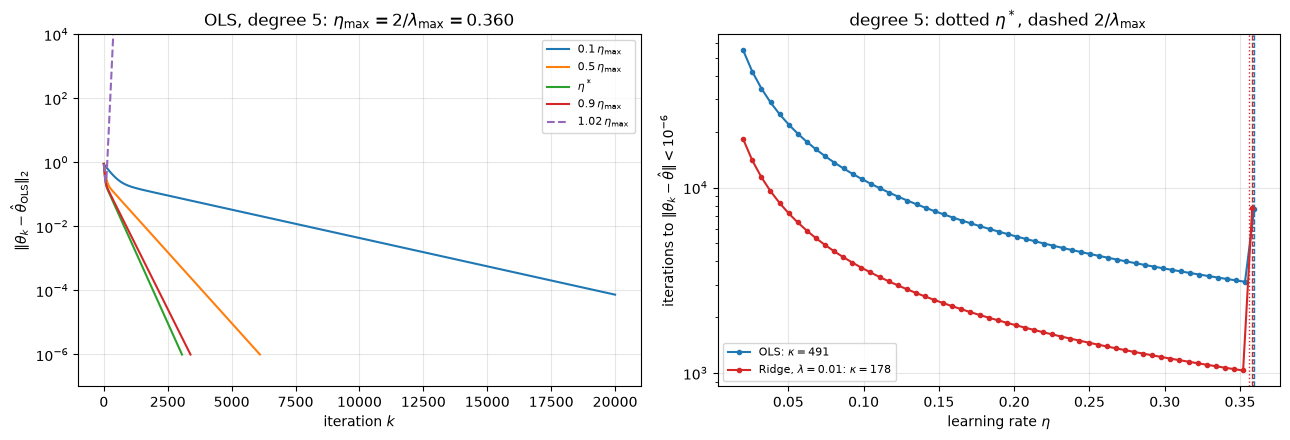

In [664]:
eta_max_ols = 2.0 / eig_ols.max()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: convergence curves for OLS at several learning rates
g_ols = lambda th: grad_ols_analytic(th, X, y_c)
for factor, label, name in [(0.1, r"$0.1\,\eta_{\max}$", "0.1 eta_max"), (0.5, r"$0.5\,\eta_{\max}$", "0.5 eta_max"),
                            (eta_star_ols / eta_max_ols, r"$\eta^*$", "eta*"),
                            (0.9, r"$0.9\,\eta_{\max}$", "0.9 eta_max"), (1.02, r"$1.02\,\eta_{\max}$", "1.02 eta_max")]:
    with np.errstate(all="ignore"):
        _, its, dist = gradient_descent(g_ols, theta_ols_cf, factor * eta_max_ols, p, max_iter=20_000)
    ax1.semilogy(dist, ls="--" if factor > 1 else "-", label=label)
    result = f"{its:.0f} iterations" if np.isfinite(its) else (
        "diverges" if not np.isfinite(dist[-1]) or dist[-1] > 1e6 else f"not converged after 20000 (distance {dist[-1]:.1e})")
    print(f"OLS, eta = {factor * eta_max_ols:.4f} ({name}): {result}")
ax1.set_ylim(1e-7, 1e4)
ax1.set_xlabel("iteration $k$")
ax1.set_ylabel(r"$\|\theta_k - \hat\theta_{\rm OLS}\|_2$")
ax1.set_title(rf"OLS, degree {degree}: $\eta_{{\max}} = 2/\lambda_{{\max}} = {eta_max_ols:.3f}$")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Right: iterations to 1e-6 against the learning rate, OLS and Ridge
print()
for lam, g_fn, target, eigs, col, lab, name in [
        (0.0, g_ols, theta_ols_cf, eig_ols, "C0", "OLS", "OLS"),
        (lmbda, lambda th: grad_ridge_analytic(th, X, y_c, lmbda), theta_ridge_cf, eig_ridge, "C3",
         rf"Ridge, $\lambda={lmbda}$", f"Ridge, lambda={lmbda}")]:
    lmax, lmin = eigs.max(), eigs.min()
    etas = np.linspace(0.02, 1.05 * 2.0 / lmax, 60)        # up to just beyond the predicted bound
    with np.errstate(all="ignore"):
        its = [gradient_descent(g_fn, target, eta, p)[1] for eta in etas]
    ax2.semilogy(etas, its, "o-", ms=3, color=col, label=rf"{lab}: $\kappa = {lmax / lmin:.0f}$")
    ax2.axvline(2.0 / (lmax + lmin), color=col, ls=":", lw=1)
    ax2.axvline(2.0 / lmax, color=col, ls="--", lw=1)
    converged = etas[np.isfinite(its)]
    print(f"{name:>18}: largest eta that converged on the grid = {converged.max():.4f}, "
          f"predicted bound 2/lambda_max = {2 / lmax:.4f}; fewest iterations {np.nanmin(its):.0f} "
          f"at eta = {etas[np.nanargmin(its)]:.4f} (eta* = {2 / (lmax + lmin):.4f})")
ax2.set_xlabel(r"learning rate $\eta$")
ax2.set_ylabel(r"iterations to $\|\theta_k-\hat\theta\| < 10^{-6}$")
ax2.set_title(rf"degree {degree}: dotted $\eta^*$, dashed $2/\lambda_{{\max}}$")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### e.5 Gradient descent for the polynomial degrees of parts a) and b)
**Source:** lecture notes Section 4.5: the iteration count grows with $\kappa(\boldsymbol H) = \kappa(\boldsymbol X)^2$,
Eqs. (4.26)–(4.27), and Ridge lowers $\kappa$ to $(\lambda_{\max}+2\lambda)/(\lambda_{\min}+2\lambda)$ (Section 4.5,
"What this means for regression"). **Modifications:** for every degree 1–15 of parts a)–b) we run gradient
descent at $\eta^*$ (analytical gradient) with at most $10^5$ iterations, for OLS and for Ridge with
$\lambda = 10^{-2}$, and report whether it reaches the closed form to $10^{-6}$.
> **LLM note:** Written with Claude (Level 4). New code.

In [665]:
print("degree | kappa OLS   iterations OLS   final distance | kappa Ridge  iterations Ridge")
for d in degrees:
    X_d, _, y_d, _ = scale_train_test(polynomial_features(x_train, d), polynomial_features(x_test, d), y_train)
    eig_d = np.linalg.eigvalsh(2.0 / n * X_d.T @ X_d)     # Hessian eigenvalues, OLS
    row = []
    for lam in [0.0, lmbda]:
        e = eig_d + 2.0 * lam                              # Ridge shifts every eigenvalue by 2 lambda
        target = ols_svd(X_d, y_d) if lam == 0 else ridge_svd(X_d, y_d, n * lam)
        g_fn = lambda th: grad_ridge_analytic(th, X_d, y_d, lam)
        _, its, dist = gradient_descent(g_fn, target, 2.0 / (e.max() + e.min()), X_d.shape[1])
        row.append((e.max() / e.min(), its, dist[-1]))
    (k_o, it_o, d_o), (k_r, it_r, d_r) = row
    it_o_str = f"{it_o:8.0f}" if np.isfinite(it_o) else "   > 1e5"
    it_r_str = f"{it_r:8.0f}" if np.isfinite(it_r) else "   > 1e5"
    print(f"{d:6d} | {k_o:9.2e}   {it_o_str}         {d_o:9.1e}    | {k_r:9.1f}   {it_r_str}")

degree | kappa OLS   iterations OLS   final distance | kappa Ridge  iterations Ridge
     1 |  1.00e+00          1           1.2e-17    |       1.0          1
     2 |  1.12e+00          5           1.3e-07    |       1.1          5
     3 |  1.68e+01         92           9.4e-07    |      15.5         84
     4 |  5.49e+01        376           9.7e-07    |      43.1        290
     5 |  4.91e+02       3057           1.0e-06    |     178.1       1019
     6 |  2.06e+03      15253           1.0e-06    |     268.6       1718
     7 |  1.57e+04      > 1e5           3.5e-06    |     374.7       2147
     8 |  7.84e+04      > 1e5           9.0e-01    |     433.7       2466
     9 |  6.54e+05      > 1e5           8.1e+00    |     509.0       2852
    10 |  2.54e+06      > 1e5           2.8e+01    |     573.0       3329
    11 |  1.86e+07      > 1e5           4.5e+01    |     646.9       3748
    12 |  1.30e+08      > 1e5           1.9e+02    |     716.3       4197
    13 |  1.20e+09      > 1

#### e.6 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions (text Level 3 if used
> as it is). Rewrite in your own words for the report, and check every number against your own run.
> **[own]** marks reasoning that is not taken from the course material.

1. **The quantities used below.** The learning rate $\eta$ is the step size of each update,
   $\boldsymbol\theta_{k+1} = \boldsymbol\theta_k - \eta\nabla C(\boldsymbol\theta_k)$ (Eq. (4.15)). The Hessian is the matrix of second derivatives
   of the cost, $H_{jk} = \partial^2 C/\partial\theta_j\partial\theta_k$; for OLS it is $\frac2n\boldsymbol X^T\boldsymbol X$ and for Ridge
   $\frac2n\boldsymbol X^T\boldsymbol X + 2\lambda\boldsymbol I$, the same everywhere because the costs are quadratic (Eqs. (4.14), (4.17)).
   Its eigenvalues are the curvatures of the cost along its main directions: $\lambda_{\max}$ for the steepest,
   $\lambda_{\min}$ for the flattest. The condition number $\kappa = \lambda_{\max}/\lambda_{\min}$ says how stretched the cost is.
   $\lambda_{\max}$ limits the learning rate ($\eta < 2/\lambda_{\max}$, Theorem 4.1, Eq. (4.20)), and $\kappa$ sets the speed:
   the number of iterations grows roughly in proportion to it (Section 4.5, Eq. (4.26)). In a long, narrow valley
   the steep walls limit the step size and the flat floor makes progress slow [own analogy]. These eigenvalues
   are the squared singular values of part b), rescaled: $\lambda_i = 2\sigma_i^2/n$ [own link].

2. **The two gradients agree to machine precision.** In the starter cell the largest difference between the JAX
   gradient and the analytical one is $2.2\cdot10^{-16}$ for both OLS and Ridge, which is the machine precision.
   Used in gradient descent (e.3), both gradients give the same number of iterations and final parameters that
   differ by at most $2.5\cdot10^{-16}$ (OLS) and $6.9\cdot10^{-17}$ (Ridge). The reasons (AD applies exact derivative
   rules to the executed operations, with no formula and no step $h$) and the cost (a small constant times one
   evaluation of the cost, independent of $p$) are given in e.2 (Section 4.14.1; Proposition 4.2).

3. **Three set-ups (e.1).** The *starter set-up* is the course's starter cell: the raw design matrix with a column
   of ones, all 100 points, no scaling, $y$ as it is: $\lambda_{\max} = 2.24$, $\eta_{\max} = 0.894$, $\kappa = 2050$. It is used
   only for the gradient check, which holds for any design matrix. Gradient descent runs on *our set-up*, the data
   of parts a)–b), so that its result can be compared with their closed forms: 80 training points, standardised
   columns $x,\dots,x^5$, centred $y$ and the intercept $\bar y$ handled separately: $\lambda_{\max} = 5.56$, $\eta_{\max} = 0.360$,
   $\kappa = 491$. Standardising gives a *smaller* safe step size but a four times smaller $\kappa$, and $\kappa$ is what sets the
   number of iterations: in the raw set-up, columns of very different size (the column of ones against the tiny
   $x^5$) create an extra-flat direction (Section 4.5). *Our set-up with Ridge* uses the same data with
   $\lambda = 10^{-2}$ ($\lambda = 0.8$ in the convention of part b).

4. **Convergence to the closed forms (e.3).** At degree 5, gradient descent with the optimal fixed learning rate
   $\eta^* = 2/(\lambda_{\max}+\lambda_{\min})$ (Eq. (4.26)), i.e. $2/(5.5621+0.0113) = 0.3588$ for OLS and
   $2/(5.5821+0.0313) = 0.3563$ for Ridge, reaches the closed-form OLS solution of part a) to $10^{-6}$ after 3057
   iterations and the closed-form Ridge solution of part b) after 1019 iterations (final distances $9.96\cdot10^{-7}$
   and $9.99\cdot10^{-7}$, just below the stopping threshold). The factor $n$ between the two $\lambda$ conventions must be
   included, otherwise gradient descent and the closed form minimise different costs (Section 4.4.1). The ratio of
   the iteration counts, $3057/1019 = 3.0$, matches the ratio of the condition numbers, $491/178 = 2.8$
   (Eq. (4.26)). At $\eta^*$ the distance shrinks by about $(\kappa-1)/(\kappa+1)$ per step (Section 4.5), 0.9959 for OLS
   and 0.9888 for Ridge, which predicts roughly 3400 and 1200 steps from a distance of about 1 to $10^{-6}$ [own check].
   For OLS and Ridge this is the slow way to the same answer: the closed form needs one SVD.

5. **The role of the learning rate (e.4, left).** The learning rates are chosen as fractions of the bound
   $\eta_{\max} = 0.360$, to show the different regimes (`week37tuesday` Case 1, Step 5). For OLS at degree 5: with
   $0.1\,\eta_{\max}$ the error is still $7\cdot10^{-5}$ after 20000 steps; $0.5\,\eta_{\max}$ needs 6106 iterations,
   $0.9\,\eta_{\max}$ 3390 and $\eta^*$ 3057; with $1.02\,\eta_{\max}$ the iteration diverges immediately. Along each eigendirection
   every step multiplies the error by $1 - \eta\lambda_i$ (Eq. (4.19)), so on a logarithmic axis the curves are straight
   lines, with a slope set by the slowest, flattest direction; the quick drop in the first steps is the steep
   directions disappearing [own reading]. At $1.02\,\eta_{\max}$ the steepest direction has the factor
   $1 - 1.02\cdot2 = -1.04$: its error grows by 4 % per step, flipping sign each time, and the iteration blows up.

6. **Iterations against the learning rate (e.4, right).** The number of iterations falls as $\eta$ grows, roughly as
   $1/\eta$ [own reading], is smallest near $\eta^*$, and rises sharply just before the bound, where the multiplier
   $1-\eta\lambda_{\max}$ of the steepest direction approaches $-1$, so that direction oscillates without shrinking
   (Section 4.5). Because $\kappa \approx 500$ is large, $\eta^* = 0.3588$ lies within 0.3 % of the bound $0.3596$: the fastest
   learning rate is right next to divergence (Section 4.5). The largest $\eta$ that converged on the grid is 0.3594
   for OLS and 0.3581 for Ridge, against the predicted bounds $2/\lambda_{\max} = 0.3596$ and $0.3583$
   (Theorem 4.1, Eq. (4.20)): the bound is sharp. For Ridge every eigenvalue moves up by $2\lambda = 0.02$
   (Eq. (4.17)): $\lambda_{\max}$ changes from 5.562 to 5.582, so the bound barely moves, while $\lambda_{\min}$ changes from
   0.011 to 0.031, so $\kappa$ drops from 491 to 178, and Ridge needs about three times fewer iterations at every
   learning rate.

7. **The degrees of parts a) and b) (e.5).** The condition number of the OLS Hessian grows from 1 at degree 1
   to $2\cdot10^3$ at degree 6, $8\cdot10^4$ at degree 8 and $4\cdot10^{10}$ at degree 15, by a factor of about 5–10 per
   degree, because the polynomial columns become nearly collinear (part c; Section 1.12, Fig. 1.2) and
   $\kappa(\boldsymbol H) = \kappa(\boldsymbol X)^2$ (Eq. (4.27)). The OLS iteration count grows in proportion to $\kappa$ (Eq. (4.26)):
   92, 376, 3057 and 15253 iterations at degree 3–6, about 6–7 times $\kappa$, consistent with $\ln(10^6)/2 \approx 7$
   [own check]. Within $10^5$ iterations plain gradient descent reaches the OLS closed form only up to degree 6; at
   degree 7 it is close ($3.5\cdot10^{-6}$), and from degree 8 on it stays far away (distance 0.9 at degree 8 and about
   670 at degree 15); at degree 15 it would need about $3\cdot10^{11}$ iterations [own estimate]. The directions it
   cannot reach are the weak singular modes of part b), along which the OLS coefficients are huge (654 for mode 13
   at degree 15) [own link]. At degree 1 a single step suffices, since the Hessian has one eigenvalue and
   $1 - \eta^*\lambda = 0$ (Eq. (4.19)).

8. **Ridge fixes the conditioning (e.5).** With $\lambda = 10^{-2}$, every eigenvalue is lifted by 0.02, so the flattest
   direction always has a curvature of at least 0.02, while the steepest cannot grow much: for standardised columns
   the eigenvalues add up to $2p$, so $\lambda_{\max} \le 2p = 30$ at degree 15 [own reasoning]. $\kappa$ therefore stays below
   1000 at every degree (939 at degree 15), and gradient descent converges for all degrees 1–15 in at most 5474
   iterations: Ridge improves the conditioning as well as the variance (Section 4.5). For OLS at high degree the
   closed form (SVD) is far better than gradient descent: exact, in one step.

9. **Caveat.** The iteration counts depend on the starting point ($\boldsymbol\theta_0 = \boldsymbol 0$), on the accuracy
   ($10^{-6}$ in $\|\boldsymbol\theta_k - \hat{\boldsymbol\theta}\|_2$), and on the learning rate; they are measured against the closed
   form, which a practical gradient descent would not know.

### Part f): Including momentum and more advanced ways to update the learning rate

We keep our focus on OLS and Ridge regression and update our gradient descent
code by including **momentum**, **AdaGrad**, **RMSprop** and **Adam** as methods
for iteratively updating the learning rate (Sections 4.6 and 4.8–4.11 of the
lecture notes; the lectures of weeks 37 and 38 contain several examples on how
to implement these methods). You are free to use either the analytical or the
automatically differentiated gradient here — the update rules do not care where
the gradient comes from.

Discuss the results and compare the different methods applied to the
one-dimensional Runge function, for example in terms of the number of iterations
needed to reach a given accuracy relative to the closed-form solution, and in
terms of their sensitivity to the choice of the (initial) learning rate.

## Part f): Momentum, AdaGrad, RMSprop and Adam — code

**Where each piece comes from** (course material is cited in the bibliography):

| Cell | Piece | Source | Status |
|---|---|---|---|
| f.1 | `optimiser_step` (plain, momentum, AdaGrad, RMSprop, Adam) | `week38tuesday.ipynb` Case 1, Step 2 (also in `week38monday.ipynb`); lecture notes Eqs. (4.28), (4.58)–(4.61), (4.63)–(4.64), (4.67)–(4.71) | copied (comments updated to the current equation numbers) |
| f.1 | `optimise_to_accuracy` (loop, stop at $\|\boldsymbol\theta_k-\hat{\boldsymbol\theta}\| < 10^{-6}$) | `optimise` of `week38tuesday.ipynb` Case 1, Step 2, and our `gradient_descent` (e.3) | adapted |
| f.2 | learning-rate scan for all methods, OLS and Ridge | `week38tuesday.ipynb` Case 1, Step 4 | adapted |
| f.3 | convergence against the iteration at each method's best learning rate | `week38tuesday.ipynb` Case 1, Step 3 | adapted |

**Set-up.** As asked, we keep OLS and Ridge, with the same data and conventions as in part e): degree 5,
standardised training columns, centred $y$, cost Eq. (4.16) with $\lambda = 10^{-2}$ for Ridge (which is 0.8
in the convention of part b), closed forms `theta_ols_cf` and `theta_ridge_cf` from e.3, all methods starting
from $\boldsymbol\theta_0 = \boldsymbol 0$. We use the analytical gradients of e.1; the update rules do not depend on how the
gradient is computed. Accuracy is measured as in part e): the number of iterations until
$\|\boldsymbol\theta_k - \hat{\boldsymbol\theta}\|_2 < 10^{-6}$, with at most 20000 iterations. The limit is our choice, since the exercise does not fix one: it is several times what
the slowest converging method needs at a reasonable learning rate (AdaGrad, about 5600 iterations), and it keeps the
160 runs of the scan in f.2 to about a minute; runs that never converge (RMSprop, very small learning rates) are
stopped there. Hyperparameters as in the course
notebook: $\beta = 0.9$ (momentum), $\rho = 0.99$ (RMSprop), $\beta_1 = 0.9$, $\beta_2 = 0.999$ (Adam), $\epsilon = 10^{-8}$.

> **LLM note:** All code cells of part f) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course material listed above as the base.

#### f.1 The update rules
**Source:** `optimiser_step` is copied from `week38tuesday.ipynb`, Case 1, Step 2: one function that updates
$\boldsymbol\theta$ from the gradient $\boldsymbol g$ and keeps the running quantities in a dictionary `state`; only Adam needs
the step counter $t$ (bias correction). The comments now refer to the current equation numbers of the lecture
notes: momentum Eq. (4.28) (Section 4.6), AdaGrad Eqs. (4.58)–(4.61) (Section 4.9), RMSprop Eqs. (4.63)–(4.64)
(Section 4.10), Adam Eqs. (4.67)–(4.71) (Section 4.11). The course code and the lecture notes call the learning rate $\gamma$; we call it $\eta$, as in the project
text, and the argument is renamed accordingly.
**Modification:** the loop `optimise` of the course notebook is adapted to stop when
$\|\boldsymbol\theta_k - \hat{\boldsymbol\theta}\|_2 < 10^{-6}$ or when the iteration diverges, like our `gradient_descent` of e.3.
> **LLM note:** `optimiser_step` is course code (comments updated with Claude); `optimise_to_accuracy` was
> adapted with Claude (Level 4).

In [666]:
def optimiser_step(method, theta, g, state, t, eta, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """
    One update of theta from the gradient g at step t (t = 1, 2, ...), with learning rate eta.
    state carries the running quantities (v for momentum, r for AdaGrad/RMSprop, m and r for Adam).

    Source: week38tuesday.ipynb, Case 1, Step 2 (course code); learning-rate argument renamed from
    gamma to eta and comments updated with Claude.
    """
    if method == "plain":
        return theta - eta * g, state                             # Eq. (4.15): fixed learning rate
    if method == "momentum":
        v = beta * state.get("v", 0.0) + eta * g                  # Eq. (4.28): velocity = decayed old velocity + step
        state["v"] = v
        return theta - v, state
    if method == "adagrad":
        r = state.get("r", 0.0) + g * g                           # Eq. (4.58): running SUM of squared gradients
        state["r"] = r
        return theta - eta * g / (np.sqrt(r) + eps), state        # Eq. (4.60)-(4.61): per-coordinate step
    if method == "rmsprop":
        r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g       # Eq. (4.63): decaying AVERAGE of squared gradients
        state["r"] = r
        return theta - eta * g / (np.sqrt(r) + eps), state        # Eq. (4.64)
    if method == "adam":
        m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g       # Eq. (4.67): first moment (momentum term)
        r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g   # Eq. (4.68): second moment (RMS term)
        state["m"], state["r"] = m, r
        m_hat = m / (1.0 - beta1**t)                              # Eq. (4.70): bias correction
        r_hat = r / (1.0 - beta2**t)
        return theta - eta * m_hat / (np.sqrt(r_hat) + eps), state     # Eq. (4.71)
    raise ValueError(f"unknown method {method}")


def optimise_to_accuracy(grad_fn, theta_target, method, eta, p, acc=1e-6, max_iter=20_000, **kw):
    """
    Run one optimiser from theta = 0 with the full gradient and learning rate eta until
    ||theta - theta_target|| < acc, until it diverges, or for max_iter steps. Returns the number of
    iterations (np.nan if the accuracy was not reached) and the distance to theta_target after every step.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted optimise of week38tuesday.ipynb (Case 1, Step 2) with the stopping rule of our
          gradient_descent (e.3).
    """
    theta, state = np.zeros(p), {}                         # start at the origin with an empty state
    dist = [np.linalg.norm(theta - theta_target)]
    for t in range(1, max_iter + 1):
        g = np.asarray(grad_fn(theta))                     # full gradient at the current theta
        theta, state = optimiser_step(method, theta, g, state, t, eta, **kw)
        dist.append(np.linalg.norm(theta - theta_target))
        if dist[-1] < acc:                                 # reached the closed form to the required accuracy
            return t, np.array(dist)
        if not np.isfinite(dist[-1]) or dist[-1] > 1e6:    # diverged
            return np.nan, np.array(dist)
    return np.nan, np.array(dist)                          # accuracy not reached within max_iter

#### f.2 Sensitivity to the learning rate
**Source:** `week38tuesday.ipynb`, Case 1, Step 4: scan the learning rate over a logarithmic grid from
$10^{-3}$ to 1 and record, for every method, the iterations needed to reach the accuracy; compare with the
stability bounds $2/\lambda_{\max}$ for plain gradient descent (Section 4.5, Eq. (4.20)) and $2(1+\beta)/\lambda_{\max}$
for momentum (`week38tuesday.ipynb` Case 1, Step 4). **Modifications:** our data, OLS and Ridge, accuracy in
$\|\boldsymbol\theta_k-\hat{\boldsymbol\theta}\|_2$. Missing points mean that the accuracy was not reached (divergence, or not within
20000 iterations); RMSprop has no points at all.
> **LLM note:** Written with Claude (Level 4), adapted from `week38tuesday.ipynb` Case 1, Step 4.

OLS:  2/lambda_max = 0.360,  2(1+beta)/lambda_max = 0.683
   plain   : reaches 1e-6 for eta from 0.0631 to 0.2512 (4 of 16 values); fewest iterations 4369 at eta = 0.2512
   momentum: reaches 1e-6 for eta from 0.0063 to 0.6310 (11 of 16 values); fewest iterations 243 at eta = 0.6310
   adagrad : reaches 1e-6 for eta from 0.0158 to 1.0000 (10 of 16 values); fewest iterations 5614 at eta = 0.0398
   rmsprop : never reaches 1e-6; smallest final distance 1.1e-03 at eta = 0.0010
   adam    : reaches 1e-6 for eta from 0.0010 to 1.0000 (16 of 16 values); fewest iterations 465 at eta = 0.0158

Ridge, lambda = 0.01:  2/lambda_max = 0.358,  2(1+beta)/lambda_max = 0.681
   plain   : reaches 1e-6 for eta from 0.0251 to 0.2512 (6 of 16 values); fewest iterations 1448 at eta = 0.2512
   momentum: reaches 1e-6 for eta from 0.0025 to 0.6310 (13 of 16 values); fewest iterations 227 at eta = 0.2512
   adagrad : reaches 1e-6 for eta from 0.0158 to 1.0000 (10 of 16 values); fewest iterations 1898 at eta =

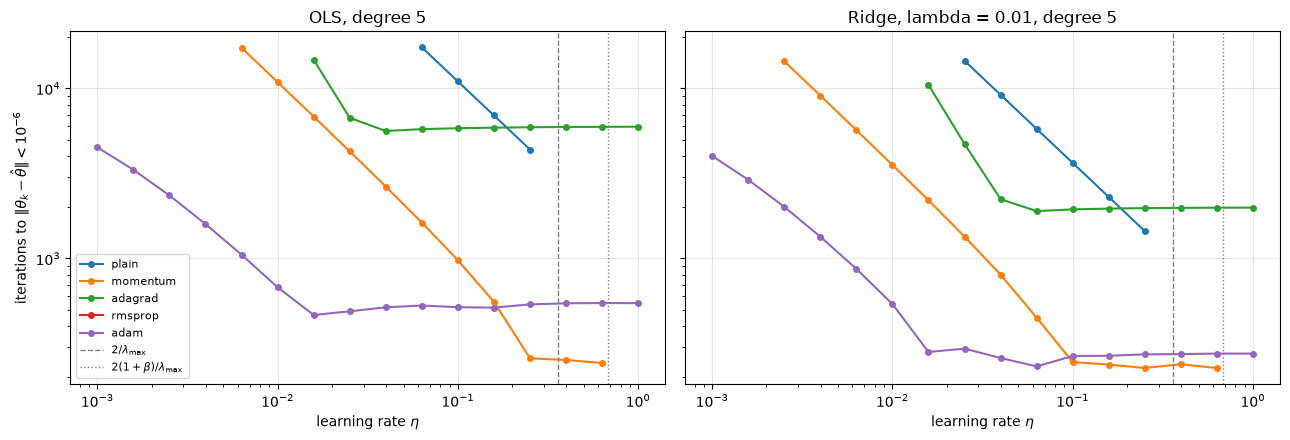

In [667]:
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
etas_f = np.geomspace(1e-3, 1.0, 16)                   # learning-rate grid, as in week38tuesday
problems = {
    "OLS": (lambda th: grad_ols_analytic(th, X, y_c), theta_ols_cf, eig_ols),
    f"Ridge, lambda = {lmbda}": (lambda th: grad_ridge_analytic(th, X, y_c, lmbda), theta_ridge_cf, eig_ridge),
}

scan_f = {}                                            # scan_f[problem][method] = (iterations, final distance) per eta
for prob, (g_fn, target, eigs) in problems.items():
    scan_f[prob] = {}
    print(f"{prob}:  2/lambda_max = {2 / eigs.max():.3f},  2(1+beta)/lambda_max = {2 * 1.9 / eigs.max():.3f}")
    for method in methods:
        its, final = [], []
        with np.errstate(all="ignore"):
            for eta in etas_f:
                k, dist = optimise_to_accuracy(g_fn, target, method, eta, p)
                its.append(k)
                final.append(dist[-1])
        its, final = np.array(its), np.array(final)
        scan_f[prob][method] = (its, final)
        ok = np.isfinite(its)                          # learning rates for which the accuracy was reached
        if ok.any():
            b = np.nanargmin(its)
            print(f"   {method:8s}: reaches 1e-6 for eta from {etas_f[ok].min():.4f} to {etas_f[ok].max():.4f}"
                  f" ({ok.sum()} of {len(etas_f)} values); fewest iterations {its[b]:.0f} at eta = {etas_f[b]:.4f}")
        else:
            print(f"   {method:8s}: never reaches 1e-6; smallest final distance {np.nanmin(final):.1e}"
                  f" at eta = {etas_f[np.nanargmin(final)]:.4f}")
    print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (prob, (_, _, eigs)) in zip(axes, problems.items()):
    for method in methods:
        its, _ = scan_f[prob][method]
        ax.loglog(etas_f, its, "o-", ms=4, label=method)
    ax.axvline(2 / eigs.max(), color="gray", ls="--", lw=1, label=r"$2/\lambda_{\max}$")
    ax.axvline(2 * 1.9 / eigs.max(), color="gray", ls=":", lw=1, label=r"$2(1+\beta)/\lambda_{\max}$")
    ax.set_xlabel(r"learning rate $\eta$")
    ax.set_title(f"{prob}, degree {degree}")
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"iterations to $\|\theta_k-\hat\theta\| < 10^{-6}$")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### f.3 Iterations to the closed form at each method's best learning rate
**Source:** `week38tuesday.ipynb`, Case 1, Step 3 (all methods from $\boldsymbol\theta_0 = \boldsymbol 0$, error against the
iteration, iterations to a fixed accuracy). **Modifications:** our data, OLS and Ridge, distance to the closed
form, and each method run at its own best learning rate from the scan in f.2 (for a method that never reaches
$10^{-6}$, the learning rate with the smallest final distance).
> **LLM note:** Written with Claude (Level 4), adapted from `week38tuesday.ipynb` Case 1, Step 3.

OLS:
   plain    at eta = 0.2512: 4369 iterations
   momentum at eta = 0.6310: 243 iterations
   adagrad  at eta = 0.0398: 5614 iterations
   rmsprop  at eta = 0.0010: not reached in 20000 (distance 1.1e-03)
   adam     at eta = 0.0158: 465 iterations

Ridge, lambda = 0.01:
   plain    at eta = 0.2512: 1448 iterations
   momentum at eta = 0.2512: 227 iterations
   adagrad  at eta = 0.0631: 1898 iterations
   rmsprop  at eta = 0.0010: not reached in 20000 (distance 1.1e-03)
   adam     at eta = 0.0631: 232 iterations



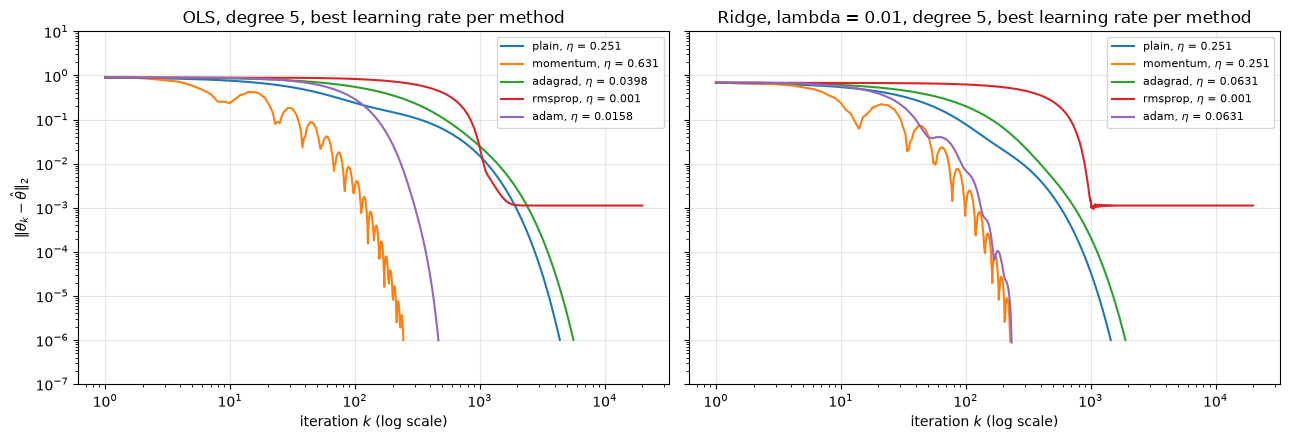

In [668]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (prob, (g_fn, target, _)) in zip(axes, problems.items()):
    print(f"{prob}:")
    for method in methods:
        its, final = scan_f[prob][method]
        b = np.nanargmin(its) if np.isfinite(its).any() else np.nanargmin(final)   # best eta from f.2
        with np.errstate(all="ignore"):
            k, dist = optimise_to_accuracy(g_fn, target, method, etas_f[b], p)
        ax.loglog(np.arange(1, len(dist) + 1), dist, label=rf"{method}, $\eta$ = {etas_f[b]:.3g}")   # log axes: fast and slow methods both visible
        result = f"{k:.0f} iterations" if np.isfinite(k) else f"not reached in 20000 (distance {dist[-1]:.1e})"
        print(f"   {method:8s} at eta = {etas_f[b]:.4f}: {result}")
    print()
    ax.set_ylim(1e-7, 10)
    ax.set_xlabel("iteration $k$ (log scale)")
    ax.set_title(f"{prob}, degree {degree}, best learning rate per method")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"$\|\theta_k - \hat\theta\|_2$")
plt.tight_layout()
plt.show()

#### f.4 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions (text Level 3 if used
> as it is). Rewrite in your own words for the report, and check every number against your own run.
> **[own]** marks reasoning that is not taken from the course material.

1. **What the methods do, and what the learning rate means.** All five methods step against the gradient; they
   differ in how the step is built (`optimiser_step`, f.1). *Plain* takes $\eta$ times the gradient (Eq. (4.15)).
   *Momentum* keeps a velocity that remembers 90 % of the previous step and adds $\eta$ times the new gradient
   (Eq. (4.28)), like a heavy ball. *AdaGrad* divides each coordinate's gradient by the square root of the **sum** of
   its past squared gradients (Eqs. (4.58)–(4.61)); *RMSprop* by the square root of a decaying **average** of them
   (Eqs. (4.63)–(4.64)); *Adam* combines an averaged gradient (momentum) with the RMSprop scaling and a bias
   correction (Eqs. (4.67)–(4.71)). This gives two families: for plain and momentum $\eta$ **multiplies** the gradient,
   so too large an $\eta$ explodes, with a bound set by the curvature; for AdaGrad, RMSprop and Adam the gradient is
   divided by its own typical size, so $\eta$ acts as a **step length** (Sections 4.9, 4.12). In every run $\eta$ is a
   fixed setting, the value on the x-axis of f.2; what the adaptive methods change during the run is the effective
   step built from it, not $\eta$ itself. A learning rate that changes over time (a schedule) appears only in part h).
   Degree 5 is the degree of the part e) starter cell; the exercise text does not fix it.

2. **Iterations to the closed form at the best learning rate (f.3).** OLS / Ridge, degree 5, to
   $\|\boldsymbol\theta_k - \hat{\boldsymbol\theta}\| < 10^{-6}$, each method at its own best learning rate from f.2:

   | method | OLS | Ridge |
   |---|---|---|
   | plain (best on the grid, $\eta = 0.25$) | 4369 | 1448 |
   | plain at $\eta^*$ (from e.3, not on the grid) | 3057 | 1019 |
   | momentum | 243 | 227 |
   | AdaGrad | 5614 | 1898 |
   | RMSprop | never (stalls at $1.1\cdot10^{-3}$) | never (stalls at $1.1\cdot10^{-3}$) |
   | Adam | 465 | 232 |

   The grid of 16 values does not contain $\eta^* = 0.359$; its next value, 0.40, is already above the bound
   $2/\lambda_{\max} = 0.360$ and diverges.

3. **Plain gradient descent (f.2, f.3).** Along the flattest direction each step removes a fraction $\eta\lambda_{\min}$ of
   the remaining distance (Eq. (4.19)), so reaching $10^{-6}$ from about 1 takes roughly
   $\ln(10^6)/(\eta\lambda_{\min}) = 13.8/(0.0113\,\eta)$ iterations [own estimate]: the count falls like $1/\eta$, a straight line
   of slope $-1$ on the log-log plot. This predicts about 19000 at $\eta = 0.063$ (the plot shows about 17000) and
   about 30000 at $\eta = 0.04$, beyond the limit of 20000, which is why the curve starts at 0.063. It ends at 0.25,
   the last grid value below $2/\lambda_{\max} = 0.36$, beyond which the steepest direction blows up (Theorem 4.1). In f.3
   its distance first drops quickly to about 0.2, as the steep directions are removed, and then decreases slowly as
   only the flattest direction is left [own reading].

4. **Momentum** is the fastest: about 12 times fewer iterations than plain gradient descent at $\eta^*$ for OLS.
   With well-chosen $\eta$ and $\beta$ the iteration count scales with $\sqrt\kappa$ instead of $\kappa$ (Section 4.6,
   Eq. (4.33)); here $\sqrt{491} \approx 22$. Momentum adds up consistent gradients in flat directions and damps
   the oscillation in steep ones (Section 4.6, "Why it works"). Along the flat direction the velocity builds up to
   about $\eta/(1-\beta) = 10\,\eta$ per step, so momentum behaves like plain gradient descent with a ten times larger
   learning rate [own reasoning]: its curve in f.2 is parallel to the plain one and shifted left by a factor of 10
   (it starts working at $\eta = 0.0063$ against 0.063), and at $\eta = 0.1$ it needs about 1000 iterations, against
   about 12000 predicted for plain. It converges up to $\eta = 0.63$, beyond the bound 0.36 of plain gradient descent
   but below $2(1+\beta)/\lambda_{\max} = 0.68$ (`week38tuesday` Case 1, Step 4); $\eta = 1$ diverges. In f.3 its distance
   oscillates on the way down: the heavy ball overshoots the minimum and swings back, a damped oscillation
   [own reading].

5. **AdaGrad** is slower than plain gradient descent at its best. Its accumulated sum of squared gradients never
   forgets, so the effective learning rate decays like $1/\sqrt t$ (Section 4.9, Eq. (4.62)). It never diverged on
   the grid, because its step is never longer than about $\eta$ (Section 4.9). For $\eta \ge 0.04$ its iteration count
   hardly depends on $\eta$; a plausible reason is that larger first steps produce larger gradients, which inflate the
   sum in the denominator by a similar amount, so the effective step ends up about the same [own reading, not
   checked]. In f.3 its curve has the smooth shape of plain gradient descent, only slower.

6. **RMSprop** never reaches $10^{-6}$ at any learning rate, for OLS or Ridge; at $\eta = 10^{-3}$ it stalls at a
   distance of $1.1\cdot10^{-3}$. Near the minimum its update becomes a step of fixed length $\eta\,\mathrm{sign}(g)$,
   Eq. (4.66), so it ends in a cycle of amplitude of order $\eta$ around the minimum instead of converging; it needs
   a decaying learning rate (Section 4.10). The lecture notes report the same on the polynomial fits of
   Section 4.4. In f.3 its distance stays flat for several hundred steps, because with steps of about
   $\eta = 0.001$ covering a distance of about 0.9 takes roughly 900 steps [own estimate], then drops, and then stays at
   $1.1\cdot10^{-3}$.

7. **Adam** reaches the accuracy for every learning rate on the grid, from $10^{-3}$ to 1 (16 of 16), in 465
   (OLS) and 232 (Ridge) iterations at best. Its step is bounded by $\eta$ in every coordinate, Eq. (4.72), so it
   cannot diverge in the sense of Eq. (4.20), and its first moment averages away the sign changes of the gradient
   near the minimum, so it settles where RMSprop cannot (Section 4.11). The learning rate still matters at small
   values, where the step length is the bottleneck (about 4500 iterations at $\eta = 10^{-3}$); for $\eta \gtrsim 0.016$
   the count stays near 500, presumably because the speed is then set by how fast its running averages adapt
   [own reading, not checked]. In f.3 it waits briefly and then drops very steeply; at the larger learning rate of the
   Ridge run ($\eta = 0.063$) its momentum part makes the curve oscillate like momentum's [own reading].

8. **Sensitivity to the learning rate (f.2).** Number of grid values (out of 16) for which the accuracy was
   reached, OLS / Ridge: plain 4 / 6, momentum 11 / 13, AdaGrad 10 / 10, RMSprop 0 / 0, Adam 16 / 16. Plain
   gradient descent works only in a narrow window, bounded above by $2/\lambda_{\max}$ and below by slowness;
   Adam is the least sensitive, RMSprop at a constant learning rate fails at every value.

9. **What the Ridge penalty changes.** With $\lambda = 10^{-2}$ the methods aim at the Ridge closed form, which is closer to
   the starting point $\boldsymbol\theta = \boldsymbol 0$ (distance about 0.7 against 0.9) because Ridge shrinks the coefficients
   (Proposition 3.5). The main effect is on the curvature: every eigenvalue of the Hessian moves up by
   $2\lambda = 0.02$ (Eq. (4.17)), so the flattest curvature rises from 0.011 to 0.031 and $\kappa$ drops from 491 to 178,
   while the steepest barely changes and the stable range of learning rates stays the same (bound 0.360 against
   0.358; Section 4.5). The penalty therefore helps most the methods that suffer most from the stretched cost:
   plain gradient descent and AdaGrad need 3.0 times fewer iterations, Adam 2 times fewer, momentum, which already
   handles the flat direction by building up speed, hardly fewer (243 against 227), and RMSprop, whose problem is its
   fixed step length near the minimum, is not helped at all [own reading]. Plain gradient descent reaches the accuracy
   at more grid values for Ridge (6 against 4) not because its stable range grew, but because each run is faster and
   more runs finish within 20000 iterations.

10. **Caveat.** One degree (5), one grid of 16 learning rates, the course's fixed values of $\beta$, $\rho$,
    $\beta_1$, $\beta_2$, and accuracy measured against the closed form, which a practical run would not know.

### Part g): Writing our own code for Lasso regression

Lasso regression (Section 3.9 of the lecture notes, and the lectures of weeks 35
and 36) represents our first encounter with a machine learning method which
cannot be solved through analytical expressions (as in OLS and Ridge
regression). Use the gradient descent methods you developed in parts e) and f)
to solve the Lasso optimization problem.

The $\ell_1$ penalty $\lambda\|\boldsymbol{\theta}\|_1$ is not differentiable
at $\theta_j=0$. Discuss how you could handle this: what does your automatic
differentiation tool return for the derivative of $|\theta|$ at zero, and is
that a valid subgradient? Based on the gradient, write your own code for Lasso
regression.

You can compare your results with the functionalities of **Scikit-Learn**; be
careful with the different conventions for the penalty parameter (`alpha`) and
the normalization of the cost function discussed in the week-35 and week-36
Tuesday sessions.

Discuss (critically) your results for the Runge function from OLS, Ridge and
Lasso regression using the various gradient descent approaches.

In [669]:
# What does AD say about d|theta|/dtheta at theta = 0?  (Discuss whether this is a valid subgradient.)
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

# Your Lasso code for part g) here

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0


## Part g): Lasso regression with our gradient descent methods — code

The cell above is the course's starter cell for part g), unchanged: it prints what `jax.grad` returns for the
derivative of $|\theta|$ at $\theta = 0$ and at $\pm 0.3$. The cells below do the rest of part g).

**Where each piece comes from** (course material is cited in the bibliography):

| Cell | Piece | Source | Status |
|---|---|---|---|
| starter cell above | `jax.grad(jnp.abs)` at $0$ and $\pm0.3$ | `Project1.ipynb` (part g) | copied, unchanged |
| g.1 | non-differentiability of $\|\theta\|$, subdifferential, how to handle it | lecture notes Section 3.9, Eqs. (3.58), (3.63), (3.65)–(3.66), (3.69); Section 4.14.7 | text |
| g.2 | Lasso cost and its subgradient | lecture notes Eq. (3.57) and (3.65); our `grad_ols_analytic` (e.1) | new code |
| g.2 | reference solution with `Lasso(alpha=lambda/2, fit_intercept=False)` | `week35tuesday.ipynb` Case 2 (convention $\alpha = \lambda/2$) | adapted |
| g.3 | the optimisers of parts e)–f) on the Lasso: learning-rate scan and convergence | our `optimiser_step`, `optimise_to_accuracy` (f.1); layout of f.2–f.3 | new code |
| g.4 | OLS, Ridge and Lasso at degree 5: coefficients and test MSE | our closed forms (e.3) and the results of g.2–g.3 | new code |

**Conventions.** We use the same data as in parts e)–f) (degree 5, standardised training columns, centred $y$) and
the Lasso cost of the lecture notes, Eq. (3.57),
$C(\boldsymbol\theta) = \frac1n\|\boldsymbol y - \boldsymbol X\boldsymbol\theta\|_2^2 + \lambda\|\boldsymbol\theta\|_1$, with $\lambda = 10^{-2}$ as for Ridge in
parts e)–f). Scikit-Learn's `Lasso` minimises $\frac{1}{2n}\|\boldsymbol y - \boldsymbol X\boldsymbol\theta\|_2^2 + \alpha\|\boldsymbol\theta\|_1$, which is our
cost divided by 2 with $\alpha = \lambda/2$ (`week35tuesday.ipynb` Case 2). Its intercept is switched off because $y$
is centred.

> **LLM note:** All code cells below were written with Claude Opus 5.5 (claude.ai, September 2026) at Level 4,
> using the course material listed above as the base. The text in g.1 was drafted with Claude (text Level 3
> if used as it is in the report).

#### g.1 The derivative of $|\theta|$ at zero, and how to handle it
> **LLM note:** Drafted with Claude (text Level 3 if used as it is), following lecture notes Section 3.9.

- **What AD returns.** The starter cell shows that `jax.grad(jnp.abs)` returns $+1$ at $\theta = 0$ (and $-1$ and
  $+1$ at $\mp 0.3$, as it should). At $0$ the absolute value has no derivative, Eq. (3.58); JAX simply uses the
  rule of the branch $\theta \ge 0$.
- **Is it a valid subgradient?** Yes. The subdifferential of $|\theta|$ at $0$ is the whole interval $[-1, 1]$,
  Eq. (3.65), and $+1$ lies in it. So is $0$, which is what `np.sign(0)` returns. Both are valid subgradients,
  but they are not equally useful: a convex function is minimised where $0$ lies in its subdifferential, and for
  the Lasso a coefficient is exactly zero at the minimum when $|\frac2n\boldsymbol x_j^T\boldsymbol r| \le \lambda$,
  Proposition 3.7, Eq. (3.66). A fixed choice such as $+1$ pushes a coefficient that sits at zero away from zero
  in one direction.
- **How to handle it.** (i) *Subgradient descent*: use any subgradient, for example
  $\nabla C = \frac2n\boldsymbol X^T(\boldsymbol X\boldsymbol\theta - \boldsymbol y) + \lambda\,\mathrm{sign}(\boldsymbol\theta)$ with $\mathrm{sign}(0) = 0$. This is
  what "based on the gradient" gives, and it is what we implement below with the methods of parts e)–f). With a
  fixed learning rate it does not settle: a coefficient whose optimum is zero keeps jumping across zero by about
  $\eta\lambda$ per step, so it is small but not exactly zero, and the distance to the solution stalls at a level
  set by $\eta$ (seen in g.3). A decreasing learning rate (Section 4.7.8) reduces this. (ii) *Soft thresholding*:
  treat the smooth part with a gradient step and the $\ell_1$ part exactly, with the soft-thresholding operator of
  Eq. (3.63); coordinate descent, Eq. (3.69), does this one coordinate at a time and sets coefficients exactly to
  zero. This is what Scikit-Learn's `Lasso` runs (Section 3.9), and we use it as the reference solution.

#### g.2 The Lasso cost, its subgradient, and the Scikit-Learn reference
**Source:** the cost is Eq. (3.57) of the lecture notes; the subgradient is the OLS gradient of e.1 plus
$\lambda\,\mathrm{sign}(\boldsymbol\theta)$, with $\mathrm{sign}(0) = 0 \in [-1, 1]$, Eq. (3.65). The reference solution uses
`Lasso(alpha=lambda/2, fit_intercept=False)`, as in `week35tuesday.ipynb`, Case 2. **Modifications:** our data and
$\lambda$; a very small tolerance for Scikit-Learn so that the reference is accurate.
> **LLM note:** Written with Claude (Level 4). New code, the Scikit-Learn call adapted from `week35tuesday.ipynb`.

In [670]:
from sklearn.linear_model import Lasso

lmbda_lasso = 1e-2                                   # same size as the Ridge penalty of parts e)-f)


def cost_lasso(theta, X, y, lmbda):
    """Eq. (3.57): (1/n)||y - X theta||^2 + lmbda * ||theta||_1."""
    return np.mean((y - X @ theta)**2) + lmbda * np.sum(np.abs(theta))


def grad_lasso(theta, X, y, lmbda):
    """
    A subgradient of Eq. (3.57): the OLS gradient (Eq. (4.13)) plus lmbda * sign(theta), with sign(0) = 0,
    which lies in the subdifferential [-1, 1] of |theta| at 0 (Eq. (3.65)).

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Wrote the subgradient from Eqs. (4.13) and (3.65).
    """
    return grad_ols_analytic(theta, X, y) + lmbda * np.sign(theta)


# reference: Scikit-Learn minimises (1/2n)||y - X theta||^2 + alpha ||theta||_1, i.e. our cost / 2 with alpha = lambda / 2
theta_lasso_skl = Lasso(alpha=lmbda_lasso / 2, fit_intercept=False,
                        max_iter=1_000_000, tol=1e-12).fit(X, y_c).coef_
c_lasso_skl = cost_lasso(theta_lasso_skl, X, y_c, lmbda_lasso)
print("Scikit-Learn Lasso, lambda =", lmbda_lasso, ":", np.round(theta_lasso_skl, 5))
print("coefficients exactly zero:", [f"x^{j + 1}" for j in np.where(theta_lasso_skl == 0)[0]])
print(f"cost at the reference solution: {c_lasso_skl:.8f}")

Scikit-Learn Lasso, lambda = 0.01 : [ 0.      -0.55439  0.0158   0.36017  0.     ]
coefficients exactly zero: ['x^1', 'x^5']
cost at the reference solution: 0.04066984


#### g.3 The gradient descent methods of parts e)–f) on the Lasso
**Source:** the update rules and the loop are our `optimiser_step` and `optimise_to_accuracy` from f.1 (course
code from `week38tuesday.ipynb`, adapted), now with the Lasso subgradient of g.2. **Modifications:** because the
Lasso has no closed form, the Scikit-Learn solution of g.2 is the reference. Since no method reaches $10^{-6}$ with
a fixed learning rate (g.1), every run is continued for 20000 iterations, the same budget as in part f), so that all methods are compared after the
same number of steps (with a larger budget, plain gradient descent and AdaGrad at small learning rates would get closer,
while the rattle at larger learning rates, set by $\eta\lambda$, would not shrink) and we record (i) the distance to the
reference after 20000 iterations and (ii) the number of iterations to reach $10^{-3}$. *Left:* final distance
against the learning rate, on the grid of f.2. *Right:* distance against the iteration at each method's best
learning rate (smallest final distance).
> **LLM note:** Written with Claude (Level 4). New code, reuses f.1.

method     best eta   iterations to 1e-3   distance after 20000   cost - reference cost   |theta_1|   |theta_5|
plain        0.0063                13721                1.0e-04                 8.2e-08     1.8e-05     4.0e-06
momentum     0.0010                 8592                5.0e-05                 2.1e-07     3.6e-05     1.8e-05
adagrad      0.0100                13556                2.0e-04                 5.2e-07     1.3e-04     5.0e-06
rmsprop      0.0016                  832                8.2e-04                 8.3e-06     1.6e-04     3.0e-04
adam         0.0010                 3241                4.0e-04                 3.0e-06     7.4e-05     3.6e-04


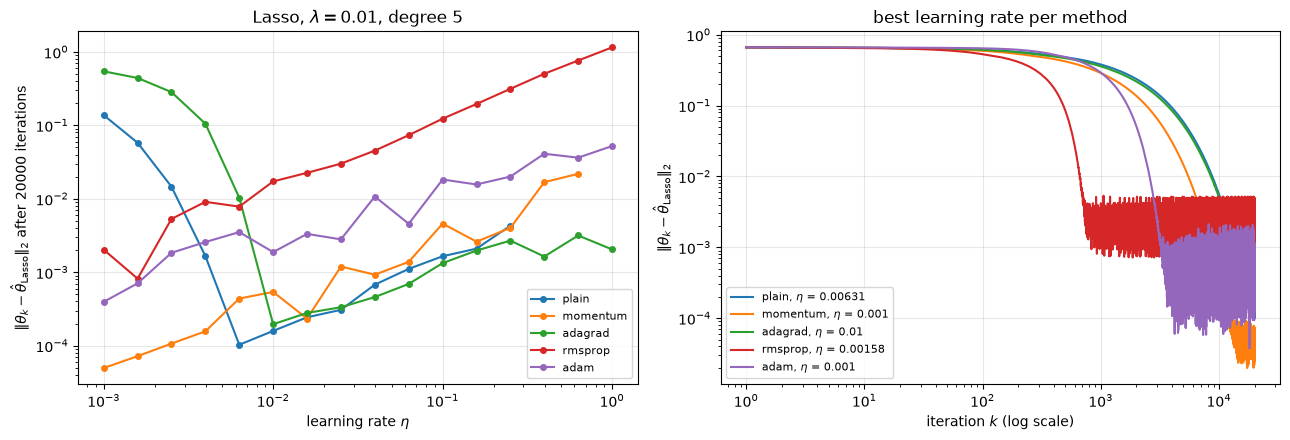

In [671]:
g_lasso = lambda th: grad_lasso(th, X, y_c, lmbda_lasso)
max_it_g, acc_g = 20_000, 1e-3

final_g, first_g = {}, {}                          # per method: final distance and iterations to 1e-3, per eta
for method in methods:
    final, first = [], []
    for eta in etas_f:
        with np.errstate(all="ignore"):
            # acc=0 so that every run goes the full max_it_g iterations
            _, dist = optimise_to_accuracy(g_lasso, theta_lasso_skl, method, eta, p, acc=0.0, max_iter=max_it_g)
        final.append(dist[-1] if len(dist) == max_it_g + 1 else np.nan)       # nan: diverged
        first.append(np.argmax(dist < acc_g) if (dist < acc_g).any() else np.nan)
    final_g[method], first_g[method] = np.array(final), np.array(first)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
theta_lasso_gd = {}                                # final parameters of each method at its best eta
print("method     best eta   iterations to 1e-3   distance after 20000   cost - reference cost   |theta_1|   |theta_5|")
for method in methods:
    ax1.loglog(etas_f, final_g[method], "o-", ms=4, label=method)
    b = np.nanargmin(final_g[method])              # best eta: smallest distance after 20000 iterations
    theta, state, dist = np.zeros(p), {}, [np.linalg.norm(theta_lasso_skl)]
    for t in range(1, max_it_g + 1):               # rerun at the best eta, keeping theta this time
        theta, state = optimiser_step(method, theta, g_lasso(theta), state, t, etas_f[b])
        dist.append(np.linalg.norm(theta - theta_lasso_skl))
    theta_lasso_gd[method] = theta
    ax2.loglog(np.arange(1, len(dist) + 1), dist, label=rf"{method}, $\eta$ = {etas_f[b]:.3g}")
    k3 = f"{first_g[method][b]:.0f}" if np.isfinite(first_g[method][b]) else "not reached"
    print(f"{method:9s}  {etas_f[b]:8.4f}   {k3:>18}   {dist[-1]:20.1e}   "
          f"{cost_lasso(theta, X, y_c, lmbda_lasso) - c_lasso_skl:21.1e}   {abs(theta[0]):9.1e}   {abs(theta[4]):9.1e}")

ax1.set_xlabel(r"learning rate $\eta$")
ax1.set_ylabel(r"$\|\theta_k - \hat\theta_{\rm Lasso}\|_2$ after 20000 iterations")
ax1.set_title(rf"Lasso, $\lambda = {lmbda_lasso}$, degree {degree}")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)
ax2.set_xlabel("iteration $k$ (log scale)")
ax2.set_ylabel(r"$\|\theta_k - \hat\theta_{\rm Lasso}\|_2$")
ax2.set_title("best learning rate per method")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### g.4 OLS, Ridge and Lasso for the Runge function (degree 5)
**Source:** the closed forms of OLS and Ridge from e.3 (`theta_ols_cf`, `theta_ridge_cf`), the Lasso solutions of
g.2 (Scikit-Learn) and g.3 (our gradient descent, the method with the smallest final distance), and the test
points of the 80/20 split of parts a)–b), scaled with the training statistics. **Modifications:** none beyond
putting the results side by side; $\lambda = 10^{-2}$ for Ridge and Lasso in the $1/n$ convention of this part.
> **LLM note:** Written with Claude (Level 4). New code.

In [672]:
# test points of parts a)-b), scaled with the TRAINING statistics (X is the scaled training matrix of e.1)
_, X_te5, _, y_mean5 = scale_train_test(polynomial_features(x_train, degree),
                                        polynomial_features(x_test, degree), y_train)
best_gd = min(methods, key=lambda m: np.linalg.norm(theta_lasso_gd[m] - theta_lasso_skl))   # closest to the reference

models = {"OLS (closed form)": theta_ols_cf,
          "Ridge (closed form)": theta_ridge_cf,
          "Lasso (Scikit-Learn)": theta_lasso_skl,
          f"Lasso (GD, {best_gd})": theta_lasso_gd[best_gd]}
print("model                      " + "".join(f"{'x^' + str(j + 1):>10}" for j in range(p))
      + "    test MSE   exact zeros")
for name, th in models.items():
    print(f"{name:26s} " + "".join(f"{v:10.4f}" for v in th)
          + f"    {MSE(y_test, X_te5 @ th + y_mean5):.4f}   {np.sum(th == 0):6d}")   # coefficients that are exactly 0
print(f"\nsmallest |theta_j| of the gradient-descent Lasso: {np.min(np.abs(theta_lasso_gd[best_gd])):.1e}"
      "  (small, but not exactly zero)")

model                             x^1       x^2       x^3       x^4       x^5    test MSE   exact zeros
OLS (closed form)             -0.0658   -0.6952    0.2279    0.4944   -0.1412    0.0366        0
Ridge (closed form)           -0.0202   -0.5663    0.0909    0.3703   -0.0535    0.0393        0
Lasso (Scikit-Learn)           0.0000   -0.5544    0.0158    0.3602    0.0000    0.0394        2
Lasso (GD, momentum)           0.0000   -0.5544    0.0158    0.3602    0.0000    0.0394        0

smallest |theta_j| of the gradient-descent Lasso: 1.8e-05  (small, but not exactly zero)


#### g.5 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions (text Level 3 if used
> as it is). Rewrite in your own words for the report, and check every number against your own run.
> **[own]** marks reasoning that is not taken from the course material.

1. **The derivative at zero (starter cell, g.1).** `jax.grad(jnp.abs)(0.0)` returns $+1$. This is a valid
   subgradient, since the subdifferential of $|\theta|$ at $0$ is $[-1, 1]$ (Eq. (3.65)); so is $\mathrm{sign}(0) = 0$,
   which our own Lasso gradient uses.

2. **The reference solution (g.2).** Scikit-Learn's Lasso with $\alpha = \lambda/2$ sets the coefficients of $x$ and
   $x^5$ exactly to zero, shrinks $x^3$ to 0.016 and keeps $x^2$ and $x^4$ ($-0.554$ and $0.360$). Keeping mainly
   the even powers fits a function that is even (part a) [own reading].

3. **Our gradient descent on the Lasso (g.3).** None of the five methods reaches $10^{-6}$ with a fixed learning rate,
   whereas for OLS and Ridge all but RMSprop did (part f). After 20000 iterations the smallest distances to the
   reference are $5\cdot10^{-5}$ (momentum, $\eta = 10^{-3}$), $1\cdot10^{-4}$ (plain, $\eta = 0.0063$),
   $2\cdot10^{-4}$ (AdaGrad), $4\cdot10^{-4}$ (Adam) and $8\cdot10^{-4}$ (RMSprop); the costs are within $10^{-7}$ to
   $10^{-5}$ of the reference. The coefficients that should be zero end up small but never exactly zero
   ($|\theta_1|$ and $|\theta_5|$ between $4\cdot10^{-6}$ and $4\cdot10^{-4}$).

4. **Why the methods cannot settle: the rattle around zero (g.1, g.3).** For a coefficient whose optimum is zero, the
   subgradient adds $+\lambda$ when it is slightly positive and $-\lambda$ when it is slightly negative (Eq. (3.65)), so
   every step pushes it back across zero by about $\eta\lambda$. Near the solution the gradient does not go to zero,
   as it does for the smooth problems of parts e)–f), but keeps flipping between $-\lambda$ and $+\lambda$, so the
   distance to the solution levels off at a value set by $\eta$ instead of decreasing further. For plain gradient
   descent $\eta\lambda \approx 6\cdot10^{-5}$ at $\eta = 0.0063$ and $2.5\cdot10^{-3}$ at $\eta = 0.25$, against final distances
   of $1\cdot10^{-4}$ and $4\cdot10^{-3}$ [own check]. Subgradient descent with a fixed step only reaches a neighbourhood of
   the solution whose size grows with the step; a decaying learning rate (Section 4.7.8) or soft thresholding
   (Eq. (3.63)) is needed to go further (g.1).

5. **The learning rate now trades speed against accuracy (g.3, left).** The distance after 20000 iterations results
   from two competing effects [own reading]: at small $\eta$ the steps are short and the method has *not yet arrived*,
   so a larger $\eta$ helps; once it has arrived, it *rattles* by about $\eta\lambda$, so a larger $\eta$ hurts. The final
   distance is roughly the larger of the two. Plain gradient descent and AdaGrad therefore show a V: plain is still
   0.14 away at $\eta = 0.001$, reaches its minimum of $1\cdot10^{-4}$ at $\eta = 0.0063$, and rises to $4\cdot10^{-3}$ at
   $\eta = 0.25$; AdaGrad is best at $\eta = 0.01$, and its right branch is flatter because its shrinking steps reduce
   the rattle over time. Momentum, Adam and RMSprop arrive within the budget even at the smallest $\eta$ on the grid,
   so only the rising branch is visible and their best value lies at or below $\eta = 10^{-3}$: momentum's velocity makes
   it behave like plain gradient descent with a ten times larger $\eta$ (part f), and Adam and RMSprop take steps of
   about length $\eta$, so 20000 steps cover far more than the distance of 0.66 to the solution. Above $2/\lambda_{\max}$ plain
   gradient descent still diverges, and momentum diverges at $\eta = 1$, as in parts e)–f): the non-smooth penalty does not
   change the curvature of the smooth part [own reading]. In part f) there was no rising branch from rattling,
   because on a smooth problem the steps shrink near the minimum.

6. **Convergence at each method's best learning rate (g.3, right).** All curves start at about 0.66, the size of the
   Lasso solution and hence its distance from $\boldsymbol\theta_0 = \boldsymbol 0$. Because the best learning rates are small
   (0.001–0.01), every method needs hundreds to thousands of steps just to arrive. RMSprop arrives first (reaching
   $10^{-3}$ after 832 iterations) and then rattles in a thick band between about $10^{-3}$ and $5\cdot10^{-3}$; Adam arrives after
   about 3000 iterations (reaching $10^{-3}$ after 3241) and rattles between about $10^{-4}$ and $10^{-3}$; momentum arrives
   after about 6000 and rattles lowest, between about $2\cdot10^{-5}$ and $10^{-4}$; plain gradient descent and AdaGrad are
   still descending when the budget ends. The thickness of the bands is the jumping back and forth at every step.
   For RMSprop this is the fixed-length step of Eq. (4.66), as in part f). Unlike in part f), Adam no longer settles
   either: the subgradient of $|\theta_j|$ jumps between $-\lambda$ and $+\lambda$ near zero instead of going to zero, so the
   averaging that lets Adam settle on a smooth problem (Section 4.11) no longer removes the step [own reading].

7. **The budget of 20000 iterations.** The number is our choice; the exercise does not fix one. It is the same limit as
   in part f), where it is several times what every converging method needs, and it keeps the 80 runs of the scan to
   about a minute. Because no method reaches $10^{-6}$ on the Lasso, all methods are compared after this fixed budget.
   The left branch of the V depends on it: with more iterations, plain gradient descent and AdaGrad at small $\eta$ would
   get closer and their best $\eta$ would move to smaller values. The rising branch does not depend on it, because the
   rattle is set by $\eta\lambda$, not by the number of iterations [own reasoning]. The conclusion that a fixed learning rate
   has to trade speed against accuracy does not depend on the budget.

8. **OLS, Ridge and Lasso compared (g.4).** OLS uses all five powers ($-0.066, -0.695, 0.228, 0.494, -0.141$);
   Ridge shrinks all of them but sets none to zero; the Lasso sets $x$ and $x^5$ exactly to zero and shrinks $x^3$
   to 0.016: shrinkage against selection (Sections 3.8–3.10). The test MSE is 0.037 for OLS, 0.039 for Ridge and
   0.039 for the Lasso: at degree 5, where there is little variance to remove (part b), the penalties mostly add
   bias [own reading]. Our gradient-descent Lasso agrees with Scikit-Learn to four decimals in every coefficient and
   in the test MSE, but it has no exact zeros (smallest $|\theta_j| = 1.8\cdot10^{-5}$).

9. **Critical assessment [own].** For OLS and Ridge the closed forms are exact and much cheaper than any gradient
   method; gradient descent is needed for the Lasso, which has no closed form (Section 3.9). But plain subgradient
   descent with a fixed learning rate is a poor Lasso solver: its accuracy is limited by $\eta$ and it does not
   produce exact zeros, which is the point of the Lasso. Coordinate descent with soft thresholding (Eq. (3.69)),
   as in Scikit-Learn, does both. Among our methods, the conclusions of part f) (momentum fastest, Adam robust,
   RMSprop never settling) hold for the smooth problems; for the non-smooth Lasso even Adam stops settling.

10. **Caveat.** One degree (5), one $\lambda$, one grid of learning rates, a budget of 20000 iterations, and a Scikit-Learn
    reference with tolerance $10^{-12}$.

### Part h): Stochastic gradient descent

Our last gradient step is to include stochastic gradient descent (Section 4.7
of the lecture notes) using the same methods to update the learning rates as in
parts e)–g). Split the training data into mini-batches, loop over epochs, and
study the dependence on the mini-batch size, the number of epochs and the
learning-rate schedule. Compare and discuss your results with and without
stochastic gradient descent and give a critical assessment of the various
methods — both in terms of the final accuracy relative to the closed-form
solutions of parts a) and b), and in terms of computational cost.

## Part h): Stochastic gradient descent — code

**Where each piece comes from** (course material is cited in the bibliography):

| Cell | Piece | Source | Status |
|---|---|---|---|
| h.1 | `make_batches` (shuffle, split into minibatches) | `week38tuesday.ipynb` Case 2, Step 1 | copied |
| h.1 | `step_length`, the schedule $\eta_t = t_0/(t+t_1)$ | `week38tuesday.ipynb` Case 2, Step 2; lecture notes Eq. (4.52) | copied |
| h.1 | `sgd` (epochs, minibatches, any method of `optimiser_step`, optional schedule) | `week38tuesday.ipynb` Case 2, Step 2; lecture notes Eq. (4.37) | adapted |
| h.2 | dependence on the minibatch size and the number of epochs, all five methods | `week38tuesday.ipynb` Case 2, Steps 3 and 5 | adapted |
| h.3 | constant against decaying learning rates | `week38tuesday.ipynb` Case 2, Step 4; lecture notes Section 4.7.8 | adapted |
| h.4 | with and without SGD: accuracy after the same number of epochs, and computing time | asked in the project text; cost count of lecture notes Eq. (4.38) | new code |

**Set-up.** As in parts e)–g): degree 5, the 80 standardised training points with centred $y$, OLS and Ridge
($\lambda = 10^{-2}$ in the $1/n$ convention, cost Eq. (4.16)), closed forms `theta_ols_cf` and `theta_ridge_cf` of
e.3, start at $\boldsymbol\theta_0 = \boldsymbol 0$, and the five methods of `optimiser_step` (f.1). The minibatch gradient is our
analytical gradient evaluated on the rows of the batch, i.e. the mean over the batch (Eq. (4.37)). Accuracy
relative to the closed form is measured in two ways: the distance $\|\boldsymbol\theta - \hat{\boldsymbol\theta}\|_2$ used in parts e)–f),
and the excess cost $C(\boldsymbol\theta) - C(\hat{\boldsymbol\theta})$ used in Section 4.7.8 of the lecture notes. Cost is counted in
**epochs**: one epoch of SGD uses every data point once and costs the same arithmetic as one full-gradient
step, whatever the batch size (Eq. (4.38)); we also measure the computing time.

> **LLM note:** All code cells of part h) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course material listed above as the base.

#### h.1 Minibatches, epochs, and the learning-rate schedule
**Source:** `make_batches` and `step_length` are copied from `week38tuesday.ipynb`, Case 2 (the schedule is
Eq. (4.52) of the lecture notes); `sgd` follows the course function: reshuffle every epoch, split into
minibatches, one step of `optimiser_step` per minibatch, with a constant $\eta$ or the schedule.
**Modifications:** the regularisation `lam` is passed to our `grad_ridge_analytic` (`lam = 0` is OLS); after every
epoch the function records the distance and the excess cost with respect to a target (the closed form), and it
stops if the iteration diverges.
> **LLM note:** `make_batches` and `step_length` are course code; `sgd` was adapted with Claude (Level 4).

In [673]:
import time


def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches (Section 4.7). Source: week38tuesday.ipynb."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]


def step_length(t, t0, t1):
    """The learning-rate schedule eta_t = t0 / (t + t1), Eq. (4.52). Source: week38tuesday.ipynb."""
    return t0 / (t + t1)


def cost_ridge_np(theta, X, y, lam):
    """Eq. (4.16) in NumPy: (1/n)||y - X theta||^2 + lam theta^T theta (lam = 0: OLS)."""
    return np.mean((y - X @ theta)**2) + lam * theta @ theta


def sgd(X, y, target, method="plain", n_epochs=500, batch_size=5, eta=0.1, schedule=None,
        lam=0.0, seed=SEED):
    """
    Minibatch SGD, Eq. (4.37), with any method of optimiser_step (f.1) and either a constant
    learning rate eta or the schedule (t0, t1) of Eq. (4.52).
    Returns the distance ||theta - target|| and the excess cost C(theta) - C(target) after every epoch
    (index 0 = start), and the final theta. Stops early if the iteration diverges.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted sgd of week38tuesday.ipynb (Case 2, Step 2): our gradient, per-epoch diagnostics.
    """
    rng = np.random.default_rng(seed)                  # fixed seed: the same shuffles for every run
    n, p_ = X.shape
    theta, state, t = np.zeros(p_), {}, 0
    c_target = cost_ridge_np(target, X, y, lam)
    dist = [np.linalg.norm(theta - target)]
    excess = [cost_ridge_np(theta, X, y, lam) - c_target]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):  # new shuffle every epoch
            t += 1                                     # t counts updates, not epochs
            g = grad_ridge_analytic(theta, X[batch], y[batch], lam)   # minibatch gradient, Eq. (4.37)
            eta_t = eta if schedule is None else step_length(t, *schedule)
            theta, state = optimiser_step(method, theta, g, state, t, eta_t)
        dist.append(np.linalg.norm(theta - target))
        excess.append(cost_ridge_np(theta, X, y, lam) - c_target)
        if not np.isfinite(dist[-1]) or dist[-1] > 1e6:  # diverged: stop
            break
    return np.array(dist), np.array(excess), theta

#### h.2 Dependence on the minibatch size and on the number of epochs (OLS)
**Source:** `week38tuesday.ipynb`, Case 2, Step 3 (vary $M$, count epochs, not updates) and Step 5 (the adaptive
methods with minibatches). **Modifications:** all five methods, $M = 1, 5, 20$ and $80$ ($= n$, full batch),
1000 epochs, OLS; the end state is summarised by the median over the last 100 epochs, since SGD fluctuates.
Each method uses one constant learning rate for all $M$, chosen so that $M = 1$ does not
diverge: for a single point the Hessian is $2\boldsymbol x_i\boldsymbol x_i^T$ with largest eigenvalue $2\|\boldsymbol x_i\|^2$, which is
92 here, so plain SGD needs $\eta < 2/92 = 0.022$ (the hint in `week38tuesday.ipynb` Case 2, Step 3). The values:
plain 0.02, momentum 0.002, AdaGrad 0.1, RMSprop 0.001, Adam 0.005.
> **LLM note:** Written with Claude (Level 4), adapted from `week38tuesday.ipynb` Case 2, Steps 3 and 5.

largest single-point Hessian eigenvalue 2|x_i|^2 = 92.1

excess cost after 10 / 100 epochs / median over epochs 901-1000   (distance: median over epochs 901-1000)
plain    M =   1: 1.2e-02 / 5.1e-03 / 3.8e-03   (5.1e-02)
plain    M =   5: 1.7e-02 / 5.4e-04 / 1.2e-04   (1.1e-02)
plain    M =  20: 2.4e-02 / 8.4e-03 / 6.9e-05   (1.1e-01)
plain    M =  80: 3.4e-02 / 2.0e-02 / 1.9e-03   (3.0e-01)
momentum M =   1: 1.1e-02 / 1.4e-02 / 3.5e-03   (4.5e-02)
momentum M =   5: 1.7e-02 / 5.1e-04 / 4.3e-05   (8.7e-03)
momentum M =  20: 2.5e-02 / 8.5e-03 / 6.9e-05   (1.1e-01)
momentum M =  80: 4.5e-02 / 2.0e-02 / 1.9e-03   (3.0e-01)
adagrad  M =   1: 6.9e-03 / 1.9e-04 / 7.1e-06   (2.8e-02)
adagrad  M =   5: 8.7e-03 / 2.9e-04 / 1.4e-05   (4.4e-02)
adagrad  M =  20: 1.1e-02 / 4.1e-04 / 2.1e-05   (5.5e-02)
adagrad  M =  80: 1.9e-02 / 1.2e-03 / 6.6e-06   (3.4e-02)
rmsprop  M =   1: 2.0e-02 / 1.4e-03 / 3.2e-05   (5.5e-03)
rmsprop  M =   5: 2.3e-02 / 7.1e-03 / 3.6e-05   (7.4e-02)
rmsprop  M =  20: 2.7e-02

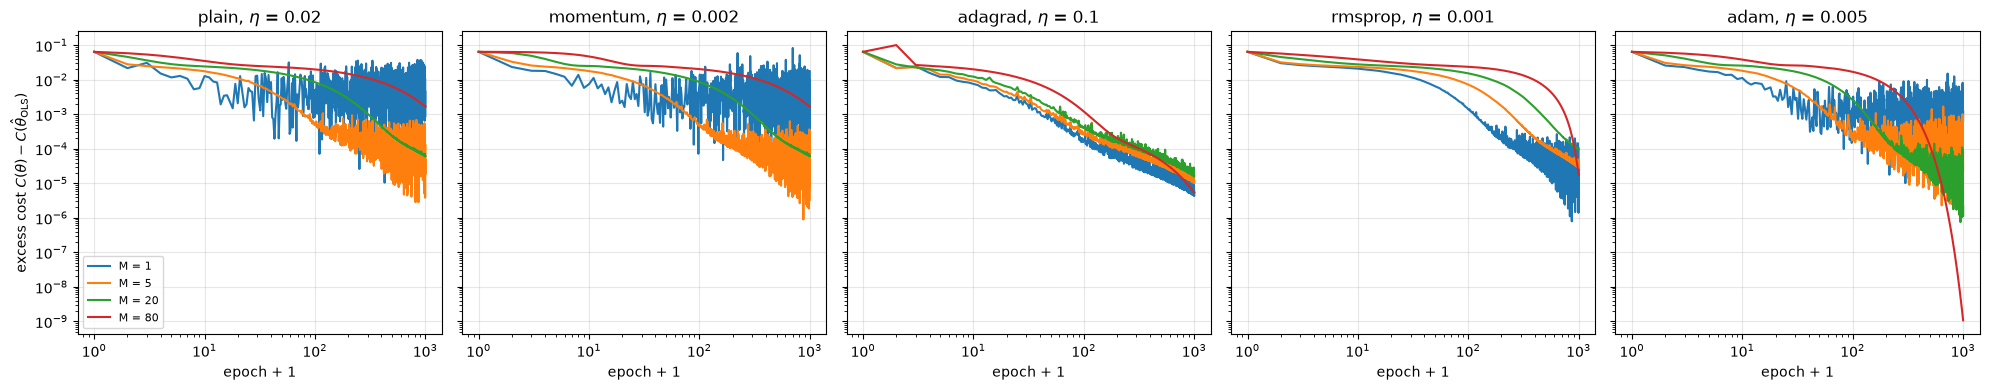

In [674]:
eta_sgd = {"plain": 0.02, "momentum": 0.002, "adagrad": 0.1, "rmsprop": 0.001, "adam": 0.005}
batch_sizes = [1, 5, 20, n]                              # n = 80: full batch, i.e. no SGD
n_ep = 1000
print(f"largest single-point Hessian eigenvalue 2|x_i|^2 = {2 * np.max(np.sum(X**2, axis=1)):.1f}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
print("\nexcess cost after 10 / 100 epochs / median over epochs 901-1000   (distance: median over epochs 901-1000)")
for ax, method in zip(axes, methods):
    for M in batch_sizes:
        with np.errstate(all="ignore"):
            dist, exc, _ = sgd(X, y_c, theta_ols_cf, method, n_epochs=n_ep, batch_size=M, eta=eta_sgd[method])
        ax.loglog(np.arange(1, len(exc) + 1), np.maximum(exc, 1e-16), label=f"M = {M}")   # epoch 0 plotted at 1
        if len(exc) < n_ep + 1:
            print(f"{method:8s} M = {M:3d}: diverged after {len(exc) - 1} epochs")
        else:
            # SGD fluctuates from epoch to epoch, so the end state is summarised by the median of the last 100 epochs
            print(f"{method:8s} M = {M:3d}: {exc[10]:.1e} / {exc[100]:.1e} / {np.median(exc[-100:]):.1e}"
                  f"   ({np.median(dist[-100:]):.1e})")
    ax.set_title(rf"{method}, $\eta$ = {eta_sgd[method]}")
    ax.set_xlabel("epoch + 1")
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"excess cost $C(\theta) - C(\hat\theta_{\rm OLS})$")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### h.3 The learning-rate schedule (plain SGD, $M = 5$, OLS)
**Source:** `week38tuesday.ipynb`, Case 2, Step 4, and lecture notes Section 4.7.8: with a constant learning rate
the minibatch noise keeps the iterate in a cloud around the minimum (Eqs. (4.49)–(4.51)); the schedule
$\eta_t = t_0/(t+t_1)$, Eq. (4.52), starts at $\eta_0 = t_0/t_1$ and decays like $1/t$ after about $t_1$ updates.
**Modifications:** our data; two constant rates and four schedules that all start at $\eta_0 = 0.05$ but decay
after $t_1 = 20, 100, 400, 2000$ updates; 2000 epochs (16 updates per epoch). Because SGD fluctuates from epoch to epoch,
the printed values are medians over blocks of epochs.
> **LLM note:** Written with Claude (Level 4), adapted from `week38tuesday.ipynb` Case 2, Step 4.

excess cost, median over epochs 1-10 / 91-100 / 401-500 / 1901-2000   (distance, median over epochs 1901-2000)
constant eta = 0.05   : 1.5e-02 / 9.6e-04 / 1.2e-03 / 1.2e-03   (2.5e-02)
constant eta = 0.01   : 2.3e-02 / 3.1e-03 / 9.1e-05 / 1.6e-05   (6.7e-03)
t0, t1 = 1, 20        : 2.1e-02 / 1.4e-02 / 1.1e-02 / 9.2e-03   (5.5e-01)
t0, t1 = 5, 100       : 1.7e-02 / 3.6e-03 / 1.4e-03 / 6.0e-04   (2.1e-01)
t0, t1 = 20, 400      : 1.5e-02 / 4.7e-04 / 1.0e-04 / 5.1e-05   (9.5e-02)
t0, t1 = 100, 2000    : 1.5e-02 / 3.0e-04 / 3.0e-05 / 9.5e-07   (9.0e-03)


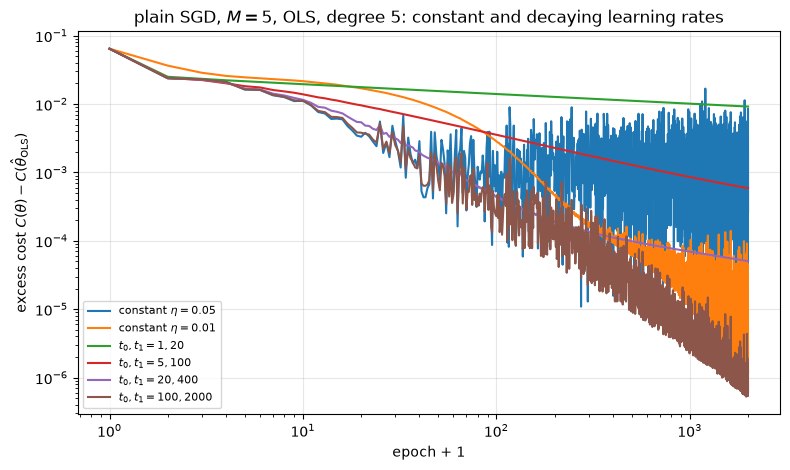

In [675]:
runs_h3 = {(r"constant $\eta = 0.05$", "constant eta = 0.05"): dict(eta=0.05),
           (r"constant $\eta = 0.01$", "constant eta = 0.01"): dict(eta=0.01),
           (r"$t_0, t_1 = 1, 20$", "t0, t1 = 1, 20"): dict(schedule=(1.0, 20.0)),
           (r"$t_0, t_1 = 5, 100$", "t0, t1 = 5, 100"): dict(schedule=(5.0, 100.0)),
           (r"$t_0, t_1 = 20, 400$", "t0, t1 = 20, 400"): dict(schedule=(20.0, 400.0)),
           (r"$t_0, t_1 = 100, 2000$", "t0, t1 = 100, 2000"): dict(schedule=(100.0, 2000.0))}
n_ep3 = 2000
fig, ax = plt.subplots(figsize=(8, 4.8))
print("excess cost, median over epochs 1-10 / 91-100 / 401-500 / 1901-2000   (distance, median over epochs 1901-2000)")
for (label, name), kw in runs_h3.items():
    dist, exc, _ = sgd(X, y_c, theta_ols_cf, "plain", n_epochs=n_ep3, batch_size=5, **kw)
    ax.loglog(np.arange(1, len(exc) + 1), exc, label=label)
    med = [np.median(exc[a:b]) for a, b in [(1, 11), (91, 101), (401, 501), (1901, 2001)]]   # medians smooth the SGD noise
    print(f"{name:22s}: " + " / ".join(f"{v:.1e}" for v in med) + f"   ({np.median(dist[1901:]):.1e})")
ax.set_xlabel("epoch + 1")
ax.set_ylabel(r"excess cost $C(\theta) - C(\hat\theta_{\rm OLS})$")
ax.set_title(r"plain SGD, $M = 5$, OLS, degree 5: constant and decaying learning rates")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### h.4 With and without SGD: accuracy after the same number of epochs, and computing time
**Source:** the comparison is asked in the project text; the cost count is Eq. (4.38) of the lecture notes (one
epoch of SGD costs the same arithmetic as one full-gradient step). **Modifications:** for OLS and Ridge, every method
is run (i) *without SGD*, i.e. full batch, at its best learning rate from the scan in f.2, and (ii) *with SGD*,
$M = 5$, at the learning rate of h.2, both for 500 epochs, and the excess cost and the distance to the closed form
are compared (medians over the last 100 epochs). Finally, the computing time per epoch is measured for plain SGD at
each batch size (it depends on the computer). The 500 epochs are our choice: enough for the fastest full-batch methods to reach the closed form (momentum and
Adam need 243 and 465 steps for OLS, part f) and for SGD to reach its noise floor (h.2), while keeping the cell
fast. Likewise, 1000 epochs in h.2 and 2000 in h.3 were chosen so that the plateaus and the slowly decaying
schedules have time to show their behaviour; the exercise does not prescribe these numbers.
> **LLM note:** Written with Claude (Level 4). New code.

In [676]:
n_ep4 = 500
for (prob, (_, target, _)), lam in zip(problems.items(), [0.0, lmbda]):
    print(f"{prob}, median over epochs 401-500:")
    print("method       full batch: eta   excess cost   distance  |  SGD M=5: eta   excess cost   distance")
    for method in methods:
        its, final = scan_f[prob][method]                # scan of f.2 (full batch)
        eta_full = etas_f[np.nanargmin(its) if np.isfinite(its).any() else np.nanargmin(final)]
        with np.errstate(all="ignore"):
            d_full, e_full, _ = sgd(X, y_c, target, method, n_epochs=n_ep4, batch_size=n, eta=eta_full, lam=lam)
            d_sgd, e_sgd, _ = sgd(X, y_c, target, method, n_epochs=n_ep4, batch_size=5, eta=eta_sgd[method], lam=lam)
        med = lambda a: np.median(a[-100:])            # median of the last 100 epochs (smooths the SGD noise)
        print(f"{method:9s}  {eta_full:15.4f}   {max(med(e_full), 0):11.1e}   {med(d_full):8.1e}  |"
              f"  {eta_sgd[method]:11.4f}   {max(med(e_sgd), 0):11.1e}   {med(d_sgd):8.1e}")
    print()

print("computing time per epoch, plain SGD (this computer):")
for M in batch_sizes:
    t_start = time.perf_counter()
    sgd(X, y_c, theta_ols_cf, "plain", n_epochs=200, batch_size=M, eta=eta_sgd["plain"])
    per_epoch = (time.perf_counter() - t_start) / 200
    print(f"   M = {M:3d}: {n // M if n % M == 0 else n // M + 1:3d} updates per epoch, {per_epoch * 1e3:.3f} ms per epoch")

OLS, median over epochs 401-500:
method       full batch: eta   excess cost   distance  |  SGD M=5: eta   excess cost   distance
plain               0.2512       2.9e-05    7.1e-02  |       0.0200       1.3e-04    4.8e-02
momentum            0.6310       0.0e+00    2.8e-11  |       0.0020       6.9e-05    4.9e-02
adagrad             0.0398       4.2e-04    1.3e-01  |       0.1000       4.4e-05    7.9e-02
rmsprop             0.0010       7.7e-03    4.6e-01  |       0.0010       1.5e-04    1.4e-01
adam                0.0158       3.1e-14    2.3e-06  |       0.0050       1.1e-04    2.0e-02

Ridge, lambda = 0.01, median over epochs 401-500:
method       full batch: eta   excess cost   distance  |  SGD M=5: eta   excess cost   distance
plain               0.2512       1.1e-07    2.6e-03  |       0.0200       9.8e-05    6.7e-03
momentum            0.2512       0.0e+00    2.1e-11  |       0.0020       3.8e-05    4.4e-03
adagrad             0.0631       9.1e-07    6.4e-03  |       0.1000      

#### h.5 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions (text Level 3 if used
> as it is). Rewrite in your own words for the report, and check every number against your own run.
> **[own]** marks reasoning that is not taken from the course material; **[own check, not in the notebook]**
> marks numbers from additional checks that the notebook does not print.

1. **What SGD changes, and how we measure it.** Instead of the gradient over all 80 training points, each step uses
   the gradient over a random minibatch of $M$ points (Eq. (4.37)). One epoch is one pass through all points, cut into
   $80/M$ minibatches: $M = 1$ makes 80 updates per epoch, $M = 5$ makes 16, $M = 20$ makes 4 and $M = 80$ makes one,
   which is ordinary full-batch gradient descent. Every epoch costs the same arithmetic whatever $M$ is (Eq. (4.38)),
   so results are compared per epoch. Accuracy is measured by the distance $\|\boldsymbol\theta - \hat{\boldsymbol\theta}\|_2$ and by the
   **excess cost** $C(\boldsymbol\theta) - C(\hat{\boldsymbol\theta})$, how much the current cost exceeds its smallest possible value
   (Section 4.7.8). At the best fit the *gradient* is zero, but the *cost* is not: it is the training MSE of the best
   degree-5 fit, about 0.03 (part a), set by the noise in the data and by what a degree-5 polynomial cannot represent.
   Subtracting it makes the excess cost zero exactly at the best fit.

2. **Where the gradient noise comes from.** The full gradient is the average of 80 per-point gradients
   $\boldsymbol g_i = 2\boldsymbol x_i(\boldsymbol x_i^T\boldsymbol\theta - y_i)$ (Eqs. (4.34)–(4.35)), which differ from point to point because the points have
   different positions and residuals. At the best fit they cancel exactly, but the individual residuals do not vanish
   (typical size 0.17). A minibatch averages only $M$ randomly chosen per-point gradients, which usually do not cancel.
   Like any small random sample it is right on average (unbiased, Eq. (4.41)), but off by a random amount whose
   variance falls like $1/M$ (Eq. (4.42)). **[own check, not in the notebook]** At the exact minimum, where the full
   gradient is $10^{-15}$, the minibatch gradient still has a typical size of 0.48 ($M = 1$), 0.27 ($M = 5$) and 0.13
   ($M = 20$), shrinking roughly like $1/\sqrt M$. Far from the minimum the true gradient is large compared with this
   random error, so almost every step goes in roughly the right direction; near the minimum the true gradient goes to
   zero while the random error does not, so with a constant learning rate every step gives a random kick of size
   about $\eta$ times the error, and the iterate wanders in a cloud around the minimum (Section 4.7.8,
   Eqs. (4.49)–(4.51)) [own reading]. This is noise in the gradient estimate, not the noise $\sigma$ in the data, although
   it exists only because the residuals at the minimum are not zero.

3. **Minibatch size and number of epochs (h.2).** Excess cost for OLS after 1000 epochs (median over the last
   100 epochs), each method at one fixed learning rate:

   | method | $M = 1$ | $M = 5$ | $M = 20$ | $M = 80$ (full batch) |
   |---|---|---|---|---|
   | plain | $3.8\cdot10^{-3}$ | $1.2\cdot10^{-4}$ | $6.9\cdot10^{-5}$ | $1.9\cdot10^{-3}$ |
   | momentum | $3.5\cdot10^{-3}$ | $4.3\cdot10^{-5}$ | $6.9\cdot10^{-5}$ | $1.9\cdot10^{-3}$ |
   | AdaGrad | $7.1\cdot10^{-6}$ | $1.4\cdot10^{-5}$ | $2.1\cdot10^{-5}$ | $6.6\cdot10^{-6}$ |
   | RMSprop | $3.2\cdot10^{-5}$ | $3.6\cdot10^{-5}$ | $1.1\cdot10^{-4}$ | $5.3\cdot10^{-5}$ |
   | Adam | $1.1\cdot10^{-3}$ | $9.5\cdot10^{-5}$ | $1.1\cdot10^{-5}$ | $4.5\cdot10^{-9}$ |

   The learning rate of each method is chosen small enough that $M = 1$ does not diverge: a single point gives a cost
   with curvature up to 92, so plain SGD needs $\eta < 0.022$ (`week38tuesday` Case 2, Step 3). A larger batch is a
   **trade-off**, not simply better: it reduces the gradient noise, so the iterate oscillates less and settles at a
   lower level, but it makes fewer updates per epoch and progresses more slowly. A small batch makes the fastest
   progress at first (after 10 epochs $M = 1$ is ahead for every method) but stalls on a high, noisy plateau (around
   $10^{-3}$ for plain, momentum and Adam with $M = 1$). The full batch has no noise but only one update per epoch, at a
   learning rate chosen for $M = 1$, so for plain and momentum it is slow. For plain SGD and momentum an intermediate
   batch ($M = 5$–20) is best after 1000 epochs; momentum behaves like plain SGD with a ten times larger learning
   rate (part f). For Adam the plateaus fall with $M$ (about $10^{-3}$, $10^{-4}$, $10^{-5}$ for $M = 1, 5, 20$), and with
   the full batch it converges to $4.5\cdot10^{-9}$, since there is no noise to stop it. AdaGrad hardly depends on $M$:
   its built-in $1/\sqrt t$ decay (Eq. (4.62)) acts as a schedule and shrinks the noise too [own reading]. RMSprop is
   slow for every $M$ because its steps are only about $\eta = 0.001$ long, and $M = 1$, with the most steps per epoch,
   gets furthest. **Epochs:** with a constant learning rate the SGD curves flatten into noisy plateaus, and further
   epochs do not lower them (Section 4.7.8); the full-batch curves keep descending.

4. **Learning-rate schedule (h.3; plain SGD, $M = 5$).** A constant $\eta = 0.05$ is fast at first but stays in a noisy
   band around $1.2\cdot10^{-3}$ from epoch 400 to 2000; a constant $\eta = 0.01$ starts more slowly, because its steps are
   smaller, but its noise cloud is smaller too, so it reaches a lower level ($1.6\cdot10^{-5}$ after 2000 epochs). With
   the schedule $\eta_t = t_0/(t+t_1)$ (Eq. (4.52)), where $t$ counts updates (16 per epoch), all four schedules start
   at $\eta_0 = t_0/t_1 = 0.05$ and begin to decay after about $t_1$ updates; by the end of the run (32000 updates) their
   learning rates have fallen to $3\cdot10^{-5}$, $1.6\cdot10^{-4}$, $6\cdot10^{-4}$ and $3\cdot10^{-3}$ for $t_1$ = 20, 100,
   400 and 2000 [own calculation]. The decay time decides everything: $t_1 = 20$ decays after about one epoch, so the
   steps become too small to cross the flat direction and the iterate freezes far from the minimum ($9.2\cdot10^{-3}$
   after 2000 epochs, distance 0.55), because the sum of the steps is too short in practice (the first Robbins–Monro
   condition, $\sum_t\eta_t = \infty$, Eq. (4.53), Section 4.7.8); $t_1 = 100$ and 400 give $6.0\cdot10^{-4}$ and $5.1\cdot10^{-5}$;
   $t_1 = 2000$ gives $9.5\cdot10^{-7}$, the best of all runs: it keeps the fast start of $\eta = 0.05$ for about 125 epochs
   and then decays, so its noise cloud shrinks while the constant rate keeps rattling, and it ends with a smaller
   learning rate than the constant 0.01. The schedules whose learning rate is already small give smooth curves; the
   $t_1 = 2000$ curve is noisy at first and its band moves down as $\eta$ decays. A schedule needs steps that do not shrink
   too fast, so the minimum can still be reached, and steps that shrink eventually, so the noise dies out (Eq. (4.53)):
   the recipe of Section 4.7.8 is to keep $t_0/t_1$ and enlarge both constants.

5. **With and without SGD (h.4), 500 epochs (the same arithmetic, Eq. (4.38)).** Every method is run with the full
   batch at its best learning rate from part f) (500 steps) and with SGD, $M = 5$, at the learning rate of h.2 (8000
   steps). Without SGD, momentum and Adam reach the closed forms of parts a) and b) to machine precision (excess cost
   $0$ to $3\cdot10^{-14}$, distance $\le 2\cdot10^{-6}$; the printed 0 means below the printed precision). Plain gradient descent
   reaches $2.9\cdot10^{-5}$ (OLS) and $1.1\cdot10^{-7}$ (Ridge): at $\eta = 0.25$ it needs about 4400 steps to reach $10^{-6}$
   (part f) and gets only 500. AdaGrad and RMSprop are slower ($4.2\cdot10^{-4}$ and $7.7\cdot10^{-3}$ for OLS), because
   their part-f learning rates were chosen for 20000 iterations; with 500 steps of about $0.001$, RMSprop has barely
   moved (distance 0.46). With SGD every method stops at its noise floor: an excess cost between $4\cdot10^{-5}$ and
   $1.5\cdot10^{-4}$ for OLS and between $7\cdot10^{-6}$ and $1.1\cdot10^{-4}$ for Ridge. SGD reaches the closed forms only up to
   this floor; it is better than the full batch only where the full-batch learning rate was poor for a 500-step run
   (AdaGrad, RMSprop). Ridge is better throughout because its cost is better conditioned (part e). The distance of SGD
   to the closed form ($10^{-2}$ to $10^{-1}$) looks much worse than its excess cost suggests (plain SGD for OLS: distance
   0.048, excess cost $1.3\cdot10^{-4}$), because the noise cloud is largest along the flat directions, where moving
   $\boldsymbol\theta$ hardly changes the fit ("large clouds in flat directions cost little", Section 4.7.8); the excess cost is
   therefore the more meaningful measure for SGD.

6. **Computational cost (h.4).** One epoch costs the same arithmetic for every batch size (Eq. (4.38)), but the
   measured time per epoch was 0.37 ms for $M = 1$, 0.08 ms for $M = 5$, 0.03 ms for $M = 20$ and 0.014 ms for the
   full batch: $M = 1$ is about 27 times slower than the full batch, because for tiny batches the overhead of each
   update (the Python loop and function calls) exceeds the arithmetic, and $M = 1$ makes 80 updates per epoch
   (Section 4.7.2). The times depend on the computer, the ratios much less.

7. **The numbers of epochs.** The epoch counts are our choice; the exercise does not prescribe them. 500 epochs in h.4
   are enough for the fastest full-batch methods to reach the closed form (momentum and Adam need 243 and 465 steps for
   OLS, part f) and for SGD to reach its noise floor, which it does within about 100–300 epochs (h.2). 1000 epochs in
   h.2 and 2000 in h.3 give the plateaus and the slowly decaying schedules time to show their behaviour. With fewer
   epochs full-batch Adam would not yet have reached the closed form; with more, the slower full-batch methods would
   improve while SGD would stay at its floor, so the conclusion would only get stronger [own reasoning].

8. **Critical assessment.** With $n = 80$ points and $p = 5$ parameters, SGD brings no advantage: a full gradient is
   cheap, full-batch momentum or Adam reach the closed form to machine precision in a few hundred iterations, and
   SGD needs a tuned learning rate or schedule, still stops at a noise floor and, at small batches, is slower in
   practice [own reading]. The closed forms of parts a) and b) remain exact and cheapest. SGD pays off when $n$ is
   large: one full gradient is then expensive, and one epoch of SGD makes $n/M$ useful updates for the cost of a single
   full-gradient step (Section 4.7.2, Table 4.1).

9. **Caveat.** One shuffle seed, one degree (the degree 5 of the part e) starter cell), one learning rate per method
   for SGD (chosen for stability at $M = 1$, not tuned for each $M$), full-batch learning rates taken from the scan of
   part f) (tuned for 20000 iterations), and computing times that depend on the computer.

### Part i): Final analysis — OLS, Ridge and Lasso with cross-validation

Bring the pieces together. Using the cross-validation setup from part d),
perform a final model selection for the Runge function with all three methods: OLS as a function of the polynomial
degree, and Ridge and Lasso as functions of both the polynomial degree and
$\lambda$. Present the results as a small number of well-chosen figures or
tables, identify the best model according to the cross-validated test error, and
discuss critically the strengths and weaknesses of the three methods for this
problem. Which of the terms in the bias-variance decomposition of part c) does
each method attack, and does your numerical evidence support that reading?

In [677]:
# Your code for part i) here

## Part i): Final model selection — OLS, Ridge and Lasso with cross-validation — code

**Where each piece comes from** (course material is cited in the bibliography):

| Cell | Piece | Source | Status |
|---|---|---|---|
| i.1 | Lasso pipeline, cross-validation over degree and $\lambda$ with a convergence check | our `make_ridge_pipeline`, `cv_mse` (d.1); `week36tuesday.ipynb` Case 2, Steps 2 and 5 (`Lasso` in a pipeline); `Lasso(alpha=lambda/2)` from `week35tuesday.ipynb` Case 2 | adapted |
| i.1 | OLS and Ridge cross-validation results | computed in d.2 and d.3 (`cv_ols[10]`, `cv_ridge[10]`) | reused |
| i.2 | CV error against the degree for the three methods; Ridge and Lasso over degree and $\lambda$ | layout of d.2–d.3 | new code |
| i.3 | the best model per method, with the standard error over the folds | lecture notes Section 2.12 and Section 3.14 (standard error of the CV estimate, Eq. (3.96)) | new code |
| i.4 | bootstrap bias$^2$ and variance of OLS, Ridge and Lasso at the selected settings | our bootstrap of part c) (`week36tuesday.ipynb` Case 1), with the pipelines of d.1 | adapted |

**Set-up.** The cross-validation set-up of part d): the whole data set ($n = 100$, $\sigma = 0.1$), `KFold` with
shuffling and `random_state=SEED`, `cross_val_score` with the negative MSE, and pipelines that standardise inside
each fold. We use **$k = 10$** (part d showed that 5 and 10 folds select the same OLS degree; with 10 folds each
model is trained on 90 % of the data). Degrees 1–15. $\lambda$ conventions: Ridge as in parts b) and d),
`Ridge(alpha=lambda)`, Eq. (3.44); Lasso as in part g), `Lasso(alpha=lambda/2)`, Eq. (3.57). The two $\lambda$ scales
are therefore not comparable with each other.

**How the models are fitted and selected.** For a given degree and $\lambda$, each fold's pipeline standardises the
columns with the training-fold statistics and then fits the coefficients on the training folds: OLS and Ridge
minimise their costs exactly, with Scikit-Learn's direct least-squares solvers (`LinearRegression`, `Ridge`;
Eq. (3.44) for Ridge), while the Lasso, which has no closed form (Eq. (3.57)), is solved iteratively by coordinate
descent with soft thresholding (Section 3.9, Eq. (3.69)), stopped after at most $10^5$ iterations. The degree and
$\lambda$ are not optimised by a gradient method but chosen by a grid search: OLS over the degrees 1–15, Ridge over the
degrees 1–15 and 23 values of $\lambda$ from $10^{-8}$ to $10^3$ (the grid of d.3), and the Lasso over the degrees 1–15
and 13 values of $\lambda$ from $10^{-6}$ to 1. Each combination is fitted once per fold, its CV error is the average
over the 10 held-out folds, and the combination with the lowest CV error is selected (for the Lasso, among the
converged cells only).

> **LLM note:** All code cells of part i) were written with Claude Opus 5.5 (claude.ai, September 2026)
> at Level 4, using the course material listed above as the base.

#### i.1 Cross-validation of the Lasso over degree and $\lambda$
**Source:** the Lasso pipeline follows `make_ridge_pipeline` (d.1) and the Lasso pipeline of `week36tuesday.ipynb`,
Case 2, Step 5; `alpha = lambda/2` as in `week35tuesday.ipynb`, Case 2. **Modifications:** a grid over the degree
(1–15) and $\lambda$ ($10^{-6}$ to 1, two points per decade), and a record of whether Scikit-Learn's coordinate
descent converged in every fold. At high degree and small $\lambda$ the columns are nearly collinear and coordinate
descent does not converge within $10^5$ iterations; those cells are marked and not used for the selection, because
an unconverged fit is stopped early rather than fitted. The OLS and Ridge results of d.2–d.3 are reused
(`cv_ols[10]`, `cv_ridge[10]` on the grid `lambdas_cv`). (This cell takes about a minute.)
> **LLM note:** Written with Claude (Level 4), adapted from d.1 and `week36tuesday.ipynb` Case 2.

In [678]:
import warnings
from sklearn.exceptions import ConvergenceWarning

K = 10                                                   # number of folds for the final selection


def make_lasso_pipeline(degree, lam):
    """
    Polynomial features x..x^degree -> standardisation -> Lasso, cost Eq. (3.57), i.e. alpha = lam / 2.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted make_ridge_pipeline (d.1) and the Lasso pipeline of week36tuesday.ipynb (Case 2).
    """
    return make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                         StandardScaler(),
                         Lasso(alpha=lam / 2, fit_intercept=True, max_iter=100_000))


def cv_mse_converged(pipe, x, y, k):
    """
    Cross-validated MSE as in cv_mse (d.1), plus True if the fit converged in every fold.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Wraps cv_mse (d.1) and records Scikit-Learn's ConvergenceWarning.
    """
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)      # record instead of printing
        mse = cv_mse(pipe, x, y, k)
    converged = not any(issubclass(w.category, ConvergenceWarning) for w in caught)
    return mse, converged


lambdas_lasso = np.logspace(-6, 0, 13)                   # two points per decade
cv_lasso = np.zeros((len(lambdas_lasso), len(degrees)))  # cv_lasso[i, j]: lambda number i, degree j + 1
conv_lasso = np.zeros_like(cv_lasso, dtype=bool)         # True where every fold converged
for i, lam in enumerate(lambdas_lasso):
    for j, d in enumerate(degrees):
        cv_lasso[i, j], conv_lasso[i, j] = cv_mse_converged(make_lasso_pipeline(d, lam), x, y, K)
print(f"Lasso: {np.sum(~conv_lasso)} of {conv_lasso.size} (lambda, degree) cells did not converge in every fold")
print("  unconverged cells occur for degrees", sorted({int(degrees[j]) for j in np.where(~conv_lasso)[1]}))

Lasso: 34 of 195 (lambda, degree) cells did not converge in every fold
  unconverged cells occur for degrees [9, 10, 11, 12, 13, 14, 15]


#### i.2 The cross-validated error of the three methods
**Source:** layout of d.2 and d.3. *Left:* the CV MSE against the degree, for OLS, and for Ridge and Lasso at the
best $\lambda$ for each degree (Lasso: among converged cells). *Middle and right:* the full grids for Ridge and Lasso;
white crosses mark Lasso cells that did not converge, the red stars the lowest CV MSE.
> **LLM note:** Written with Claude (Level 4). New code.

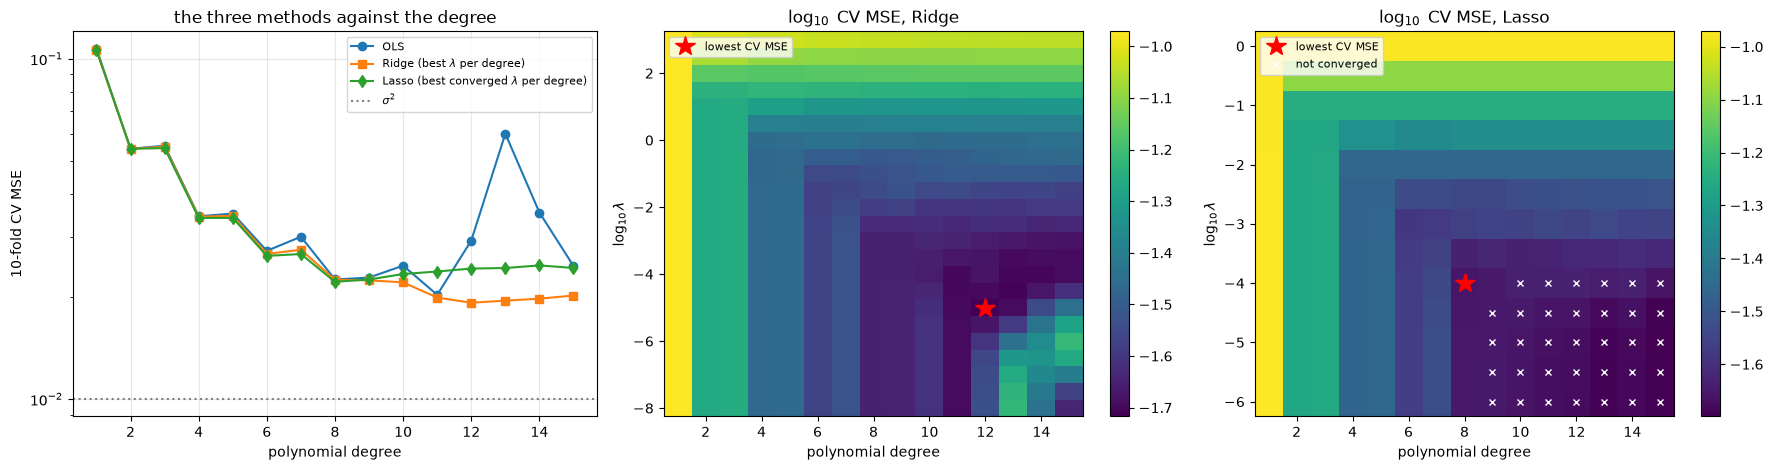

In [679]:
cv_ridge_K = cv_ridge[K]                                  # from d.3, same folds
cv_lasso_ok = np.where(conv_lasso, cv_lasso, np.nan)      # only converged cells count for the selection

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
ax = axes[0]
ax.plot(degrees, cv_ols[K], "o-", label="OLS")
ax.plot(degrees, cv_ridge_K.min(axis=0), "s-", label=r"Ridge (best $\lambda$ per degree)")
ax.plot(degrees, np.nanmin(cv_lasso_ok, axis=0), "d-", label=r"Lasso (best converged $\lambda$ per degree)")
ax.axhline(0.1**2, color="gray", ls=":", label=r"$\sigma^2$")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel(f"{K}-fold CV MSE")
ax.set_title("the three methods against the degree")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

for ax, grid, lams, name in [(axes[1], cv_ridge_K, lambdas_cv, "Ridge"), (axes[2], cv_lasso, lambdas_lasso, "Lasso")]:
    step = np.log10(lams[1]) - np.log10(lams[0])          # grid spacing in log10(lambda)
    im = ax.imshow(np.log10(grid), origin="lower", aspect="auto", cmap="viridis",
                   extent=[degrees[0] - 0.5, degrees[-1] + 0.5,
                           np.log10(lams[0]) - step / 2, np.log10(lams[-1]) + step / 2])
    sel = grid if name == "Ridge" else cv_lasso_ok
    i_b, j_b = np.unravel_index(np.nanargmin(sel), sel.shape)
    ax.plot(degrees[j_b], np.log10(lams[i_b]), "r*", ms=15, label="lowest CV MSE")
    if name == "Lasso":                                   # mark the unconverged cells
        ii, jj = np.where(~conv_lasso)
        ax.plot(degrees[jj], np.log10(lams[ii]), "wx", ms=5, label="not converged")
    ax.set_xlabel("polynomial degree")
    ax.set_ylabel(r"$\log_{10}\lambda$")
    ax.set_title(rf"$\log_{{10}}$ CV MSE, {name}")
    ax.legend(loc="upper left", fontsize=8)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

#### i.3 The best model of each method
**Source:** the lowest cross-validated error of each method, from i.1 and d.2–d.3. The standard error of a CV
estimate is the standard deviation of the fold errors divided by $\sqrt k$ (lecture notes Section 3.14, the
one-standard-error rule, Eq. (3.96)); it tells whether differences between the methods are meaningful.
> **LLM note:** Written with Claude (Level 4). New code.

In [680]:
def cv_mse_se(pipe, x, y, k):
    """Mean and standard error (std / sqrt(k)) of the k fold MSEs, with the folds of cv_mse (d.1)."""
    kfold = KFold(n_splits=k, shuffle=True, random_state=SEED)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        fold_mse = -cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold, scoring="neg_mean_squared_error")
    return fold_mse.mean(), fold_mse.std(ddof=1) / np.sqrt(k)


j_o = np.argmin(cv_ols[K])
i_r, j_r = np.unravel_index(np.argmin(cv_ridge_K), cv_ridge_K.shape)
i_l, j_l = np.unravel_index(np.nanargmin(cv_lasso_ok), cv_lasso_ok.shape)
best = {"OLS":   (degrees[j_o], None,               make_ols_pipeline(degrees[j_o])),
        "Ridge": (degrees[j_r], lambdas_cv[i_r],    make_ridge_pipeline(degrees[j_r], lambdas_cv[i_r])),
        "Lasso": (degrees[j_l], lambdas_lasso[i_l], make_lasso_pipeline(degrees[j_l], lambdas_lasso[i_l]))}

print(f"best model of each method, {K}-fold CV on the whole data set (n = 100, sigma = 0.1):")
print("method   degree   lambda       CV MSE     standard error")
for name, (d, lam, pipe) in best.items():
    m, se = cv_mse_se(pipe, x, y, K)
    lam_str = "   -    " if lam is None else f"{lam:8.1e}"
    print(f"{name:6s}   {d:6d}   {lam_str}   {m:.4f}     {se:.4f}")

best model of each method, 10-fold CV on the whole data set (n = 100, sigma = 0.1):
method   degree   lambda       CV MSE     standard error
OLS          11      -       0.0202     0.0031
Ridge        12    1.0e-05   0.0192     0.0026
Lasso         8    1.0e-04   0.0221     0.0021


#### i.4 Which term of the bias-variance decomposition does each method attack?
**Source:** the bootstrap of part c) (`week36tuesday.ipynb` Case 1): same data set, same 80/20 split, $B = 100$
resamples of the training set drawn with `rng.integers` (Section 2.11); error, bias$^2$ (measured with the test data,
so it contains $\sigma^2$) and variance as in c.3. **Modifications:** the models are the pipelines of d.1 and i.1,
refitted on every bootstrap sample, so OLS, Ridge and Lasso can be compared at the same degree. Two degrees: 5 (low)
and 12 (the degree selected for Ridge); for Ridge and Lasso the $\lambda$ with the lowest CV MSE at that degree
(Lasso: among converged cells).
> **LLM note:** Written with Claude (Level 4), adapted from our bootstrap of part c).

In [681]:
def bootstrap_pipeline(make_model, x_train, y_train, x_test, y_test, boot_idx):
    """
    Bootstrap error, bias^2 (measured with y_test) and variance, as in c.3, for any Scikit-Learn pipeline.

    LLM-assisted
    ------------
    Tool: Claude (Claude Opus 5.5, claude.ai, September 2026)
    Role: Adapted bootstrap_bias_variance (c.3, from week36tuesday.ipynb Case 1) to pipelines.
    """
    y_pred = np.empty((len(x_test), len(boot_idx)))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        for b, idx in enumerate(boot_idx):
            model = make_model().fit(x_train[idx][:, None], y_train[idx])   # refit on bootstrap sample b
            y_pred[:, b] = model.predict(x_test[:, None])
    y_col = y_test[:, None]
    error = np.mean((y_col - y_pred) ** 2)
    bias2 = np.mean((y_col - y_pred.mean(axis=1, keepdims=True)) ** 2)
    variance = np.mean(np.var(y_pred, axis=1))
    return error, bias2, variance


x_tr_i, x_te_i, y_tr_i, y_te_i = train_test_split(x, y, test_size=TEST_SIZE, random_state=SEED)   # split of part c)
boot_idx_i = np.random.default_rng(SEED).integers(0, len(x_tr_i), size=(100, len(x_tr_i)))         # B = 100

print("degree   method   lambda       error     bias^2    variance")
for d in [5, 12]:
    j = d - 1
    lam_r = lambdas_cv[np.argmin(cv_ridge_K[:, j])]                 # best Ridge lambda at this degree
    lam_l = lambdas_lasso[np.nanargmin(cv_lasso_ok[:, j])]          # best converged Lasso lambda at this degree
    for name, lam, maker in [("OLS", None, lambda: make_ols_pipeline(d)),
                             ("Ridge", lam_r, lambda: make_ridge_pipeline(d, lam_r)),
                             ("Lasso", lam_l, lambda: make_lasso_pipeline(d, lam_l))]:
        err, b2, var = bootstrap_pipeline(maker, x_tr_i, y_tr_i, x_te_i, y_te_i, boot_idx_i)
        lam_str = "   -    " if lam is None else f"{lam:8.1e}"
        print(f"{d:6d}   {name:6s}   {lam_str}   {err:8.4f}   {b2:8.4f}   {var:8.4f}")
    print()

degree   method   lambda       error     bias^2    variance
     5   OLS         -         0.0406     0.0362     0.0044
     5   Ridge     3.2e-01     0.0396     0.0371     0.0026
     5   Lasso     3.2e-03     0.0387     0.0361     0.0026

    12   OLS         -         0.7897     0.0612     0.7285
    12   Ridge     1.0e-05     0.1556     0.0400     0.1156
    12   Lasso     3.2e-04     0.0412     0.0262     0.0150



#### i.5 Observations (notes for the report)
> **LLM note:** Drafted with Claude from the outputs above and our follow-up questions (text Level 3 if used
> as it is). Rewrite in your own words for the report, and check every number against your own run.
> **[own]** marks reasoning that is not taken from the course material; **[own check, not in the notebook]**
> marks numbers from additional checks that the notebook does not print.

1. **How the models are fitted and selected.** For a given degree and $\lambda$, each fold's pipeline standardises the
   columns with the training-fold statistics and fits the coefficients on the training folds: OLS and Ridge exactly,
   with Scikit-Learn's direct least-squares solvers (Eq. (3.44) for Ridge), the Lasso iteratively by coordinate descent
   with soft thresholding (Section 3.9, Eq. (3.69)), because it has no closed form (Eq. (3.57)). The degree and $\lambda$
   are chosen by a grid search: every combination is fitted once per fold, its CV error is the average over the 10
   held-out folds, and the combination with the lowest CV error is selected (Lasso: converged cells only). The
   standard error of a CV estimate (i.3) is the standard deviation of the 10 fold errors divided by $\sqrt{10}$; it
   measures how much the CV error itself would change with another fold assignment (Section 3.14, Eq. (3.96)).

2. **The best model of each method (i.3; 10-fold CV, $n = 100$, $\sigma = 0.1$).**

   | method | degree | $\lambda$ | CV MSE | standard error |
   |---|---|---|---|---|
   | OLS | 11 | – | 0.0202 | 0.0031 |
   | Ridge | 12 | $10^{-5}$ | **0.0192** | 0.0026 |
   | Lasso (converged fits) | 8 | $10^{-4}$ | 0.0221 | 0.0021 |

   Ridge at degree 12 with $\lambda = 10^{-5}$ has the lowest cross-validated error, but the three differ by less
   than about one standard error of the CV estimate, so the data do not single out one method (Section 3.14).
   All three stay about twice the noise floor $\sigma^2 = 0.01$: what remains is mostly the part of Runge's function
   a polynomial of this degree cannot represent, which none of the three methods can remove [own reading].

3. **Against the degree (i.2).** Up to degree 8–9 the three curves lie on top of each other: at low degree
   there is little variance, and a penalty has nothing to remove. Beyond that the OLS error rises irregularly (0.060
   at degree 13), while Ridge and Lasso stay flat: the penalty removes the variance that makes high-degree OLS
   unstable. Ridge is lowest at high degree (about 0.019–0.020); the Lasso stays slightly higher (about
   0.023–0.025), presumably because from degree 9 on its small-$\lambda$ cells did not converge and were excluded,
   so it can only use larger $\lambda$ there [own reading]. The Ridge grid (middle) shows the same diagonal valley as
   in parts b) and d): a higher degree needs a larger $\lambda$. In the Lasso grid (right) the top row ($\lambda = 1$)
   has the same error at every degree, because the penalty sets every coefficient to zero and the model predicts
   only the mean (Section 3.9) [own reading]; below it the same diagonal valley appears, cut off at high degree and
   small $\lambda$ by the unconverged cells. The $\lambda$ scales of Ridge and Lasso are different penalties in
   different conventions and cannot be compared.

4. **The Lasso solver (i.1, i.2 right).** In 34 of the 195 cells, all at degree 9–15 and small $\lambda$,
   Scikit-Learn's coordinate descent did not converge within $10^5$ iterations; allowing $10^6$ did not fix it. The
   nearly collinear high powers make the Lasso hard to solve there, as they made gradient descent slow in part e).
   An unfinished fit is not the Lasso solution: stopping early acts as an extra, hidden regularisation, so the CV
   error of such a cell does not measure the Lasso at that degree and $\lambda$. **[own check, not in the notebook]** At
   degree 15 and $\lambda = 3\cdot10^{-6}$ the CV error changed from 0.0200 to 0.0222 when ten times more iterations were
   allowed, still without convergence. The unconverged cells contain the lowest CV error of the whole Lasso grid
   (0.0200 at degree 15), so without the convergence check an unfinished fit would have been selected; this is why
   the check is printed and the cells are marked and excluded. The non-convergence itself is a limitation: the best
   converged Lasso (degree 8) may understate what the Lasso can do at high degree, and its optimum there remains
   uncertain. It does not change the conclusion of point 2, since even the unconverged cells (about 0.020) are no
   better than Ridge (0.019) or OLS (0.020), all within about one standard error.

5. **Which term does each method attack? (i.4, bootstrap, same split and resamples as part c).**

   | degree | method | $\lambda$ | error | bias$^2$ | variance |
   |---|---|---|---|---|---|
   | 5 | OLS | – | 0.041 | 0.036 | 0.0044 |
   | 5 | Ridge | 0.32 | 0.040 | 0.037 | 0.0026 |
   | 5 | Lasso | $3.2\cdot10^{-3}$ | 0.039 | 0.036 | 0.0026 |
   | 12 | OLS | – | 0.790 | 0.061 | 0.7285 |
   | 12 | Ridge | $10^{-5}$ | 0.156 | 0.040 | 0.1156 |
   | 12 | Lasso | $3.2\cdot10^{-4}$ | 0.041 | 0.026 | 0.0150 |

   *OLS* has no penalty: it lowers the bias by raising the degree and pays with variance (part c). *Ridge and Lasso*
   attack the **variance** term, at the price of some bias: Ridge by shrinking the weakly determined singular modes
   (Section 3.8, Eqs. (3.48), (3.50)–(3.52)), the Lasso by shrinking and removing coefficients (Section 3.9). The
   numbers support this reading. At degree 12, where OLS is dominated by variance, Ridge cuts the variance by a
   factor of 6 and the Lasso by a factor of 50, and the error falls from 0.79 to 0.16 and 0.04. At degree 5, where
   the variance is already small, the penalties lower it only from 0.004 to 0.003, the measured bias$^2$ stays the
   same or rises slightly (0.036 to 0.037 for Ridge), and the error hardly changes. At degree 12 the bias$^2$ of OLS
   is itself inflated, because a few exploding bootstrap fits pull the average prediction away (part c), so the
   bias comparison is not clean there, but the variance reduction is unambiguous.

6. **Strengths and weaknesses for this problem [own summary, based on parts a–i].**
   - *OLS:* exact closed form, one hyperparameter (the degree), cheapest. But at high degree it is unstable
     (ill-conditioning and variance, parts a and c), so the degree must be chosen carefully.
   - *Ridge:* closed form through the SVD for every $\lambda$ (Eq. (3.46)), stable at any degree because it switches off
     the weakest singular modes (part b), and the lowest CV error here. But it has two hyperparameters, shrinks every
     coefficient and sets none to zero, so it does not tell which powers matter.
   - *Lasso:* selects powers (at degree 5 it drops $x$ and $x^5$, part g), and it reduces the variance strongly. But
     it has no closed form, both our gradient descent (part g, no exact zeros) and Scikit-Learn's coordinate descent
     (i.1, no convergence at high degree) struggle with the collinear polynomial columns, so its optimum at high
     degree remains uncertain, and with nearly identical columns the choice of which power to keep is unstable
     (Section 3.9).

7. **Caveat.** One data set of 100 points; CV errors with standard errors of 0.002–0.003; discrete $\lambda$ grids;
   Lasso cells without convergence excluded; the bootstrap has the limitations discussed in parts c) and d).

## Background literature

- The lecture notes of the course, in particular Chapter 2 (Sections 2.9–2.12
  on training and test error, the bias-variance tradeoff, the bootstrap and
  cross-validation), Chapter 3 (linear regression, Ridge, Lasso, scaling) and
  Chapter 4 (gradient descent methods and automatic differentiation).
- For a discussion and derivation of the variances and mean squared errors
  using linear regression, see the
  [Lecture notes on ridge regression by Wessel N. van Wieringen](https://arxiv.org/abs/1509.09169).
- The textbook of
  [Trevor Hastie, Robert Tibshirani, Jerome H. Friedman, The Elements of Statistical Learning, Springer](https://www.springer.com/gp/book/9780387848570);
  chapters 3 and 7 are the most relevant ones for the analysis here.
- On automatic differentiation:
  [Baydin et al., Automatic differentiation in machine learning: a survey, JMLR 18 (2018)](https://jmlr.org/papers/v18/17-468.html),
  and the [JAX documentation](https://jax.readthedocs.io).

## Introduction to numerical projects

Here follows a brief recipe and recommendation on how to answer the various
questions when preparing your answers.

- Give a short description of the nature of the problem and the eventual
  numerical methods you have used.
- Describe the algorithm you have used and/or developed. Here you may find it
  convenient to use pseudocoding. In many cases you can describe the algorithm
  in the program itself.
- Include the source code of your program. Comment your program properly. You
  should have the code at your GitHub/GitLab link. You can also place the code
  in an appendix of your report.
- If possible, try to find analytic solutions, or known limits in order to test
  your program when developing the code. In this project the closed-form OLS
  and Ridge solutions are exactly such tests for your gradient descent codes.
- Include your results either in figure form or in a table. Remember to label
  your results. All tables and figures should have relevant captions and labels
  on the axes.
- Try to evaluate the reliability and numerical stability/precision of your
  results. If possible, include a qualitative and/or quantitative discussion of
  the numerical stability, eventual loss of precision etc.
- Try to give an interpretation of your results in your answers to the
  problems.
- Critique: if possible include your comments and reflections about the
  exercise, whether you felt you learnt something, ideas for improvements and
  other thoughts you've made when solving the exercise. We wish to keep this
  course at the interactive level and your comments can help us improve it.
- Try to establish a practice where you log your work at the computer lab. You
  may find such a logbook very handy at later stages in your work, especially
  when you don't properly remember what a previous test version of your program
  did. Here you could also record the time spent on solving the exercise,
  various algorithms you may have tested or other topics which you feel worthy
  of mentioning.

## Format for electronic delivery of report and programs

The preferred format for the report is a PDF file. You can also use DOC or
postscript formats or an IPython notebook file. As programming language we
prefer that you choose between C/C++, Fortran2008, Julia or Python. The
following prescription should be followed when preparing the report:

- Use Canvas to hand in your projects, log in at
  <https://www.uio.no/english/services/it/education/canvas/> with your normal
  UiO username and password.
- Upload **only** the report file or the link to your GitHub/GitLab or similar
  type of repository! For the source code file(s) you have developed please
  provide us with your link to your GitHub/GitLab or similar domain. The report
  file should include all of your discussions and a list of the codes you have
  developed. Do not include library files which are available at the course
  homepage, unless you have made specific changes to them.
- In your GitHub/GitLab or similar repository, please include a folder which
  contains selected results. These can be in the form of output from your code
  for a selected set of runs and input parameters.

Finally, we encourage you to collaborate. Optimal working groups consist of 2–3
students. You can then hand in a common report.

## Software and needed installations

If you have Python installed (we recommend Python 3) and you feel pretty
familiar with installing different packages, we recommend that you install the
following Python packages via `pip` as

    pip install numpy scipy matplotlib ipython jupyter scikit-learn pandas jax jaxlib

(`autograd` is a lighter alternative to JAX for the automatic differentiation in
parts e)–g)). For Python 3, replace `pip` with `pip3` where needed.

For OSX users we recommend also, after having installed Xcode, to install
`brew`. Brew allows for a seamless installation of additional software via for
example `brew install python3`. For Linux users, with its variety of
distributions like for example the widely popular Ubuntu distribution, you can
use `pip` as well and simply install Python as `sudo apt-get install python3`
etc.

If you don't want to install various Python packages with their dependencies
separately, we recommend [Anaconda](https://docs.anaconda.com/), an open source
distribution of the Python and R programming languages for large-scale data
processing, predictive analytics, and scientific computing, that aims to
simplify package management and deployment. Package versions are managed by the
package management system `conda`.

Popular software packages written in Python for ML are
[Scikit-learn](http://scikit-learn.org/stable/), [JAX](https://jax.readthedocs.io),
[TensorFlow](https://www.tensorflow.org/), [PyTorch](http://pytorch.org/) and
[Keras](https://keras.io/). These are all freely available at their respective
GitHub sites. They encompass communities of developers in the thousands or more,
and the number of code developers and contributors keeps increasing.